In [1270]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
from scipy.linalg import solve_triangular, qr
import json
import re
import os
import uproot
import importlib.util
plt.style.use(hep.style.CMS)

In [1271]:
label_map = {
    "pth_bin0": "r_PTH_0p0_5p0",
    "pth_bin1": "r_PTH_5p0_10p0",
    "pth_bin2": "r_PTH_10p0_15p0",
    "pth_bin3": "r_PTH_15p0_20p0",
    "pth_bin4": "r_PTH_20p0_25p0",
    "pth_bin5": "r_PTH_25p0_30p0",
    "pth_bin6": "r_PTH_30p0_35p0",
    "pth_bin7": "r_PTH_35p0_45p0",
    "pth_bin8": "r_PTH_45p0_60p0",
    "pth_bin9": "r_PTH_60p0_80p0",
    "pth_bin10": "r_PTH_80p0_100p0",
    "pth_bin11": "r_PTH_100p0_120p0",
    "pth_bin12": "r_PTH_120p0_140p0",
    "pth_bin13": "r_PTH_140p0_170p0",
    "pth_bin14": "r_PTH_170p0_200p0",
    "pth_bin15": "r_PTH_200p0_250p0",
    "pth_bin16": "r_PTH_250p0_350p0",
    "pth_bin17": "r_PTH_350p0_450p0",
    "pth_bin18": "r_PTH_450p0_10000p0",
    # "nj_bin0": "r_NJ_0p0_1p0",
    # "nj_bin1": "r_NJ_1p0_2p0",
    # "nj_bin2": "r_NJ_2p0_3p0",
    # "nj_bin3": "r_NJ_3p0_4p0",
    # "nj_bin4": "r_NJ_4p0_100p0",
    # "ptj0_bin0": "r_PTJ0_m10000p0_30p0",
    # "ptj0_bin1": "r_PTJ0_30p0_40p0",
    # "ptj0_bin2": "r_PTJ0_40p0_55p0",
    # "ptj0_bin3": "r_PTJ0_55p0_75p0",
    # "ptj0_bin4": "r_PTJ0_75p0_95p0",
    # "ptj0_bin5": "r_PTJ0_95p0_120p0",
    # "ptj0_bin6": "r_PTJ0_120p0_150p0",
    # "ptj0_bin7": "r_PTJ0_150p0_200p0",
    # "ptj0_bin8": "r_PTJ0_200p0_10000p0",
    # "dphij0j1_bin0": "r_DPhiJ0J1_m3p1416_3p1416_underflow",
    # "dphij0j1_bin1": "r_DPhiJ0J1_m3p1416_m1p5708",
    # "dphij0j1_bin2": "r_DPhiJ0J1_m1p5708_0p0",
    # "dphij0j1_bin3": "r_DPhiJ0J1_0p0_1p5708",
    # "dphij0j1_bin4": "r_DPhiJ0J1_1p5708_3p1416",
}


label_map_theory = {
    "PTH_bin0": "r_PTH_0p0_5p0",
    "PTH_bin1": "r_PTH_5p0_10p0",
    "PTH_bin2": "r_PTH_10p0_15p0",
    "PTH_bin3": "r_PTH_15p0_20p0",
    "PTH_bin4": "r_PTH_20p0_25p0",
    "PTH_bin5": "r_PTH_25p0_30p0",
    "PTH_bin6": "r_PTH_30p0_35p0",
    "PTH_bin7": "r_PTH_35p0_45p0",
    "PTH_bin8": "r_PTH_45p0_60p0",
    "PTH_bin9": "r_PTH_60p0_80p0",
    "PTH_bin10": "r_PTH_80p0_100p0",
    "PTH_bin11": "r_PTH_100p0_120p0",
    "PTH_bin12": "r_PTH_120p0_140p0",
    "PTH_bin13": "r_PTH_140p0_170p0",
    "PTH_bin14": "r_PTH_170p0_200p0",
    "PTH_bin15": "r_PTH_200p0_250p0",
    "PTH_bin16": "r_PTH_250p0_350p0",
    "PTH_bin17": "r_PTH_350p0_450p0",
    "PTH_bin18": "r_PTH_450p0_10000p0",
    # "NJ_bin0": "r_NJ_0p0_1p0",
    # "NJ_bin1": "r_NJ_1p0_2p0",
    # "NJ_bin2": "r_NJ_2p0_3p0",
    # "NJ_bin3": "r_NJ_3p0_4p0",
    # "NJ_bin4": "r_NJ_4p0_100p0",
    # "PTJ0_bin0": "r_PTJ0_m10000p0_30p0",
    # "PTJ0_bin1": "r_PTJ0_30p0_40p0",
    # "PTJ0_bin2": "r_PTJ0_40p0_55p0",
    # "PTJ0_bin3": "r_PTJ0_55p0_75p0",
    # "PTJ0_bin4": "r_PTJ0_75p0_95p0",
    # "PTJ0_bin5": "r_PTJ0_95p0_120p0",
    # "PTJ0_bin6": "r_PTJ0_120p0_150p0",
    # "PTJ0_bin7": "r_PTJ0_150p0_200p0",
    # "PTJ0_bin8": "r_PTJ0_200p0_10000p0",
    # "DPhiJ0J1_bin0": "r_DPhiJ0J1_m3p1416_3p1416_underflow",
    # "DPhiJ0J1_bin1": "r_DPhiJ0J1_m3p1416_m1p5708",
    # "DPhiJ0J1_bin2": "r_DPhiJ0J1_m1p5708_0p0",
    # "DPhiJ0J1_bin3": "r_DPhiJ0J1_0p0_1p5708",
    # "DPhiJ0J1_bin4": "r_DPhiJ0J1_1p5708_3p1416",
}

In [1272]:

def read_bootstrap_file(path: Union[str, Path], prefix: str) -> pd.DataFrame:
    """
    Read one bootstrap text file.
    - Drops the first 4 header lines.
    - Drops first data column (replica index).
    - Returns only bin columns, prefixed to keep names unique across files.
    """
    path = Path(path)

    # Header in these files starts with '#'; this also skips the first 4 lines
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None)

    # Drop first row (text labels) and first column (replica/bin label)
    df = df.iloc[:, 1:].copy()
    df.columns = [f"{prefix}_bin{i}" for i in range(df.shape[1])]

    return df


def build_df(
    pth_path: Union[str, Path],
    # nj_path: Union[str, Path],
    # ptj0_path: Union[str, Path],
    # dphij0j1_path: Union[str, Path],
) -> pd.DataFrame:
    """Read all three files and return one dataframe per variable"""
    pth = read_bootstrap_file(pth_path, "pth")
    # nj = read_bootstrap_file(nj_path, "nj")
    # ptj0 = read_bootstrap_file(ptj0_path, "ptj0")
    # dphij0j1 = read_bootstrap_file(dphij0j1_path, "dphij0j1")

    # Check if all variables have the same number of replicas
    # if not (len(pth) == len(nj) == len(ptj0) == len(dphij0j1)):
    # # if not (len(pth) == len(nj)):
    # # if not (len(pth) == len(nj) == len(ptj0)):
    #     raise ValueError("Replica counts do not match across files.")

    # return pd.concat([pth, nj, ptj0, dphij0j1], axis=1)
    # return pd.concat([pth, nj, ptj0], axis=1)
    # return pd.concat([pth, nj], axis=1)
    return pd.concat([pth], axis=1)

## Helper function to invert a matrix and compute correlations from covariances
def invert_matrix(matrix: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        np.linalg.pinv(matrix.to_numpy()),
        index=matrix.index,
        columns=matrix.columns,
    )

## Helper function to compute correlations from covariances
def compute_corr(cov: pd.DataFrame) -> pd.DataFrame:
    sigma = np.sqrt(np.diag(cov.to_numpy()))
    denom = np.outer(sigma, sigma)
    corr = np.divide(
        cov.to_numpy(),
        denom,
        out=np.zeros_like(cov.to_numpy()), 
        where=denom != 0,
    )
    return pd.DataFrame(corr, index=cov.index, columns=cov.columns)

# Plot correlation matrix at gen-level
def plot_corr(_corr_gen, title="Correlation Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": "Correlation"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()
    n_bins = corr_gen.shape[0]
    for b in (b1, b2, b3):
        # Draw only on the visible lower triangle
        ax_corr_gen.plot([0, b], [b, b], color="black", lw=1)
        ax_corr_gen.plot([b, b], [b, n_bins], color="black", lw=1)
    ax_corr_gen.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

# Plot covariance matrix at gen-level
def plot_cov(_corr_gen, title="Covariance Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin = _corr_gen.to_numpy().min(),
        vmax = _corr_gen.to_numpy().max(),
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": r"Covariance [fb$^{2}$]"},
        # cbar_kws={"label": "Theoretical Covariance"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

In [1273]:
VARIABLE_PREFIXES = ("pth_", "nj_", "ptj0_", "DPhiJ0J1_")
# VARIABLE_PREFIXES = ("pth_", "nj_", "ptj0_")
# VARIABLE_PREFIXES = ("pth_", "nj_")

CAT = ["cat0", "cat1", "cat2"]

YEARS = ["2022", "2023", "2024"]
# YEARS = ["2022", "2023"]


def zero_intra_variable_off_diagonal_block(matrix: pd.DataFrame) -> pd.DataFrame:
    out = matrix.copy()
    cols = list(out.columns)
    for pref in VARIABLE_PREFIXES:
        group = [c for c in cols if c.startswith(pref)]
        for ci in group:
            for cj in group:
                if ci != cj:
                    out.loc[ci, cj] = 0.0
    return out

def zero_below_threshold_keep_diag(matrix: pd.DataFrame, threshold: float, use_abs: bool = True) -> pd.DataFrame:
    out = matrix.copy()
    vals = out.abs() if use_abs else out
    mask = vals < threshold
    np.fill_diagonal(mask.values, False)
    out[mask] = 0.0
    return out

def corr_from_cov(cov_mat: pd.DataFrame) -> pd.DataFrame:
    v = np.diag(cov_mat.to_numpy())
    sigma = np.sqrt(np.clip(v, 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        outer = np.outer(1.0 / sigma, 1.0 / sigma)
        arr = outer * cov_mat.to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(arr, 1.0)
    return pd.DataFrame(arr, index=cov_mat.index, columns=cov_mat.columns)

####################################################################################################

cov = {}
corr = {}
df_dict = {}

def compute_cov_from_df(df_1, df_2):
    num_vars = df_1.shape[1]
    
    # np.cov treats columns as variables when rowvar=False
    # Returns a combined matrix: [[Cov(1,1), Cov(1,2)], [Cov(2,1), Cov(2,2)]]
    full_cov = np.cov(df_1, df_2, rowvar=False)
    
    # Extract the top-right block which is the cross-covariance matrix
    cross_cov = full_cov[0:num_vars, num_vars:]
    
    # Rebuild back into a clean DataFrame
    c = pd.DataFrame(cross_cov, index=df_1.columns, columns=df_2.columns)
    
    # Your remaining custom logic
    c = zero_intra_variable_off_diagonal_block(c)
    c = 0.5 * (c + c.T)
    return c

for cat in CAT:
    
    # We can combine the sidebands across the YEARS (also done in FinalFits)
    df_combined = pd.DataFrame()
    
    for year in YEARS:
        df = build_df(
            f"bootstrap/bootstrap_sideband_counts_pth_{cat}_{year}.txt",
            # f"bootstrap/bootstrap_sideband_counts_nj_{cat}_{year}.txt",
            # f"bootstrap/bootstrap_sideband_counts_ptj0_{cat}_{year}.txt",
            # f"bootstrap/bootstrap_sideband_counts_DPhiJ0J1_{cat}_{year}.txt",
        )
                
        df_combined = df_combined.add(df, fill_value=0)
    
    df_combined = df_combined.reindex(columns=df.columns)    
    df_dict[cat] = df_combined
    
    c = df_combined.cov()
    ## To force setting all off-diagonal entries within each observable to zero uncomment below
    ## This can be useful when running on few replicas where fluctuations can induce non-zero off-diagonal entries
    c = zero_intra_variable_off_diagonal_block(c)
    ## This can be used to set all elements below a threshold to zero
    # c = zero_below_threshold_keep_diag(c, 200)
    ## Force the symmetry of the covariance matrix
    c = 0.5 * (c + c.T)
    
    # label_to_drop = c.index[12]
    # c = c.drop(index=label_to_drop, columns=label_to_drop)
    cov[cat] = c
    corr[cat] = df_combined.corr()#.drop(index=label_to_drop, columns=label_to_drop)


In [1274]:
hep.style.use("CMS")
palette = sns.diverging_palette(240, 10, n=20, as_cmap=True)


# Boundaries between variable blocks (pth | nj | ptj0); same layout for all categories
_ref = cov[CAT[-1]]  # same bin layout for all categories

b1 = len([c for c in _ref.columns if c.startswith("pth_")])
b2 = b1 + len([c for c in _ref.columns if c.startswith("nj_")])
b3 = b2 + len([c for c in _ref.columns if c.startswith("ptj0_")]) + 1


def _decorate_matrix_ax(ax, n_bins: int) -> None:
    ax.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
    ax.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
    ax.minorticks_off()
    for b in (b1, b2, b3):
        ax.plot([0, b], [b, b], color="black", lw=1)
        ax.plot([b, b], [b, n_bins], color="black", lw=1)
    ax.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))


# # 1) Covariance matrices (one panel per category)
# cov_scale = 1e3
# nc = len(CAT)
# fig_cov, axes_cov = plt.subplots(1, nc, figsize=(10 * nc, 9), constrained_layout=True)
# if nc == 1:
#     axes_cov = np.array([axes_cov])

# for ax, cat in zip(axes_cov.flat, CAT):
#     cov_plot = cov[cat] / cov_scale
#     cov_mask = np.triu(np.ones_like(cov_plot, dtype=bool), k=1)
#     sns.heatmap(
#         cov_plot,
#         ax=ax,
#         cmap=palette,
#         mask=cov_mask,
#         annot=True,
#         fmt=".1f",
#         # square=True,
#         annot_kws={"size": 8, "weight": "bold"},
#         cbar_kws={"label": r"Cov [$\times 10^3$]", 'pad': .005},
#     )
#     ax.set_title(f"Covariance — {cat}")
#     ax.set_xlabel("Bins")
#     ax.set_ylabel("Bins")
#     _decorate_matrix_ax(ax, cov_plot.shape[0])

# plt.savefig(f"cov_matrix_perCategory_reduced.pdf", bbox_inches="tight")
# plt.show()

# # 2) Correlation matrices (one panel per category)
# fig_corr, axes_corr = plt.subplots(1, nc, figsize=(10 * nc, 9), constrained_layout=True)
# if nc == 1:
#     axes_corr = np.array([axes_corr])

# for ax, cat in zip(axes_corr.flat, CAT):
#     # cmat = corr[cat]
#     cmat = corr_from_cov(cov[cat])
#     corr_mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)
#     sns.heatmap(
#         cmat,
#         ax=ax,
#         cmap=palette,
#         mask=corr_mask,
#         vmin=-1,
#         vmax=1,
#         annot=True,
#         fmt=".2f",
#         center=0,
#         square=True,
#         annot_kws={"size": 8, "weight": "bold"},
#         cbar_kws={"label": "Correlation", 'pad': .005},
#     )
#     ax.set_title(f"Correlation — {cat}")
#     ax.set_xlabel("Bins")
#     ax.set_ylabel("Bins")
#     _decorate_matrix_ax(ax, cmat.shape[0])

# plt.savefig(f"cor_matrix_perCategory_reduced.pdf", bbox_inches="tight")
# plt.show()

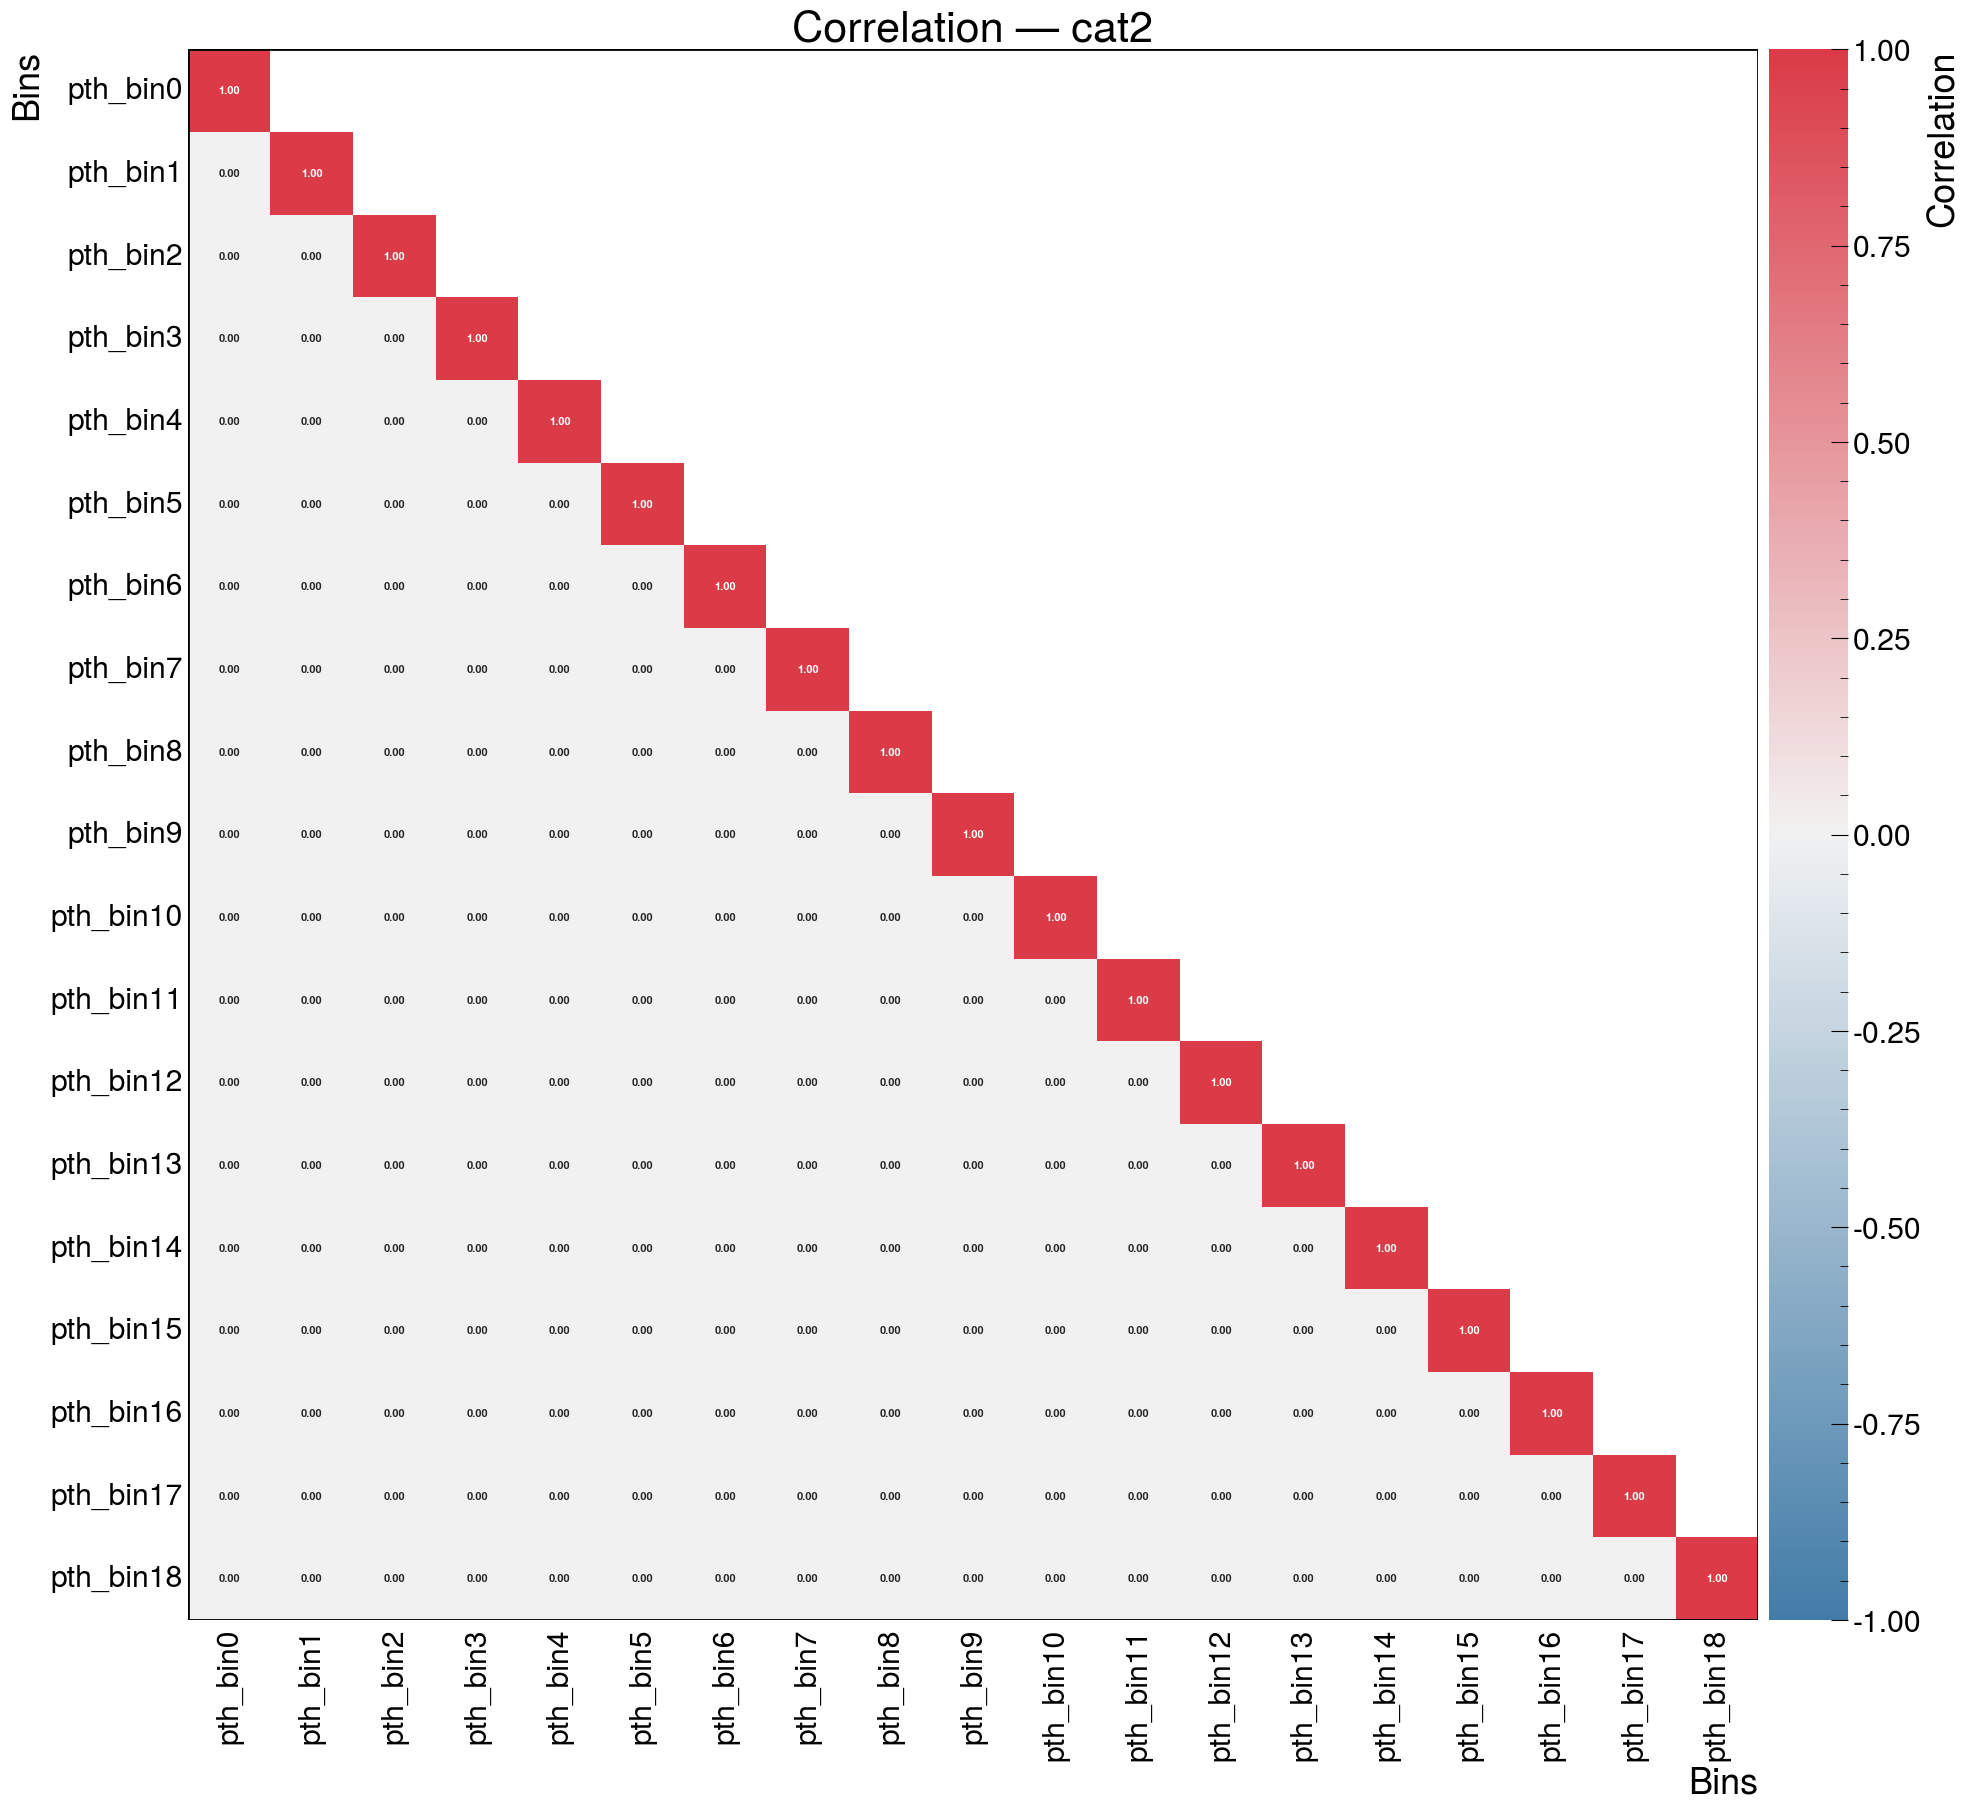

In [1275]:
fig_corr, ax = plt.subplots(
    figsize=(24, 18),
    constrained_layout=True
)

cat = "cat2"

cmat = corr_from_cov(cov[cat])
corr_mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)

sns.heatmap(
    cmat,
    ax=ax,
    cmap=palette,
    mask=corr_mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    annot_kws={"size": 8, "weight": "bold"},
    cbar_kws={"label": "Correlation", "pad": 0.005},
)

ax.set_title(f"Correlation — {cat}")
ax.set_xlabel("Bins")
ax.set_ylabel("Bins")

_decorate_matrix_ax(ax, cmat.shape[0])

plt.show()

In [1278]:
## Loading the response matrix
def read_response_block(path: str):
    """Read response_matrix_*.txt and return numeric square block."""
    raw = pd.read_csv(path, sep=r"\s+", header=None)
    block = raw.iloc[1:, 1:].astype(float).to_numpy()
    # if block.shape[0] != block.shape[1]:
    #     raise ValueError(f"Response block is not square for {path}: {block.shape}")
    return block


def response_paths_for_category(cat: str) -> dict:
    """Lumi-weighted response .txt paths per observable for one reco category."""
    suffix = "combined" # combined
    return {
        "pth": f"response_matrix_{suffix}/response_matrix_PTH_{cat}.txt",
        # "nj": f"response_matrix_{suffix}/response_matrix_NJ_{cat}.txt",
        # "ptj0": f"response_matrix_{suffix}/response_matrix_PTJ0_{cat}.txt",
        # "dphij0j1": f"response_matrix_{suffix}/response_matrix_DPhiJ0J1_{cat}.txt",
    }


def build_block_diagonal_resp(cov_mat: pd.DataFrame, cat: str) -> pd.DataFrame:
    resp_files = response_paths_for_category(cat)
    cols = list(cov_mat.columns)
    prefix_order = []
    for col in cols:
        pref = col.split("_", 1)[0]
        if pref not in prefix_order:
            prefix_order.append(pref)
    
    resp = pd.DataFrame(0.0, index=cov_mat.index, columns=cov_mat.columns)
    start = 0
    for pref in prefix_order:
        block_cols = [c for c in cols if c.startswith(f"{pref}_")]
        n = len(block_cols)
        if pref not in resp_files:
            raise ValueError(f"No response matrix file configured for prefix '{pref}'")

        block = read_response_block(resp_files[pref])

        # for i, row in enumerate(block):
        #     for j, elem in enumerate(row):
        #         if elem < 1e-5:
        #             block[i][j] = 0.0
        
        # if pref == "ptj0":
        #     block = block[1:, 1:] # Drop first row and first column to remove the underflow bin for pTj0
        if block.shape != (n, n):
            raise ValueError(
                f"Shape mismatch for {resp_files[pref]}: got {block.shape}, expected {(n, n)} in year {year}"
            )

        stop = start + n
        resp.iloc[start:stop, start:stop] = block
        start = stop
    return resp

resp = {cat: build_block_diagonal_resp(cov[cat], cat) for cat in CAT}

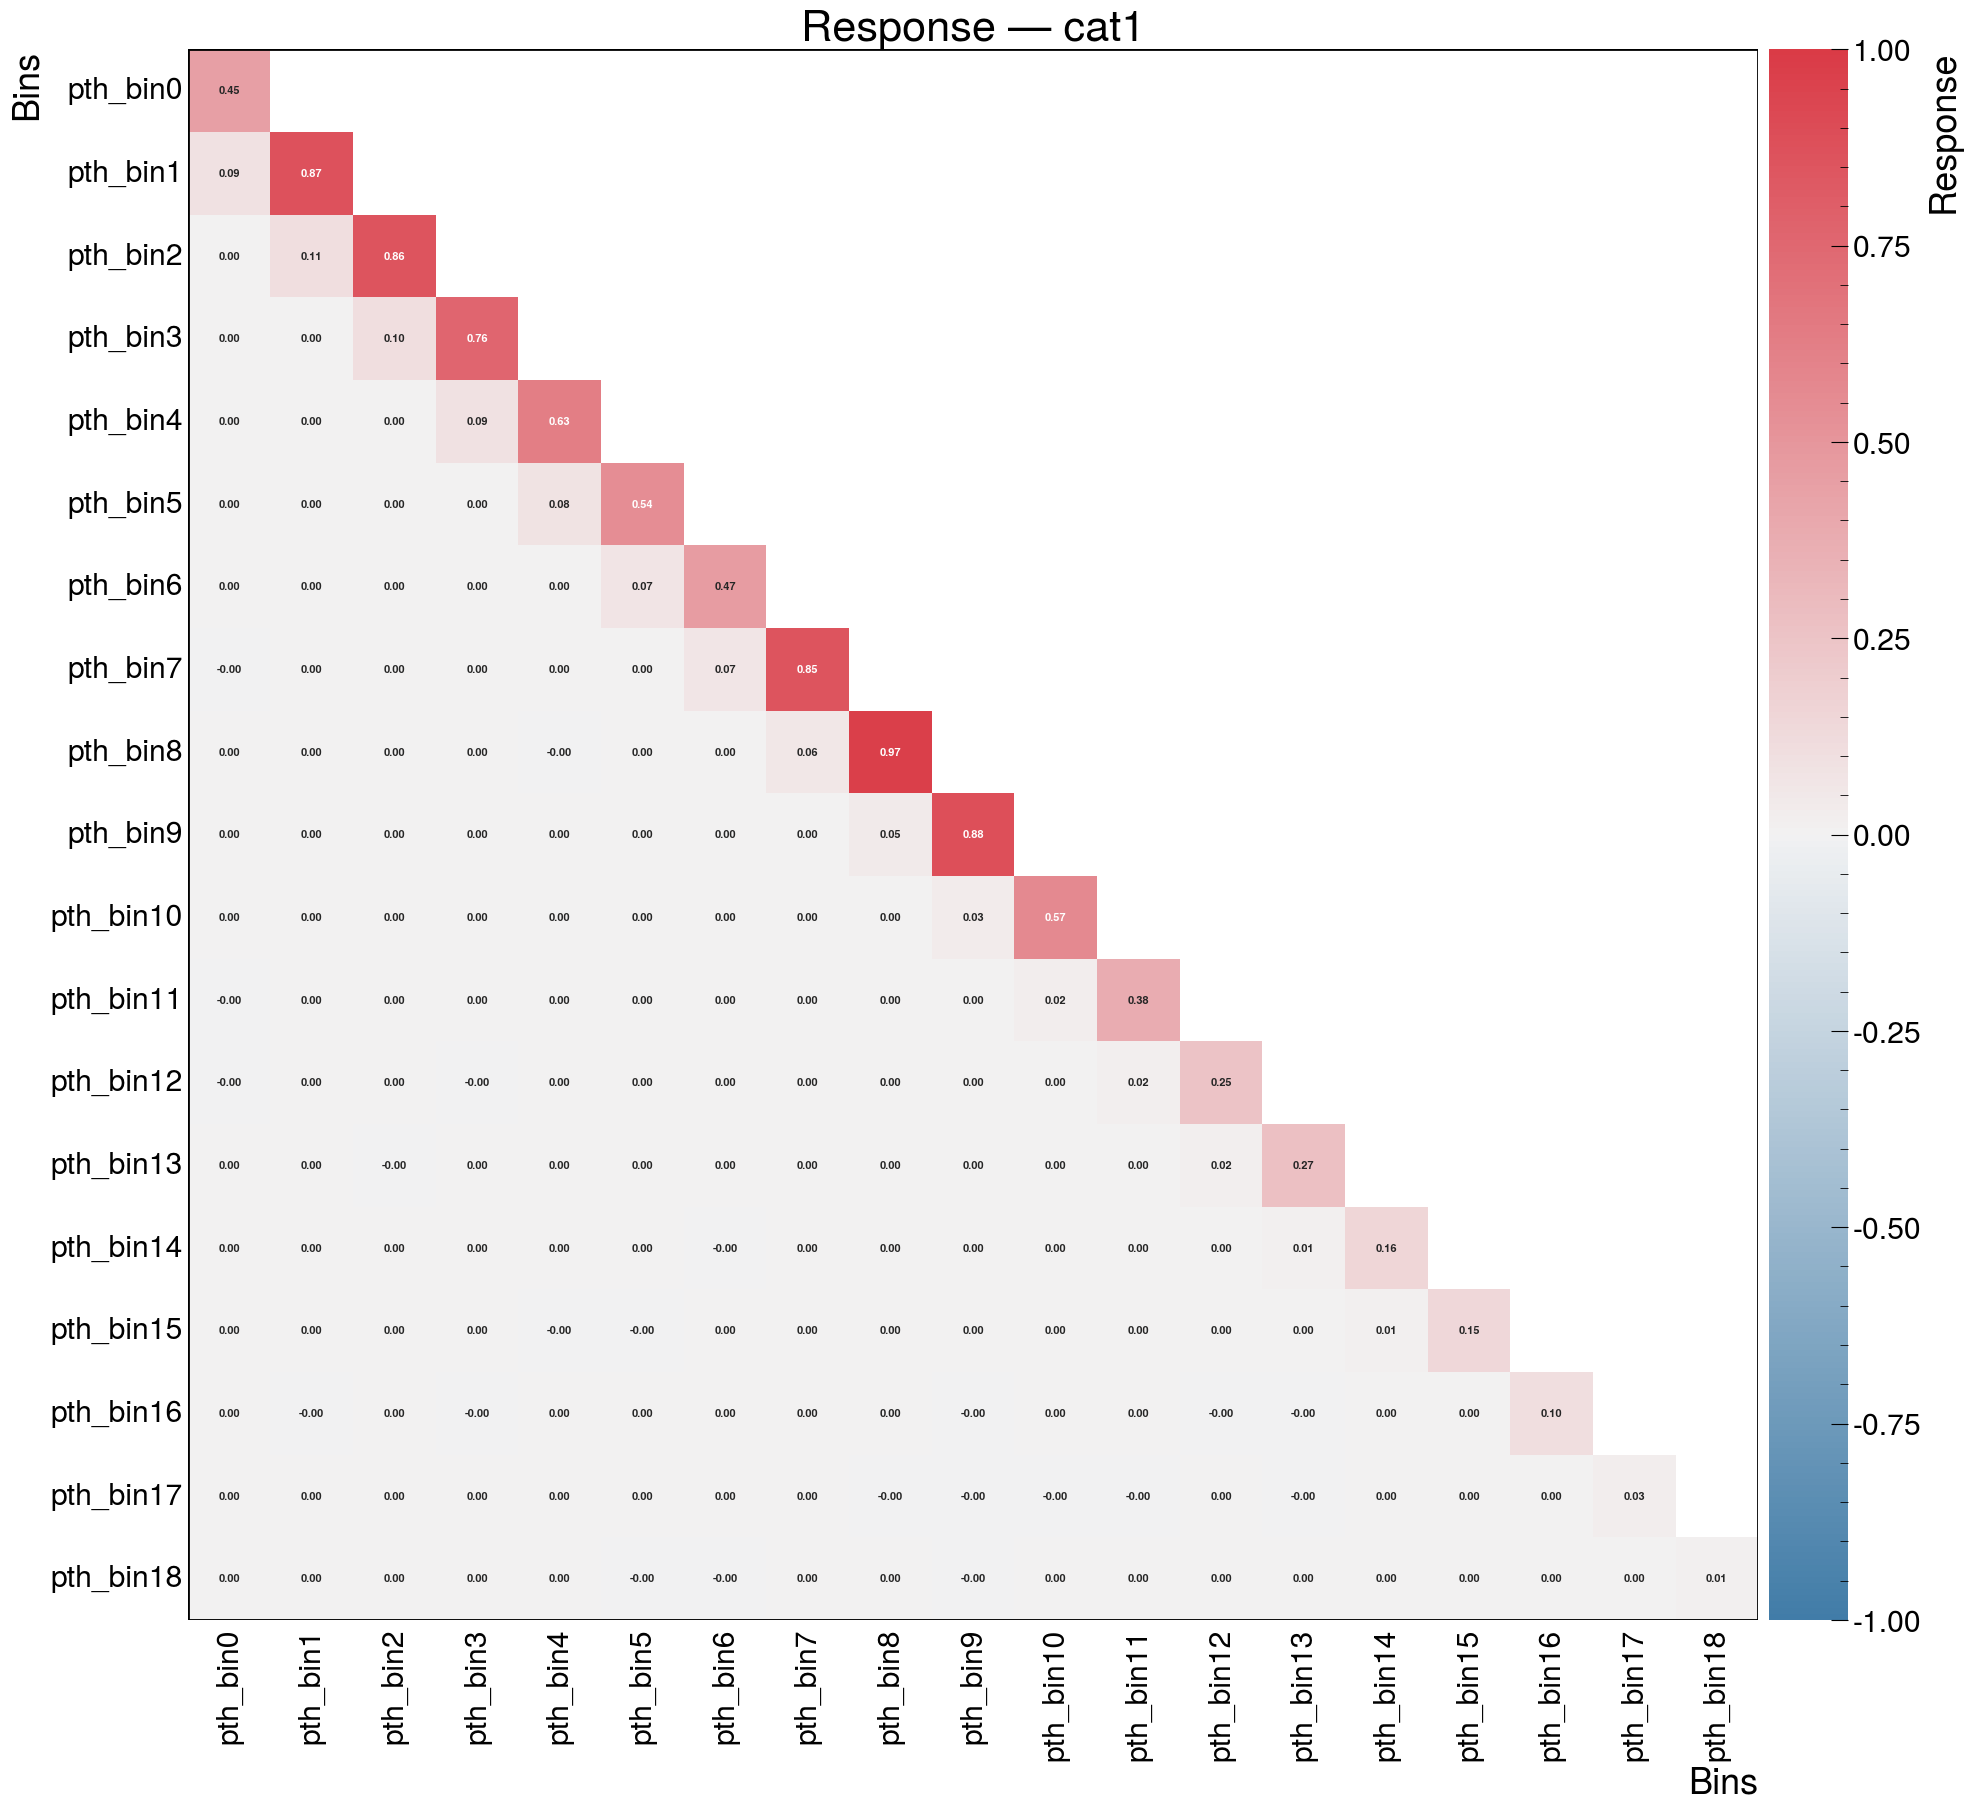

In [1279]:
fig_corr, ax = plt.subplots(
    figsize=(24, 18),
    constrained_layout=True
)

cat = "cat1"

cmat = resp[cat]*100
corr_mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)

sns.heatmap(
    cmat,
    ax=ax,
    cmap=palette,
    mask=corr_mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    annot_kws={"size": 8, "weight": "bold"},
    cbar_kws={"label": "Response", "pad": 0.005},
)

ax.set_title(f"Response — {cat}")
ax.set_xlabel("Bins")
ax.set_ylabel("Bins")

_decorate_matrix_ax(ax, cmat.shape[0])

plt.show()

In [1280]:
fisher_cat = {}

# Build the union of all row/column labels
all_rows = list(resp["cat2"].index)
all_cols = list(resp["cat2"].columns)

for cat in CAT:
    r = resp[cat]
    fisher_cat[cat] = r.T @ invert_matrix(cov[cat]) @ r # Without regularization of the covariance matrix before inversion
    # fisher_cat[cat] = r.T @ invert_matrix(tikhonov_regularize_for_inversion(cov[cat])[0]) @ r # With Tikhonov regularization before inversion
    # fisher_cat[cat] = invert_matrix(cov[cat]) 

## Correlations per category
cov_gen_cat_0 = invert_matrix(fisher_cat["cat0"])
cov_gen_cat_1 = invert_matrix(fisher_cat["cat1"])
cov_gen_cat_2 = invert_matrix(fisher_cat["cat2"])
corr_gen_cat_0 = compute_corr(cov_gen_cat_0)
corr_gen_cat_1 = compute_corr(cov_gen_cat_1)
corr_gen_cat_2 = compute_corr(cov_gen_cat_2)

## Correlations per category using the formula without inversion of the correlation matrix
cov_gen_noinv_cat_0 = invert_matrix(resp['cat0']) @ cov["cat0"] @ invert_matrix(resp['cat0']).T
cov_gen_noinv_cat_1 = invert_matrix(resp['cat1']) @ cov["cat1"] @ invert_matrix(resp['cat1']).T
cov_gen_noinv_cat_2 = invert_matrix(resp['cat2']) @ cov["cat2"] @ invert_matrix(resp['cat2']).T
corr_gen_noinv_cat_0 = compute_corr(cov_gen_noinv_cat_0)
corr_gen_noinv_cat_1 = compute_corr(cov_gen_noinv_cat_1)
corr_gen_noinv_cat_2 = compute_corr(cov_gen_noinv_cat_2)

result = fisher_cat['cat2'].add(fisher_cat['cat1'], fill_value=0).add(fisher_cat['cat0'], fill_value=0)

# print(result)

## Correlations summing the three categories
cov_gen = invert_matrix(result)
# cov_gen = invert_matrix(tikhonov_regularize_for_inversion(fisher_cat["cat0"] + fisher_cat["cat1"] + fisher_cat["cat2"]))
cov_gen = pd.DataFrame(
    cov_gen,
    index=all_rows,
    columns=all_cols,
)

corr_gen = compute_corr(cov_gen)

####################################################################################################
# Checking the condition number of the various matrices
print("Covariance cat0: ", np.linalg.cond(cov["cat0"]), np.linalg.det(cov["cat0"]))
print("Covariance cat1: ", np.linalg.cond(cov["cat1"]), np.linalg.det(cov["cat1"]))
print("Covariance cat2: ", np.linalg.cond(cov["cat2"]), np.linalg.det(cov["cat2"]))
print("Response cat0: ", np.linalg.cond(resp["cat0"]), np.linalg.det(resp["cat0"]))
print("Response cat1: ", np.linalg.cond(resp["cat1"]), np.linalg.det(resp["cat1"]))
print("Response cat2: ", np.linalg.cond(resp["cat2"]), np.linalg.det(resp["cat2"]))
print("Sum of Fisher matrices: ", np.linalg.cond(result), np.linalg.det(result))



Covariance cat0:  707.2011596903435 3.56893299261229e+69
Covariance cat1:  1790.0907499659836 6.873580079399593e+74
Covariance cat2:  3431.3927286522066 3.956419953939756e+77
Response cat0:  48.5079054116708 2.768179261467855e-50
Response cat1:  117.92400377315198 2.220801705681818e-48
Response cat2:  85.82457843241393 3.822846138219979e-49
Sum of Fisher matrices:  4.9866275099544195 3.4305962933626704e-162


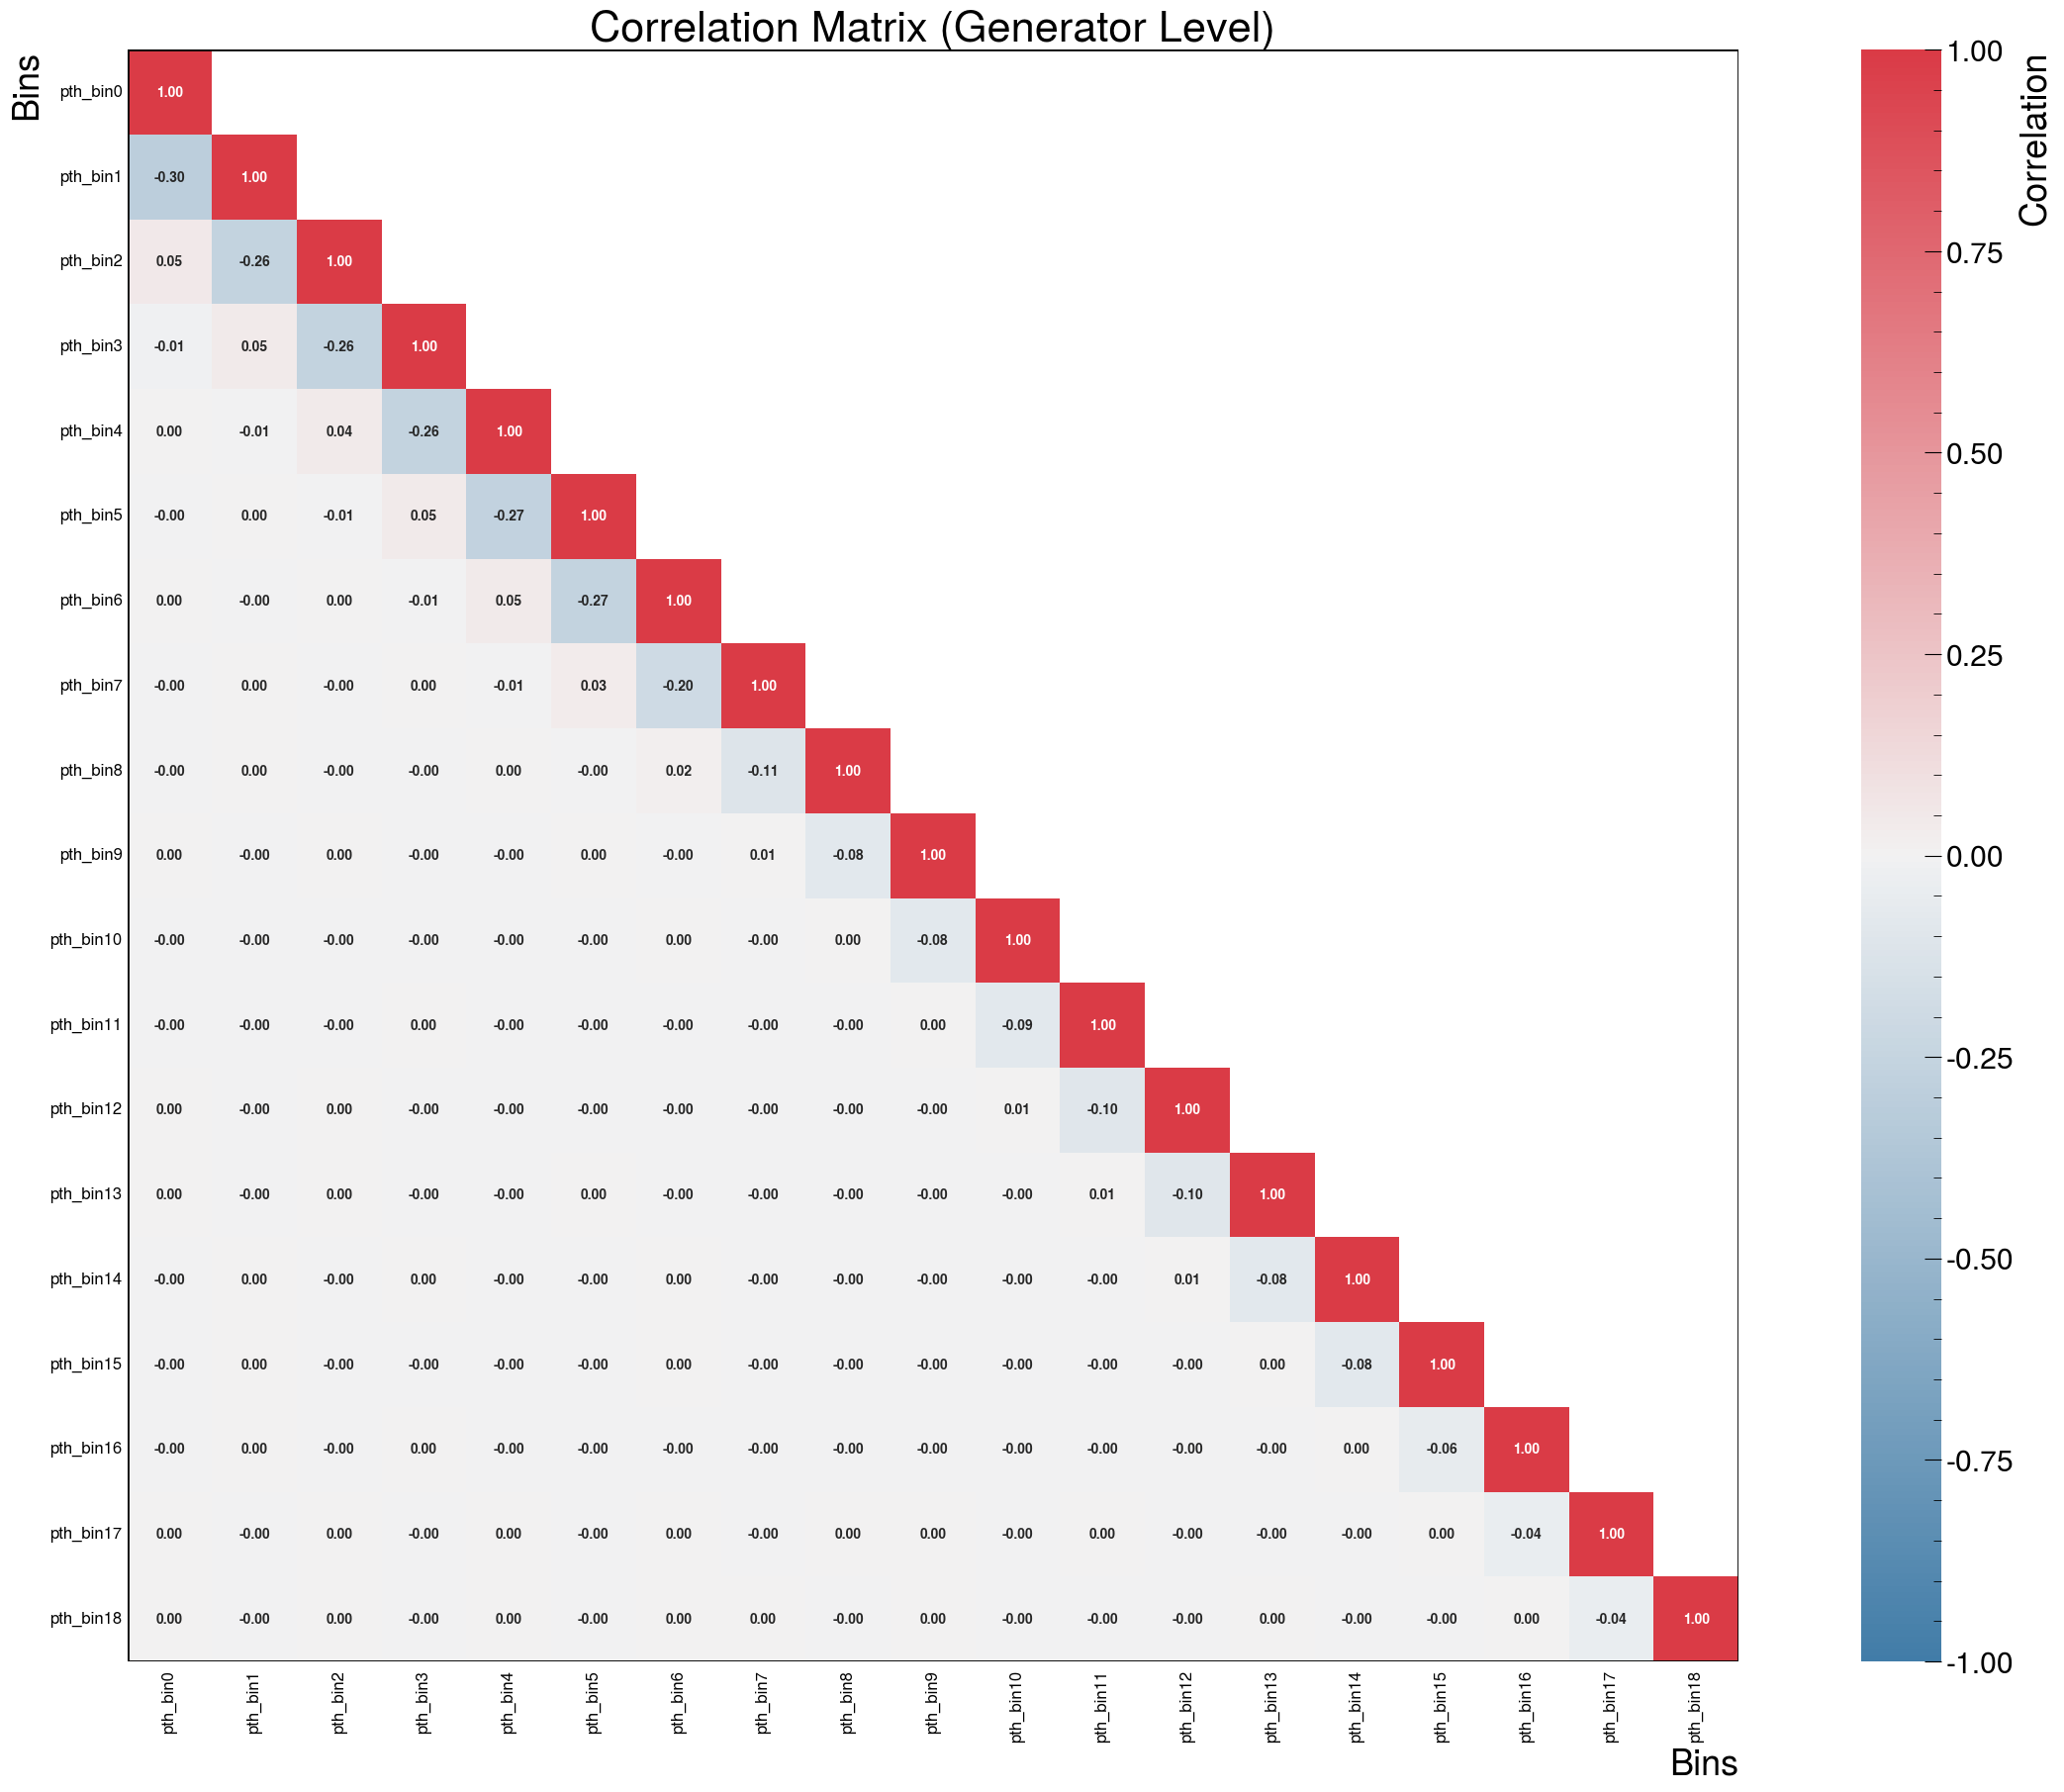

In [1281]:
# plot_corr(corr_gen_cat_0)
# plot_corr(corr_gen_noinv_cat_0)
# print("--------------------------------")
# plot_corr(corr_gen_cat_1)
# plot_corr(corr_gen_noinv_cat_1)
# print("--------------------------------")
# plot_corr(corr_gen_cat_2)
# plot_corr(corr_gen_noinv_cat_2)
# print("--------------------------------")
plot_corr(corr_gen)
# plot_corr(corr_from_cov(invert_matrix(fisher_cat['cat2'] + fisher_cat['cat1'] + fisher_cat['cat0'])))

Here I try the great idea we had with Mauro, combining the covariance and response matrices

71.42892106293054
['pth_bin0', 'pth_bin1', 'pth_bin2', 'pth_bin3', 'pth_bin4', 'pth_bin5', 'pth_bin6', 'pth_bin7', 'pth_bin8', 'pth_bin9', 'pth_bin10', 'pth_bin11', 'pth_bin12', 'pth_bin13', 'pth_bin14', 'pth_bin15', 'pth_bin16', 'pth_bin17', 'pth_bin18']


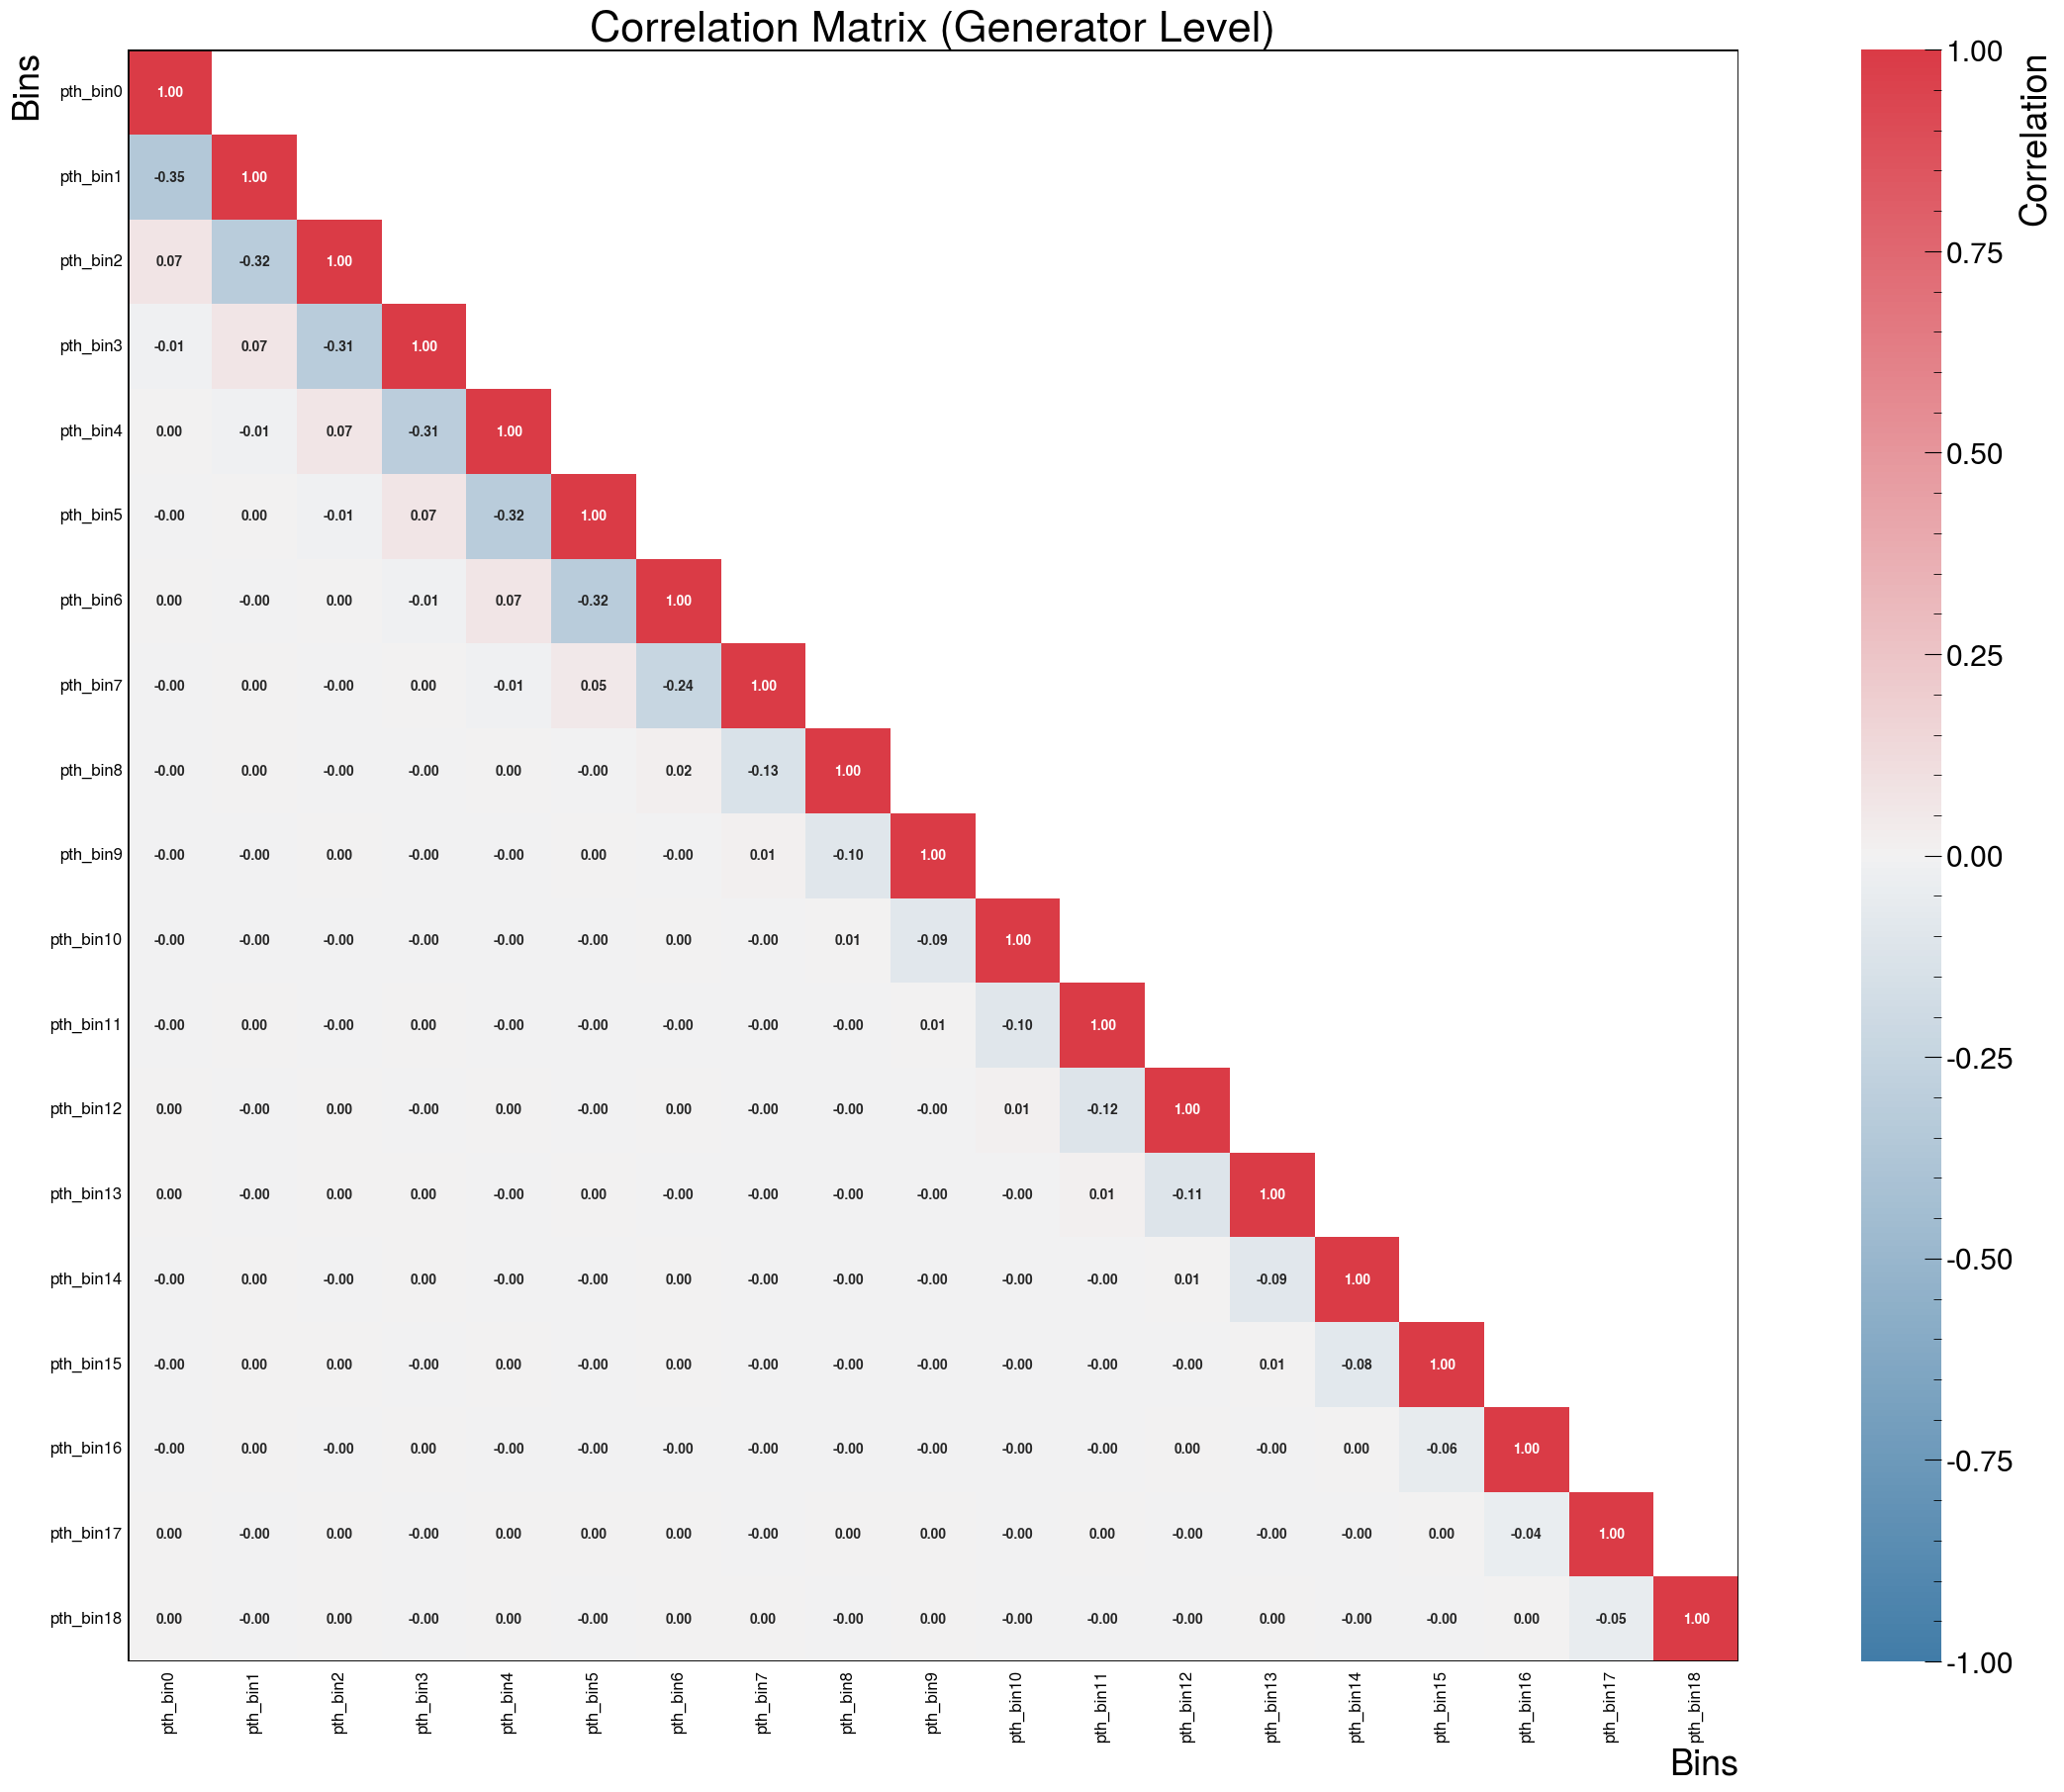

In [1282]:
## Compute the combined response matrix
## It is done by combining the covariance matrices of three independent measurements 
## cov_weighed = (cov["cat0"]^-1 + cov["cat1"]^-1 + cov["cat2"]^-1)^-1
cov_weighed = invert_matrix(invert_matrix(cov["cat0"]).add(invert_matrix(cov["cat1"]), fill_value=0).add(invert_matrix(cov["cat2"]), fill_value=0))
# plot_corr(corr_from_cov(cov_weighed))
# ## Compute the combined response matrix
# ## It is done by taking the weighed average element by element of the three response matrices
# ## The weights correspond to the corresponding covariances
cats = ["cat0", "cat1", "cat2"]
# R = np.stack([np.asarray(resp[c], float) for c in cats])   
# V = np.stack([np.asarray(cov[c],  float) for c in cats])   
# w = 1.0 / np.clip(V, 1e-15, None)                         
# resp_combined = np.sum(w * R, axis=0) / np.sum(w, axis=0)
# resp_combined = pd.DataFrame(resp_combined, index=resp["cat0"].index, columns=resp["cat0"].columns)


# Build the union of all row/column labels
all_rows = list(resp["cat0"].index)
all_cols = list(resp["cat0"].columns)

# Align all matrices to the same shape
R = np.stack([
    resp[c].reindex(index=all_rows, columns=all_cols, fill_value=0).to_numpy(float)
    for c in cats
])

V = np.stack([
    cov[c].reindex(index=all_rows, columns=all_cols, fill_value=np.inf).to_numpy(float)
    for c in cats
])

# Inverse-variance weights
w = 1.0 / np.clip(V, 1e-15, None)

# Weighted average
resp_combined = np.sum(w * R, axis=0) / np.sum(w, axis=0)

# Convert back to DataFrame
resp_combined = pd.DataFrame(
    resp_combined,
    index=all_rows,
    columns=all_cols,
)
print(np.linalg.cond(resp_combined))

cov_gen_weighed = invert_matrix(resp_combined) @ cov_weighed @ invert_matrix(resp_combined).T

print(all_rows)

plot_corr(corr_from_cov(cov_gen_weighed))

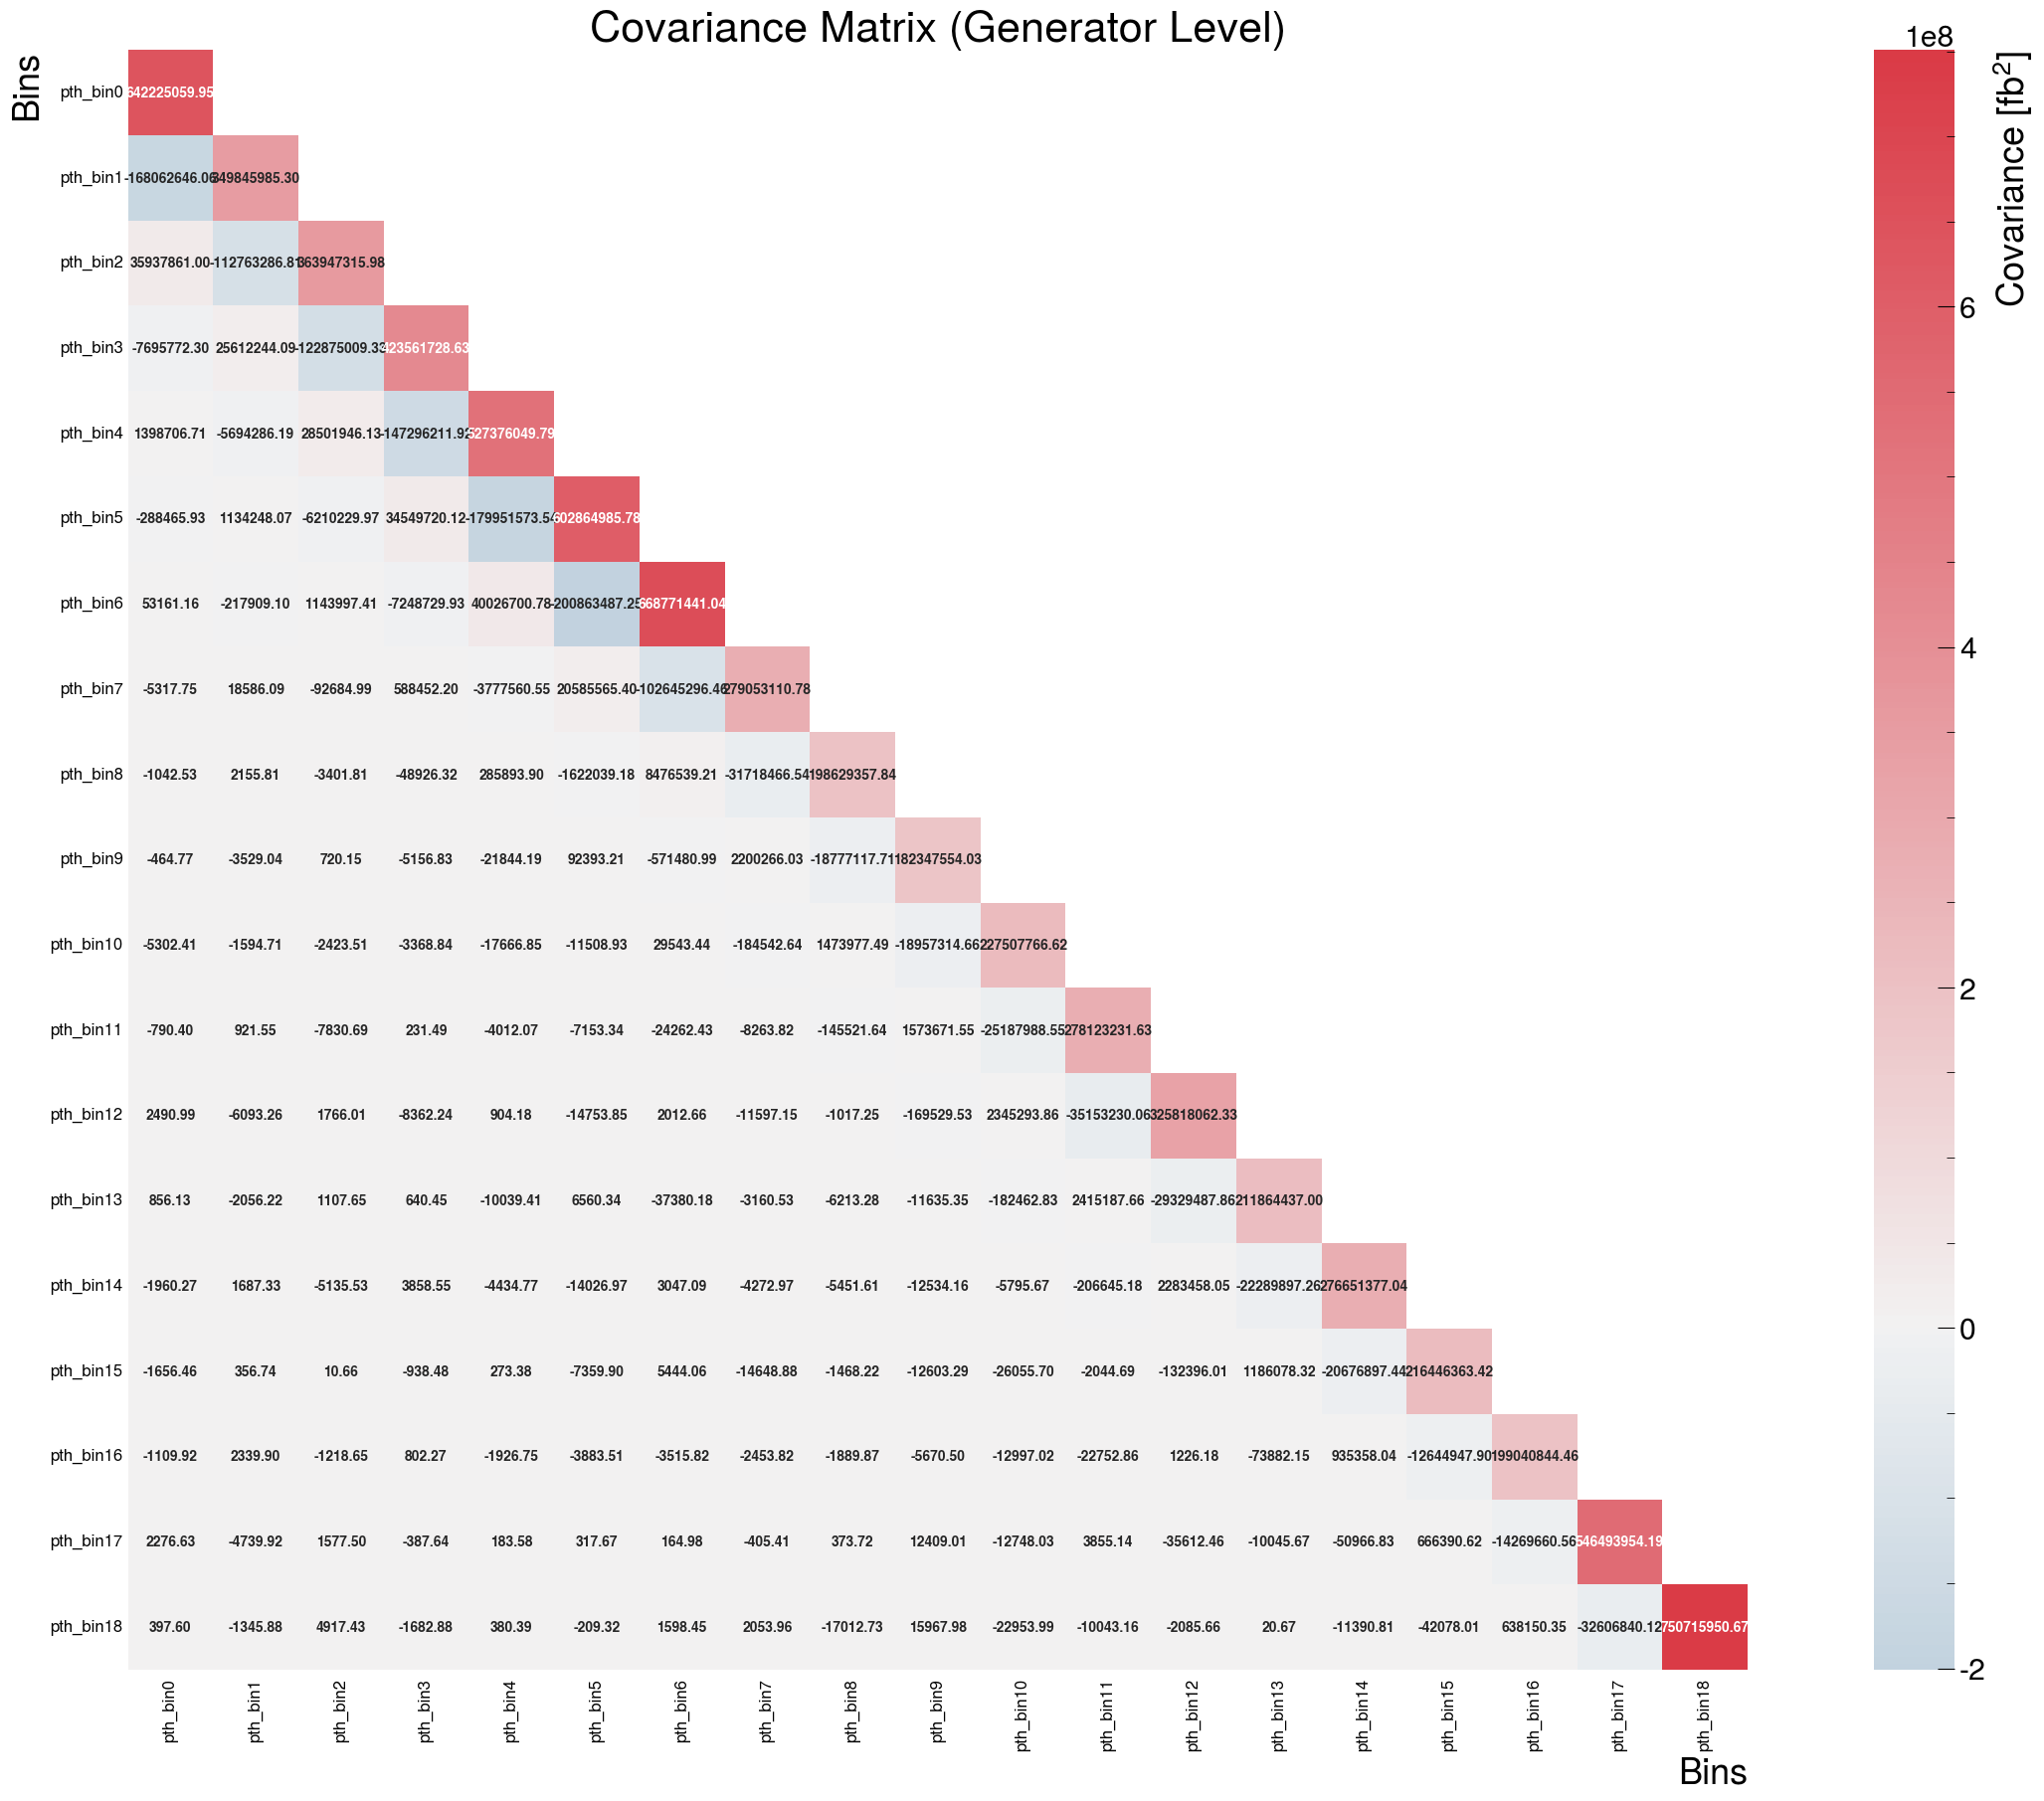

In [1283]:
plot_cov(cov_gen_weighed)

In [1284]:

cov_00 = compute_cov_from_df(df_dict['cat0'], df_dict['cat0'])
cov_01 = compute_cov_from_df(df_dict['cat0'], df_dict['cat1'])
cov_02 = compute_cov_from_df(df_dict['cat0'], df_dict['cat2'])
cov_10 = compute_cov_from_df(df_dict['cat1'], df_dict['cat0'])
cov_11 = compute_cov_from_df(df_dict['cat1'], df_dict['cat1'])
cov_12 = compute_cov_from_df(df_dict['cat1'], df_dict['cat2'])
cov_20 = compute_cov_from_df(df_dict['cat2'], df_dict['cat0'])
cov_21 = compute_cov_from_df(df_dict['cat2'], df_dict['cat1'])
cov_22 = compute_cov_from_df(df_dict['cat2'], df_dict['cat2'])

C_block_list = [
    [cov_00, cov_01, cov_02],  # Row for cat0
    [cov_10, cov_11, cov_12],  # Row for cat1
    [cov_20, cov_21, cov_22]   # Row for cat2
]

In [1285]:
def _robust_cholesky(C, regularisation=1e-10, max_tries=8):
    C = np.asarray(C, dtype=float)
    C = 0.5 * (C + C.T)  # enforce symmetry
    scale = max(np.linalg.norm(C, ord=2), 1.0)
    eps = regularisation * scale
    I = np.eye(C.shape[0])
    for _ in range(max_tries):
        print("iteration for cholesky with eps = ", eps)
        try:
            return np.linalg.cholesky(C + eps * I), eps
        except np.linalg.LinAlgError:
            eps *= 10.0
    print("Fallback solution for computing the Cholesky decomposition")
    # Fallback: eigenvalue clipping to nearest SPD-like matrix
    w, v = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    C_spd = (v * w) @ v.T
    return np.linalg.cholesky(C_spd), eps


# def compute_C_gen(R_list, C_list, bin_names=None, regularisation=1e-10):
#     """
#     Compute the gen-level statistical covariance and correlation matrices.

#     Parameters
#     ----------
#     R_list         : list of K arrays, each (n_reco_k, n_gen)
#     C_list         : list of K arrays, each (n_reco_k, n_reco_k)
#     bin_names      : list of n_gen strings for row/column labels (optional)
#     regularisation : float, diagonal loading factor (default 1e-10)

#     Returns
#     -------
#     dict with keys:
#         "covariance"   : pd.DataFrame (n_gen x n_gen)
#         "correlation"  : pd.DataFrame (n_gen x n_gen)
#     """

#     R_tilde_list = []
#     for k, (R_k, C_k) in enumerate(zip(R_list, C_list)):
#         # L_k = np.linalg.cholesky(C_k)
#         L_k, eps_used = _robust_cholesky(C_k, regularisation=regularisation)
#         R_tilde_list.append(solve_triangular(L_k, np.asarray(R_k, float), lower=True))

#     R_tot   = np.vstack(R_tilde_list)
#     _, R_QR = qr(R_tot, mode='economic')

#     n_gen    = R_QR.shape[0]
#     R_QR_inv = solve_triangular(R_QR, np.eye(n_gen), lower=False)
#     C_gen    = R_QR_inv @ R_QR_inv.T

#     std  = np.sqrt(np.diag(C_gen))
#     corr = np.clip(C_gen / np.outer(std, std), -1.0, 1.0)

#     # Build labels
#     if bin_names is None:
#         bin_names = [f"bin{i}" for i in range(n_gen)]

#     return {
#         "covariance"  : pd.DataFrame(C_gen, index=bin_names, columns=bin_names),
#         "correlation" : pd.DataFrame(corr,  index=bin_names, columns=bin_names),
#     }

def compute_C_gen(R_list, C_list, bin_names=None, regularisation=1e-10):
    """
    Compute the gen-level statistical covariance and correlation matrices.

    Parameters
    ----------
    R_list         : list of response matrices (DataFrames or arrays)
                     each shaped (n_reco_k, n_gen_k)
    C_list         : list of reco covariance matrices
                     each shaped (n_reco_k, n_reco_k)
    bin_names      : optional ordered list of gen-bin labels
    regularisation : float, diagonal loading factor

    Returns
    -------
    dict with keys:
        "covariance"   : pd.DataFrame
        "correlation"  : pd.DataFrame
    """

    # ---------------------------------------------------------
    # Determine common gen-bin ordering
    # Preserve ordering from first matrix, append missing bins
    # ---------------------------------------------------------

    if isinstance(R_list[0], pd.DataFrame):
        all_gen_bins = list(R_list[0].columns)

        for R in R_list[1:]:
            for col in R.columns:
                if col not in all_gen_bins:
                    all_gen_bins.append(col)
    else:
        if bin_names is None:
            raise ValueError(
                "bin_names must be provided when R_list elements are not DataFrames"
            )
        all_gen_bins = list(bin_names)

    # ---------------------------------------------------------
    # Build whitened response matrices
    # ---------------------------------------------------------

    R_tilde_list = []

    for k, (R_k, C_k) in enumerate(zip(R_list, C_list)):

        # ---------------------------------------------
        # Align response matrix columns
        # Missing bins are filled with zeros
        # ---------------------------------------------

        if isinstance(R_k, pd.DataFrame):
            R_k = (
                R_k
                .reindex(columns=all_gen_bins, fill_value=0)
                .to_numpy(float)
            )
        else:
            R_k = np.asarray(R_k, float)

        # ---------------------------------------------
        # Convert covariance matrix
        # ---------------------------------------------

        if isinstance(C_k, pd.DataFrame):
            C_k = C_k.to_numpy(float)
        else:
            C_k = np.asarray(C_k, float)

        # ---------------------------------------------
        # Robust Cholesky whitening
        # ---------------------------------------------

        L_k, eps_used = _robust_cholesky(
            C_k,
            regularisation=regularisation
        )

        R_tilde_k = solve_triangular(
            L_k,
            R_k,
            lower=True
        )

        R_tilde_list.append(R_tilde_k)

    # ---------------------------------------------------------
    # Stack all categories
    # Shape: (sum reco bins, n_gen_total)
    # ---------------------------------------------------------

    R_tot = np.vstack(R_tilde_list)

    # ---------------------------------------------------------
    # QR decomposition
    # ---------------------------------------------------------

    _, R_QR = qr(R_tot, mode='economic')
    
    n_gen = R_QR.shape[0]

    # ---------------------------------------------------------
    # Compute covariance
    # ---------------------------------------------------------

    R_QR_inv = solve_triangular(
        R_QR,
        np.eye(n_gen),
        lower=False
    )

    C_gen = R_QR_inv @ R_QR_inv.T


    # ---------------------------------------------------------
    # Correlation matrix
    # ---------------------------------------------------------

    std = np.sqrt(np.diag(C_gen))

    corr = np.clip(
        C_gen / np.outer(std, std),
        -1.0,
        1.0
    )
    
    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------

    if bin_names is None:
        bin_names = all_gen_bins

    return {
        "covariance": pd.DataFrame(
            C_gen,
            index=bin_names,
            columns=bin_names
        ),

        "correlation": pd.DataFrame(
            corr,
            index=bin_names,
            columns=bin_names
        ),
    }


# def compute_C_gen_dual_svd(R_list, C_list, bin_names=None, regularisation=1e-6, rcond_reco=1e-6, fisher_rcond=1e-3):
#     """
#     Computes C_gen using a dual-SVD approach to handle 1D+1D concatenated structures.
#     Bypasses Cholesky entirely to avoid LinAlgError crashes from sum-rule constraints, 
#     preserving full variable cross-correlations.
#     """
#     n_cat = len(R_list)
    
#     # 1. Vertically stack all response matrices to form the global R matrix
#     R_global = pd.concat(R_list, axis=0).to_numpy()
    
#     # 2. Construct the global C_reco block matrix (keeping cross-correlations intact)
#     raw_blocks = []
#     for i in range(n_cat):
#         row_numpy_blocks = [block.to_numpy() for block in C_list[i]]
#         raw_blocks.append(np.hstack(row_numpy_blocks))
        
#     C_reco_global = np.vstack(raw_blocks)
    
#     # 3. Gentle Tikhonov regularization
#     if regularisation > 0:
#         C_reco_global += regularisation * np.eye(C_reco_global.shape[0])
        
#     # 4. First SVD (Replaces Cholesky) to safely invert C_reco
#     U_reco, s_reco, Vt_reco = np.linalg.svd(C_reco_global, full_matrices=False)
    
#     # Filter out exact zero eigenvalues causing the rank deficiency
#     max_s_reco = np.max(s_reco)
#     s_reco_inv = np.where(s_reco > rcond_reco * max_s_reco, 1.0 / s_reco, 0.0)
    
#     # 5. Compute (C_reco^-1) @ R implicitly
#     C_reco_inv_R = Vt_reco.T @ (s_reco_inv[:, np.newaxis] * (U_reco.T @ R_global))
    
#     # 6. Compute the Fisher Information Matrix (preserving cross-correlations)
#     fisher_info = R_global.T @ C_reco_inv_R
    
#     # 7. Second SVD on the Fisher matrix to kill the unphysical rapidity noise mode
#     U_fish, s_fish, Vt_fish = np.linalg.svd(fisher_info, full_matrices=False)
    
#     # Filter the Fisher singular values aggressively to clean the rapidity block
#     max_s_fish = np.max(s_fish)
#     s_fish_inv = np.where(s_fish > fisher_rcond * max_s_fish, 1.0 / s_fish, 0.0)
    
#     # 8. Extract the final C_gen matrix
#     C_gen_matrix = Vt_fish.T @ (s_fish_inv[:, np.newaxis] * U_fish.T)
    
#     # 9. Convert back to clean pandas DataFrames
#     if bin_names is None:
#         bin_names = R_list[0].columns if hasattr(R_list[0], 'columns') else range(C_gen_matrix.shape[0])
        
#     C_gen_df = pd.DataFrame(C_gen_matrix, index=bin_names, columns=bin_names)
    
    # # ---------------------------------------------------------
    # # Correlation matrix computation
    # # ---------------------------------------------------------
    # std = np.sqrt(np.diag(C_gen_matrix))
    # std_safe = np.where(std == 0, 1e-16, std)
    
    # corr = np.clip(
    #     C_gen_matrix / np.outer(std_safe, std_safe),
    #     -1.0,
    #     1.0
    # )
    
    # corr_df = pd.DataFrame(corr, index=bin_names, columns=bin_names)

    # return {
    #     "covariance": C_gen_df,
    #     "correlation": corr_df
    # }
# def invert_with_tikhonov(I_gen, alpha_relative=1e-3):
#     """
#     Inverts I_gen using a smooth Tikhonov filter on the singular values.
#     Preserves matrix rank and avoids the 100% correlation "ghost bin" artifact
#     caused by hard TSVD truncation.
#     """
#     # 1. Compute SVD
#     U, S, Vt = np.linalg.svd(I_gen)
    
#     # 2. Define alpha based on the maximum singular value scale
#     max_s = np.max(S)
#     alpha = alpha_relative * max_s
    
#     # 3. Apply the smooth Tikhonov filter: s / (s^2 + alpha^2)
#     # This replaces the dangerous 1/s explosion with a smooth dampening
#     S_inv = S / (S**2 + alpha**2)
    
#     print(f"[Tikhonov Info] Stabilized {len(S)} modes with alpha_rel={alpha_relative}")
    
#     # 4. Reconstruct the stable covariance matrix
#     C_gen_stable = Vt.T @ np.diag(S_inv) @ U.T
    
#     return C_gen_stable

# def compute_C_gen(R_list, C_list, bin_names, regularisation=1e-9):
#     """
#     Computes C_gen with adaptive regularization and spectral cleaning 
#     to guarantee a positive-definite matrix for Cholesky decomposition.
#     """
#     # 1. Stack R matrices vertically
#     R_np = [r.values if hasattr(r, 'values') else np.asarray(r) for r in R_list]
#     R_full = np.vstack(R_np)
    
#     # 2. Assemble the giant global reconstruction covariance matrix
#     C_np_grid = []
#     for row in C_list:
#         np_row = [block.values if hasattr(block, 'values') else np.asarray(block) for block in row]
#         C_np_grid.append(np_row)
#     C_reco_full = np.block(C_np_grid)
    
#     # 3. Invert C_reco_full to get the global Weight matrix
#     W_full = invert_with_tikhonov(C_reco_full)
    
#     # 4. Compute the global Gen-level Fisher Information Matrix
#     I_gen = R_full.T @ W_full @ R_full
    
#     # 5. Adaptive Regularization: scale the nudge to the matrix's own internal scale
#     # This ensures the regularization isn't lost to floating-point rounding
#     matrix_scale = np.max(np.abs(np.diag(I_gen)))
#     nudge_value = regularisation * matrix_scale
#     I_gen_reg = I_gen + nudge_value * np.eye(I_gen.shape[0])
    
#     # 6. Invert the Information matrix to get the final Gen Covariance Matrix
#     C_gen = invert_with_tikhonov(I_gen_reg)
    
#     # 7. Spectral Decomposition to clean up numerical precision noise
#     # np.linalg.eigh is optimized for symmetric matrices
#     eigvals, eigvecs = np.linalg.eigh(C_gen)
    
#     # Check if there are non-trivial physical negative eigenvalues
#     min_eig = np.min(eigvals)
#     if min_eig < 0:
#         print(f"[Warning] Found negative eigenvalues due to numerical precision. Minimum eigenvalue: {min_eig:.4e}")
#         print(f"-> Applying spectral cleaning to protect Cholesky decomposition.")
        
#         # Clip all eigenvalues to a safe positive floor relative to the maximum eigenvalue
#         floor = np.max(eigvals) * 1e-14
#         eigvals_cleaned = np.maximum(eigvals, floor)
        
#         # Reconstruct the cleaned, strictly positive-definite C_gen
#         C_gen = eigvecs @ np.diag(eigvals_cleaned) @ eigvecs.T
        
#     # 8. Perform Cholesky Decomposition
#     L = scipy.linalg.cholesky(C_gen, lower=True)
        
#     # 9. Wrap back into a Pandas DataFrame
#     mat_cholesky = pd.DataFrame(L, index=bin_names, columns=bin_names)
    
#     # ---------------------------------------------------------
#     # Correlation matrix computation
#     # ---------------------------------------------------------
#     std = np.sqrt(np.diag(L))
#     std_safe = np.where(std == 0, 1e-16, std)
    
#     corr = np.clip(
#         L / np.outer(std_safe, std_safe),
#         -1.0,
#         1.0
#     )
    
#     corr_df = pd.DataFrame(corr, index=bin_names, columns=bin_names)

#     return {
#         "covariance": mat_cholesky,
#         "correlation": corr_df
#     }


In [1286]:
from __future__ import annotations
 
import warnings
from typing import Dict, List, Optional, Sequence, Tuple, Union
 
import numpy as np
import pandas as pd
from scipy.linalg import qr, solve_triangular


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------
 
def _robust_cholesky(
    M: np.ndarray,
    regularisation: float = 1e-10,
) -> Tuple[np.ndarray, float]:
    """
    Return lower-triangular Cholesky factor L of M, with diagonal loading
    if M is not positive-definite.  Also returns the epsilon actually used.
    """
    eps = 0.0
    for _ in range(50):
        try:
            L = np.linalg.cholesky(M + eps * np.eye(len(M)))
            return L, eps
        except np.linalg.LinAlgError:
            eps = max(regularisation, eps * 10) if eps > 0 else regularisation
    raise np.linalg.LinAlgError(
        "Cholesky failed after 50 attempts – covariance matrix may be singular."
    )
 
 
def _to_numpy(x: Union[np.ndarray, pd.DataFrame]) -> np.ndarray:
    if isinstance(x, pd.DataFrame):
        return x.to_numpy(float)
    return np.asarray(x, float)
 
 
# ---------------------------------------------------------------------------
# Public helper: split rapidity into low- and high-|eta| categories
# ---------------------------------------------------------------------------
 
def split_rapidity_categories(
    R_list: List[pd.DataFrame],
    C_list: List[pd.DataFrame],
    high_eta_bins: Sequence[str],
    rap_reco_bins: Optional[Sequence[str]] = None,
) -> Tuple[List[pd.DataFrame], List[pd.DataFrame]]:
    """
    Split every sigma_m/m category into two orthogonal sub-categories with
    respect to rapidity, isolating the |eta| > 1.2 bins (which use different
    sigma_m/m categorisation boundaries) as their own decoupled category.
 
      - "low-eta"  : all columns *except* the high-|eta| rapidity bins.
                     Uses the FULL reco covariance, so physical cross-
                     correlations between e.g. PTH and low-|eta| rapidity
                     gen-bins are preserved.
      - "high-eta" : only the high-|eta| rapidity columns are non-zero;
                     everything else is zeroed.  This block is decoupled
                     from all other gen-bins by construction.
 
    Why `rap_reco_bins` matters (the high-|eta| diagonal artifact)
    -------------------------------------------------------------
    PTH, rapidity, NJ, ... are different binnings of the SAME events, so the
    reco covariance has strong cross-observable correlations.  Inverting the
    FULL reco covariance yields the rapidity *conditional* precision
    (conditioned on PTH, which are the same events) instead of the *marginal*
    precision.  That conditional precision is hugely over-confident, which
    deflates the high-|eta| variances — the artifact you observed, and the
    reason it vanishes when you run rapidity alone (a sliced covariance gives
    the marginal precision).
 
    Because the high-|eta| bins are a *separate, decoupled* category, we can
    give them the correct marginal precision at no cost: pass `rap_reco_bins`
    (the reco-space labels spanning the rapidity observable) and the high-eta
    sub-category's covariance and response rows are sliced to that subspace.
    The low/other sub-category keeps the full covariance, so PTH <-> low-eta
    rapidity cross-correlations are untouched.
 
    Note: low-|eta| rapidity bins kept correlated with PTH necessarily share
    the same mechanism, so their variances also reflect the conditional
    (full-covariance) treatment.  That is unavoidable if you want to keep the
    PTH <-> low-eta rapidity cross-correlation — the cross-correlation and the
    conditional variance are two faces of the same off-diagonal reco block.
    Only the decoupled high-|eta| block can be cleanly given marginal
    precision, which is exactly the bins you flagged.
 
    Parameters
    ----------
    R_list : list of DataFrames, length n_cat
        Response matrices, one per sigma_m/m category, shape (n_reco, n_gen).
        Columns are gen-bin labels covering all observables; the DataFrame
        index holds the reco-bin labels.
    C_list : list of DataFrames, length n_cat
        Reco covariance matrices, shape (n_reco, n_reco), with the same
        reco-bin labels on both axes as the R_list index.
    high_eta_bins : sequence of str
        GEN-bin column names for the |eta| > 1.2 rapidity bins.
    rap_reco_bins : sequence of str, optional
        RECO-bin labels (present in R_list[i].index and C_list[i] axes) that
        span the rapidity observable.  When given, the high-eta sub-category
        is sliced to this reco subspace, fixing the over-confident variances.
        When None, the full covariance is reused (legacy behaviour) and a
        warning is emitted, since the high-|eta| variances may be deflated.
 
    Returns
    -------
    R_out, C_out : lists of DataFrames, length 2 * n_cat
        Interleaved [cat0_low, cat0_high, cat1_low, cat1_high, ...],
        ready to pass directly to compute_C_gen.
    """
    if len(R_list) != len(C_list):
        raise ValueError(
            f"R_list and C_list must have the same length "
            f"({len(R_list)} vs {len(C_list)})."
        )
 
    high_eta_set = set(high_eta_bins)
 
    if rap_reco_bins is None:
        warnings.warn(
            "rap_reco_bins not provided: the high-|eta| sub-category will reuse "
            "the FULL reco covariance, which can deflate the high-|eta| variances "
            "when observables share events (conditional vs marginal precision). "
            "Pass rap_reco_bins to slice the covariance and remove that artifact.",
            stacklevel=2,
        )
 
    R_out: List[pd.DataFrame] = []
    C_out: List[pd.DataFrame] = []
 
    for i, (R_k, C_k) in enumerate(zip(R_list, C_list)):
 
        all_gen_cols = list(R_k.columns)
 
        unknown = high_eta_set - set(all_gen_cols)
        if unknown:
            raise ValueError(
                f"high_eta_bins contains labels not found in R_list[{i}].columns: "
                f"{unknown}"
            )
 
        high_eta_cols = [c for c in all_gen_cols if c in high_eta_set]
        low_eta_cols  = [c for c in all_gen_cols if c not in high_eta_set]
 
        if not high_eta_cols:
            warnings.warn(
                f"Category {i}: no high-|eta| rapidity columns found – "
                "check high_eta_bins.",
                stacklevel=2,
            )
        if not low_eta_cols:
            warnings.warn(
                f"Category {i}: no low-|eta| columns remain after masking – "
                "check high_eta_bins.",
                stacklevel=2,
            )
 
        # ---- low/other sub-category: full covariance, high-eta cols zeroed ----
        R_low = R_k.copy()
        R_low[high_eta_cols] = 0.0
        R_out.append(R_low)
        C_out.append(C_k)
 
        # ---- high-eta sub-category: only high-eta cols non-zero ----
        if rap_reco_bins is None:
            # legacy: reuse full covariance (may be over-confident)
            R_high = R_k.copy()
            R_high[low_eta_cols] = 0.0
            R_out.append(R_high)
            C_out.append(C_k)
        else:
            missing = set(rap_reco_bins) - set(R_k.index)
            if missing:
                raise ValueError(
                    f"Category {i}: rap_reco_bins not found in R_list[{i}].index: "
                    f"{missing}"
                )
            missing_c = set(rap_reco_bins) - set(C_k.index)
            if missing_c:
                raise ValueError(
                    f"Category {i}: rap_reco_bins not found in C_list[{i}] axes: "
                    f"{missing_c}"
                )
            # slice rows to the rapidity reco subspace -> marginal precision
            R_high = R_k.loc[list(rap_reco_bins), :].copy()
            R_high[low_eta_cols] = 0.0
            C_high = C_k.loc[list(rap_reco_bins), list(rap_reco_bins)]
            R_out.append(R_high)
            C_out.append(C_high)
 
    return R_out, C_out
 
# ---------------------------------------------------------------------------
 
# Main function
# ---------------------------------------------------------------------------
 
def compute_C_gen(
    R_list: List[Union[pd.DataFrame, np.ndarray]],
    C_list: List[Union[pd.DataFrame, np.ndarray]],
    bin_names: Optional[List[str]] = None,
    regularisation: float = 1e-10,
) -> Dict[str, pd.DataFrame]:
    """
    Compute the gen-level statistical covariance and correlation matrices.
 
    Implements  C_gen = ( sum_k R_k^T C_reco,k^{-1} R_k )^{-1}
    via Cholesky whitening and QR decomposition – no explicit matrix inversion.
 
    Algorithm
    ---------
    1. Cholesky-whiten each category:
           ~R_k = L_k^{-1} R_k   where  C_k = L_k L_k^T
       so  ~R_k^T ~R_k = R_k^T C_k^{-1} R_k  (one Fisher-info block)
 
    2. Stack all ~R_k vertically:
           R_tot = vstack(~R_k),  shape (sum n_reco_k, n_gen)
       so  R_tot^T R_tot = C_gen^{-1}
 
    3. Economy QR of R_tot:
           R_tot = Q · R_QR
       so  R_QR^T R_QR = C_gen^{-1}
 
    4. Recover C_gen without inversion:
           W = R_QR^{-1}  (upper-triangular back-substitution)
           C_gen = W W^T
 
    Parameters
    ----------
    R_list : list of response matrices (DataFrames or arrays)
        Each shaped (n_reco_k, n_gen_k).  DataFrames must carry gen-bin
        names as columns; categories may cover overlapping or disjoint
        subsets of gen-bins (missing columns are zero-filled).
    C_list : list of reco covariance matrices
        Each shaped (n_reco_k, n_reco_k), matching the corresponding R.
    bin_names : optional ordered list of gen-bin labels
        Required when R_list elements are plain arrays.
    regularisation : float
        Diagonal loading applied to ill-conditioned reco covariances.
 
    Returns
    -------
    dict with keys
        "covariance"   : pd.DataFrame  (n_gen x n_gen)
        "correlation"  : pd.DataFrame  (n_gen x n_gen)
    """
 
    # ------------------------------------------------------------------
    # 1.  Global gen-bin ordering (union, order-preserving)
    # ------------------------------------------------------------------
    if isinstance(R_list[0], pd.DataFrame):
        all_gen_bins: List[str] = list(R_list[0].columns)
        for R in R_list[1:]:
            for col in R.columns:
                if col not in all_gen_bins:
                    all_gen_bins.append(col)
    else:
        if bin_names is None:
            raise ValueError(
                "bin_names must be provided when R_list elements are not DataFrames."
            )
        all_gen_bins = list(bin_names)
 
    n_gen = len(all_gen_bins)
 
    # ------------------------------------------------------------------
    # 2.  Cholesky-whiten each category's response matrix
    # ------------------------------------------------------------------
    R_tilde_list: List[np.ndarray] = []
 
    for k, (R_k, C_k) in enumerate(zip(R_list, C_list)):
 
        if isinstance(R_k, pd.DataFrame):
            R_k_np = (
                R_k
                .reindex(columns=all_gen_bins, fill_value=0.0)
                .to_numpy(float)
            )
        else:
            R_k_np = np.asarray(R_k, float)
            if R_k_np.shape[1] != n_gen:
                raise ValueError(
                    f"Category {k}: R has {R_k_np.shape[1]} gen-bins "
                    f"but {n_gen} expected from bin_names."
                )
 
        C_k_np = _to_numpy(C_k)
 
        L_k, eps_used = _robust_cholesky(C_k_np, regularisation=regularisation)
        if eps_used > 0:
            warnings.warn(
                f"Category {k}: reco covariance required regularisation "
                f"eps={eps_used:.2e}.",
                stacklevel=2,
            )
 
        # Forward substitution: ~R_k = L_k^{-1} R_k
        R_tilde_list.append(solve_triangular(L_k, R_k_np, lower=True))
 
    # ------------------------------------------------------------------
    # 3.  Stack and QR-decompose
    # ------------------------------------------------------------------
    R_tot = np.vstack(R_tilde_list)           # (sum n_reco_k, n_gen)
    _, R_QR = qr(R_tot, mode="economic")      # R_QR: (n_gen, n_gen) upper-triangular
 
    # ------------------------------------------------------------------
    # 4.  Recover C_gen via back-substitution  (W = R_QR^{-1})
    # ------------------------------------------------------------------
    W     = solve_triangular(R_QR, np.eye(n_gen), lower=False)
    C_gen = W @ W.T
 
    # ------------------------------------------------------------------
    # 5.  Correlation matrix
    # ------------------------------------------------------------------
    std      = np.sqrt(np.diag(C_gen))
    std_safe = np.where(std > 0, std, 1.0)
    corr     = np.clip(C_gen / np.outer(std_safe, std_safe), -1.0, 1.0)
 
    # ------------------------------------------------------------------
    # 6.  Package results
    # ------------------------------------------------------------------
    labels = bin_names if bin_names is not None else all_gen_bins
 
    return {
        "covariance":  pd.DataFrame(C_gen, index=labels, columns=labels),
        "correlation": pd.DataFrame(corr,  index=labels, columns=labels),
    }




In [1287]:
mat_cholesky = compute_C_gen(
    [resp["cat0"], resp["cat1"], resp["cat2"]],
    [cov["cat0"], cov["cat1"], cov["cat2"]],
    bin_names = cov["cat0"].index,
    regularisation=1e-10 # 1e-10
)

# mat_cholesky = compute_C_gen(
#     R_list=[resp["cat0"], resp["cat1"], resp["cat2"]],
#     C_list=C_block_list,
#     bin_names=resp["cat0"].columns,  # Note: bin_names should match the generator (column) bins of R
#     regularisation=1e-10
# )


In [1288]:
cor_cholesky = mat_cholesky["correlation"]
cov_cholesky = mat_cholesky["covariance"]
# label_to_drop = cor_cholesky.index[12]
# cor_cholesky_red = cor_cholesky.drop(index=label_to_drop, columns=label_to_drop)


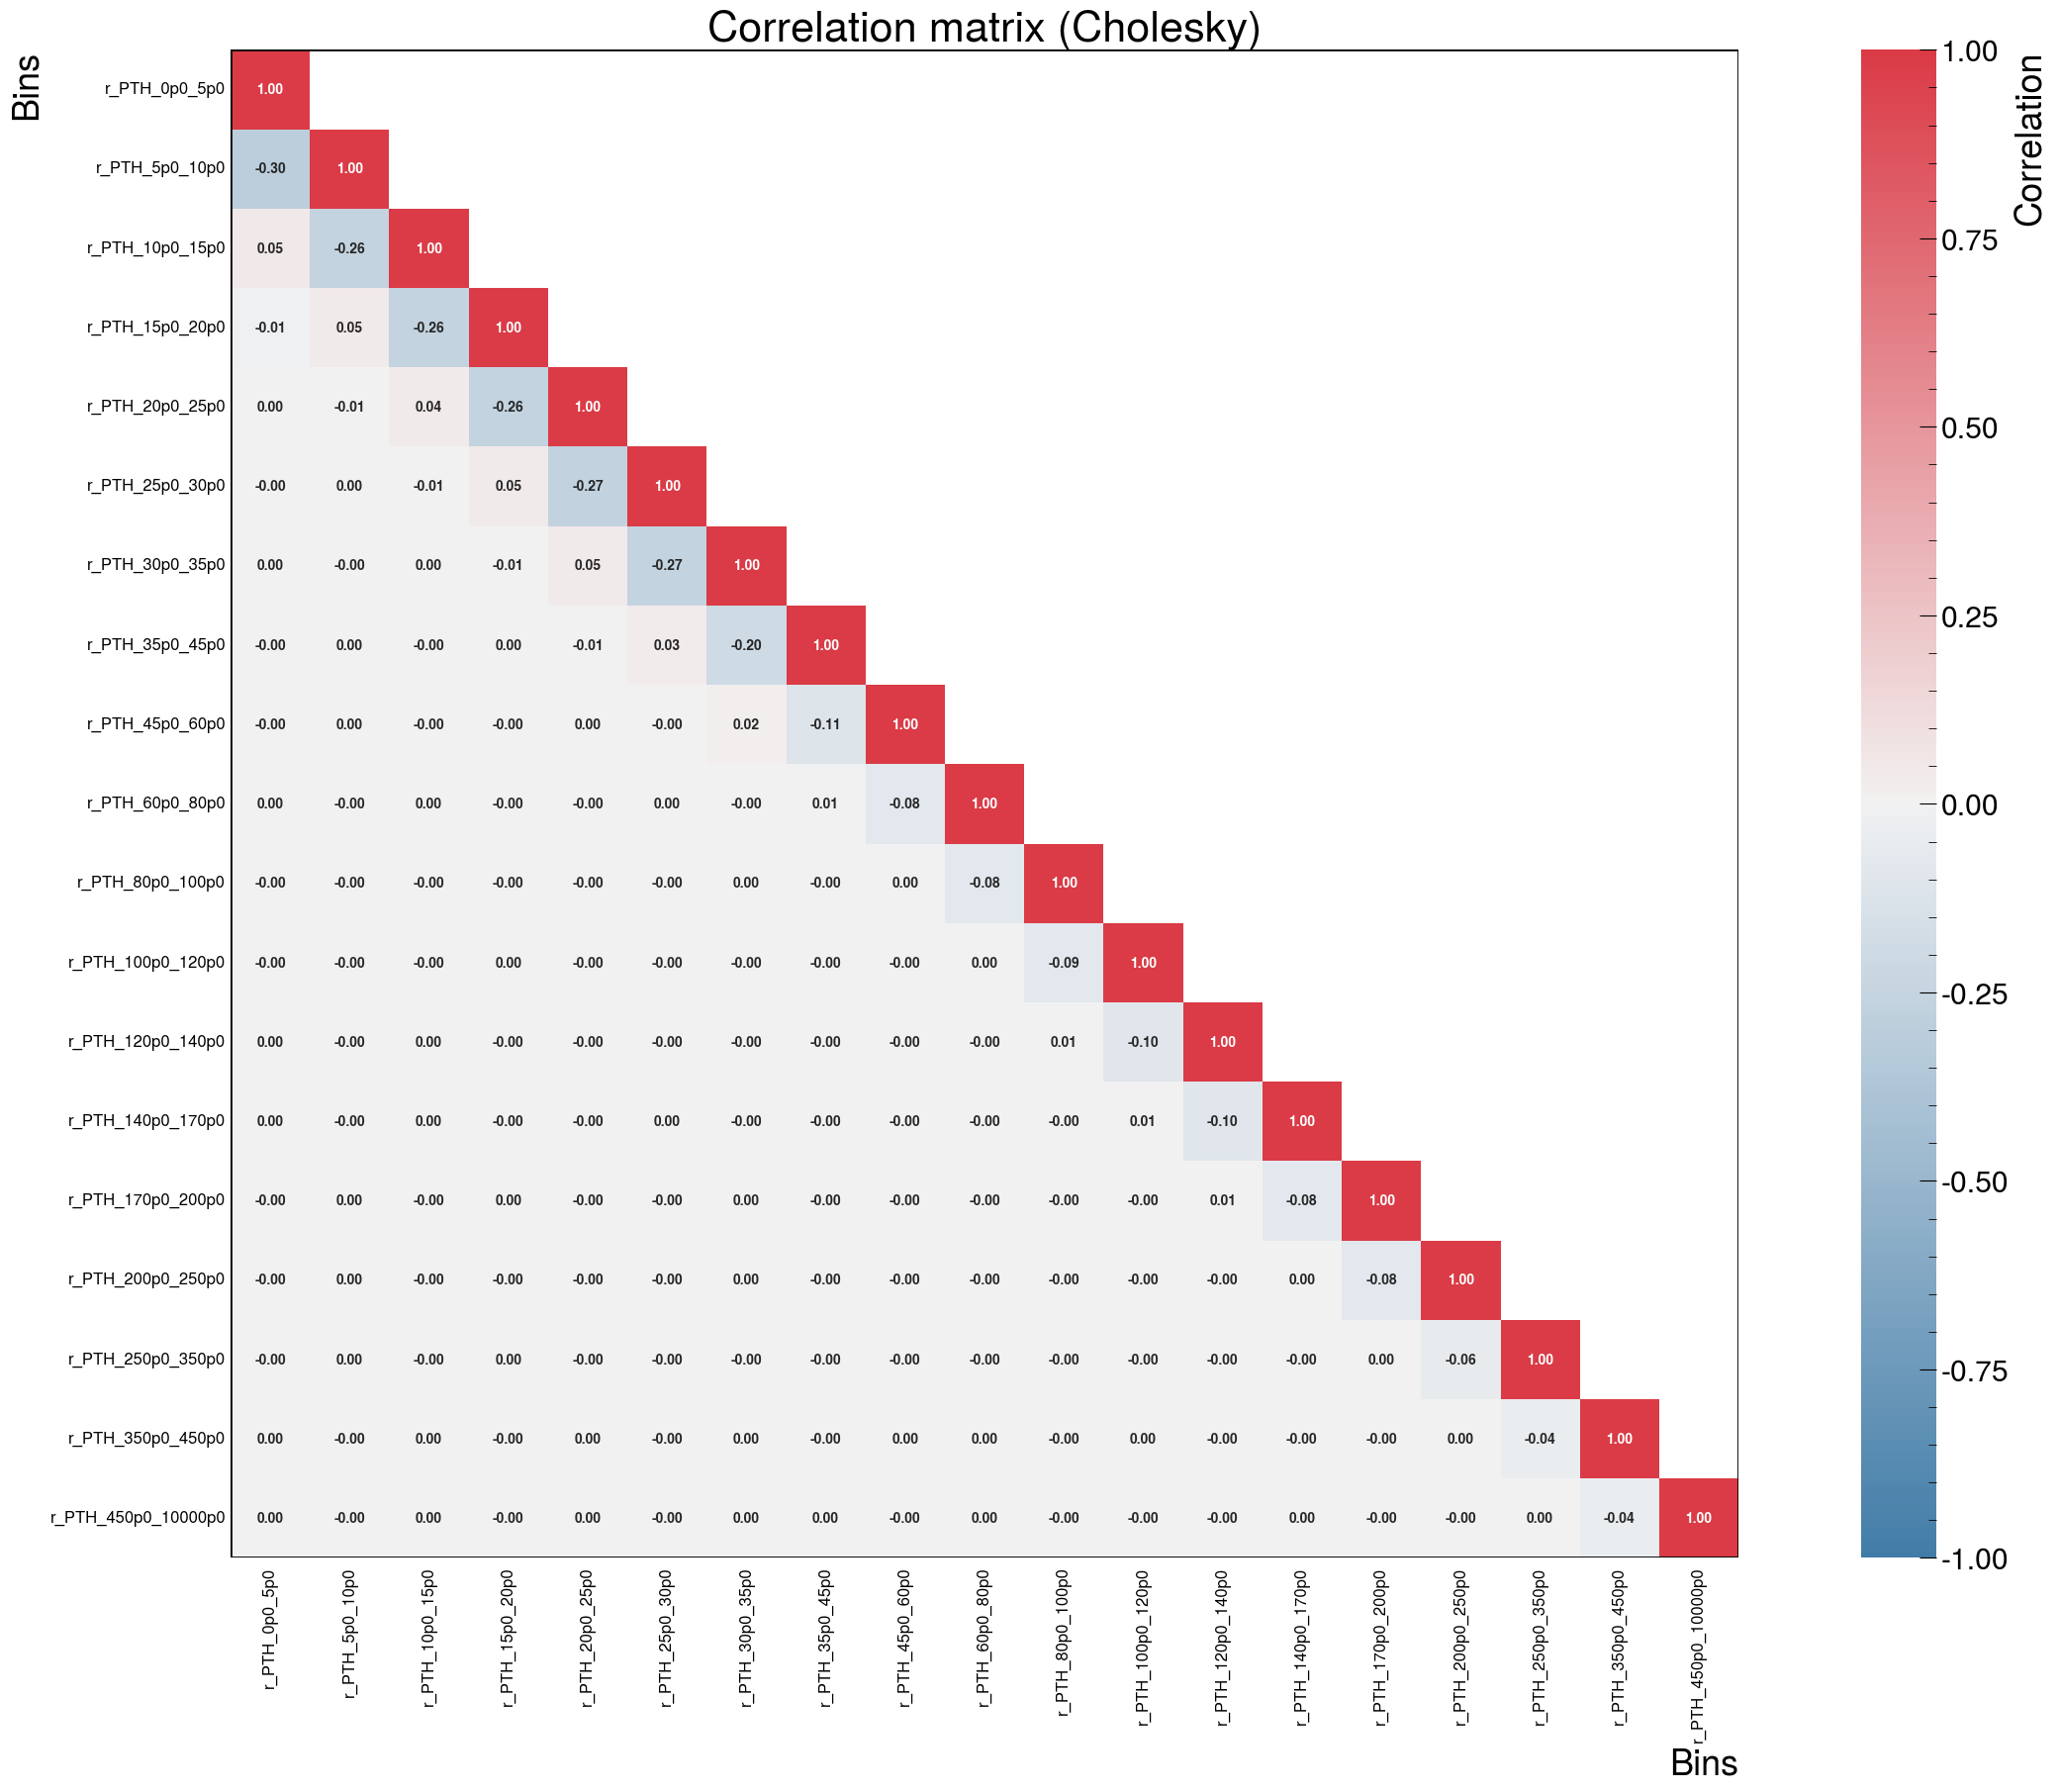

In [1289]:
# plot_corr(cor_cholesky_red, title="Correlation matrix (Cholesky)", save_path="correlation_matrix_cholesky_reduced.pdf", label_map=label_map)
plot_corr(cor_cholesky, title="Correlation matrix (Cholesky)", save_path="correlation_matrix_cholesky_reduced.pdf", label_map=label_map)
# plot_corr(res["correlation"], title="Correlation matrix (Cholesky)", save_path="correlation_matrix_cholesky_reduced.pdf", label_map=label_map)


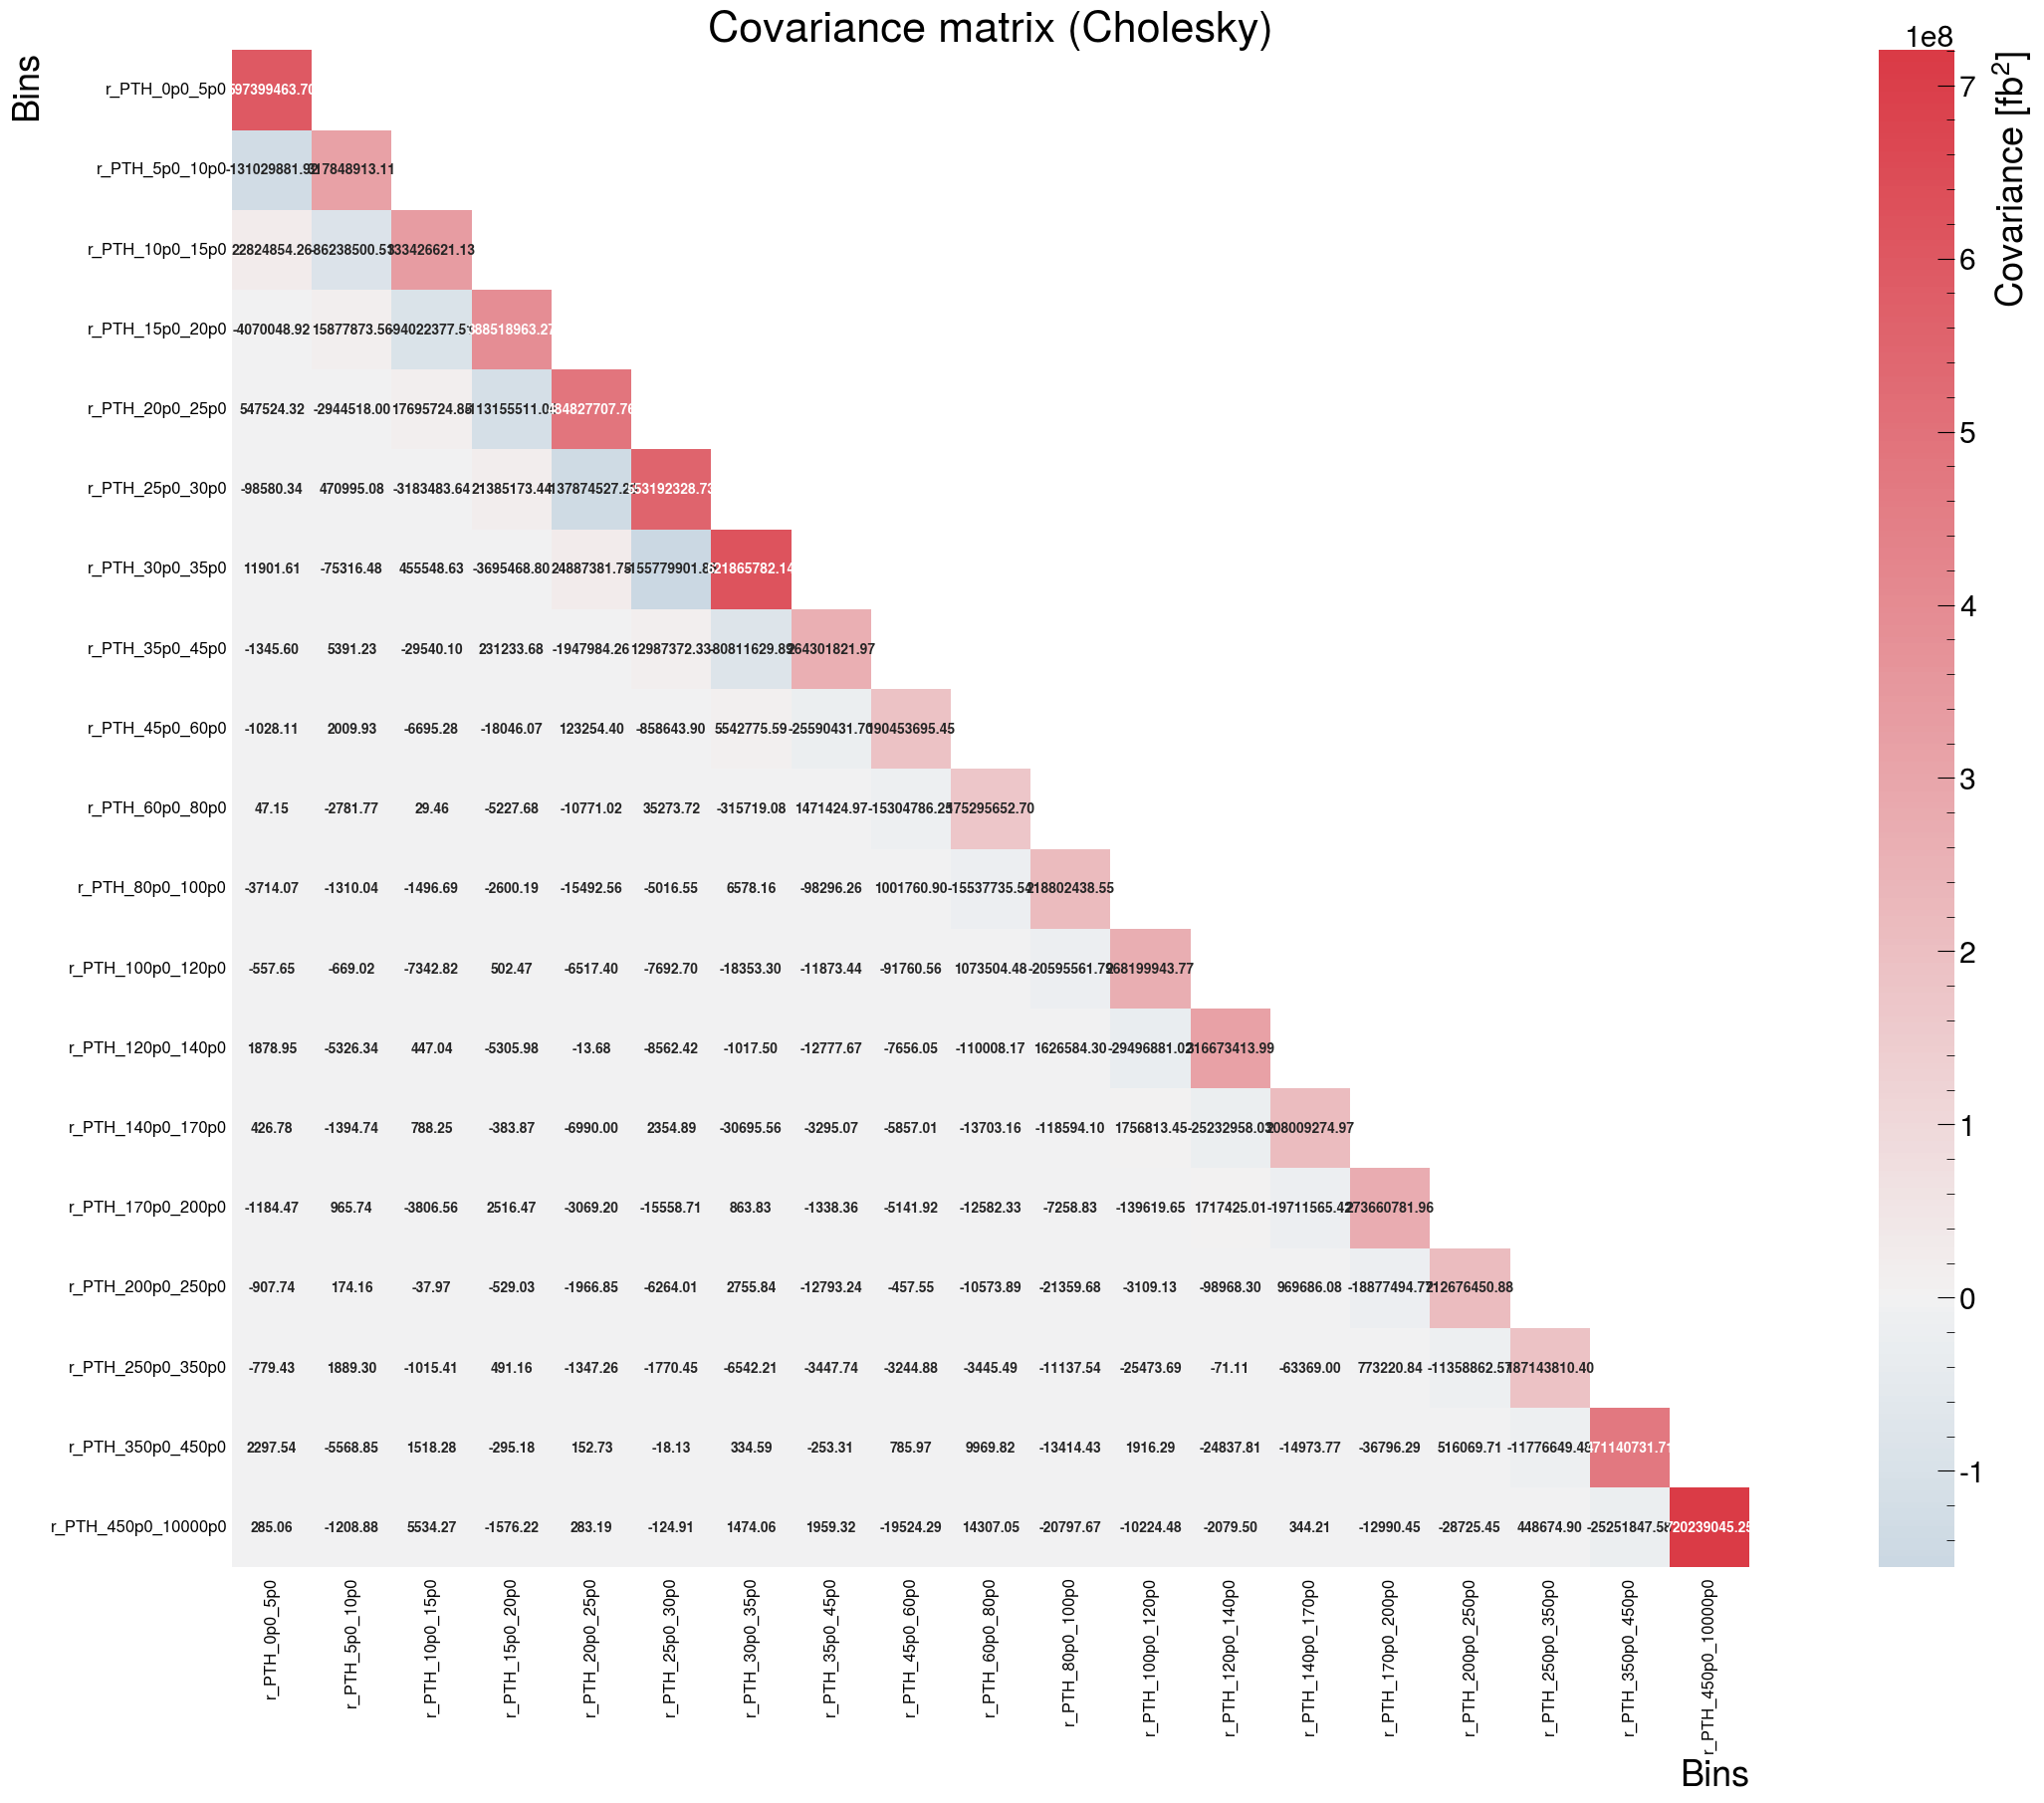

In [1290]:
plot_cov(cov_cholesky, title="Covariance matrix (Cholesky)", save_path="covariance_matrix_cholesky_reduced.pdf", label_map=label_map)


### Adding systematic uncertainties

In [1291]:
with open ("/t3home/niharrin/devel/work/devel/RCR_Matrix/impacts/impacts_PTJ0.json", "r") as f:
    impacts_ptJ0 = json.load(f)

with open ("/t3home/niharrin/devel/work/devel/RCR_Matrix/impacts/impacts_PTH.json", "r") as f:
    impacts_PTH = json.load(f)

with open ("/t3home/niharrin/devel/work/devel/RCR_Matrix/impacts/impacts_NJ.json", "r") as f:
    impacts_NJ = json.load(f)

# with open ("/t3home/niharrin/devel/work/devel/RCR_Matrix/impacts/impacts_YH.json", "r") as f:
#     impacts_YH = json.load(f)

with open ("/t3home/niharrin/devel/work/devel/RCR_Matrix/impacts/impacts_DPhiJ0J1.json", "r") as f:
    impacts_DPhiJ0J1 = json.load(f)

In [1292]:
nuis_params = set()
# Printout the list of nuisance parameters
# For debugging purposes
# with open("impact_param_names.txt", "w") as f:
#   f.write("[PTH]\n")
#   f.writelines(p["name"] + "\n" for p in impacts_PTH["params"])
#   f.write("\n[NJ]\n")
#   f.writelines(p["name"] + "\n" for p in impacts_NJ["params"])
#   f.write("\n[ptJ0]\n")
#   f.writelines(p["name"] + "\n" for p in impacts_ptJ0["params"])
#   f.write("\n[YH]\n")
#   f.writelines(p["name"] + "\n" for p in impacts_YH["params"])

sections = {
    "PTH": impacts_PTH,
    # "NJ": impacts_NJ,
    # "ptJ0": impacts_ptJ0,
    # "DPhiJ0J1": impacts_DPhiJ0J1,
}

with open("impact_param_names.txt", "w") as f:
    for label, impacts in sections.items():
        f.write(f"[{label}]\n")

        for p in impacts.get("params", []):
            name = p.get("name", "")
            f.write(name + "\n")
            nuis_params.add(name)

        f.write("\n")

nuis_params = sorted(nuis_params)  # optional: deterministic order

In [1293]:
import json


pois = {
    "PTH": ["r_PTH_0p0_5p0","r_PTH_5p0_10p0","r_PTH_10p0_15p0","r_PTH_15p0_20p0","r_PTH_20p0_25p0","r_PTH_25p0_30p0","r_PTH_30p0_35p0","r_PTH_35p0_45p0","r_PTH_45p0_60p0","r_PTH_60p0_80p0","r_PTH_80p0_100p0","r_PTH_100p0_120p0","r_PTH_120p0_140p0","r_PTH_140p0_170p0","r_PTH_170p0_200p0","r_PTH_200p0_250p0","r_PTH_250p0_350p0","r_PTH_350p0_450p0","r_PTH_450p0_10000p0"],
    # "NJ": ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_4p0", "r_NJ_4p0_100p0"],
    # "PTJ0": ["r_PTJ0_m10000p0_30p0", "r_PTJ0_30p0_40p0", "r_PTJ0_40p0_55p0", "r_PTJ0_55p0_75p0", "r_PTJ0_75p0_95p0", "r_PTJ0_95p0_120p0", "r_PTJ0_120p0_150p0", "r_PTJ0_150p0_200p0", "r_PTJ0_200p0_10000p0"],
    # "DPhiJ0J1": ["r_DPhiJ0J1_m3p1416_3p1416_underflow", "r_DPhiJ0J1_m3p1416_m1p5708", "r_DPhiJ0J1_m1p5708_0p0", "r_DPhiJ0J1_0p0_1p5708", "r_DPhiJ0J1_1p5708_3p1416"],
}

In [1294]:
idx_PTH  = {p["name"]: p for p in impacts_PTH["params"]}
# idx_NJ   = {p["name"]: p for p in impacts_NJ["params"]}
# idx_ptJ0 = {p["name"]: p for p in impacts_ptJ0["params"]}
# idx_DPhiJ0J1   = {p["name"]: p for p in impacts_DPhiJ0J1["params"]}


def variation(v):
    v0, v1, v2 = map(float, v)
    d1 = v2 - v1   # +1σ
    d2 = v0 - v1   # -1σ
    return np.sign(d1) * max(abs(d1), abs(d2))
    # return (d1 - d2) / 2
    # return d1

def block_vector(entry, pois):
    if entry is None:
        return [0.0] * len(pois)
    return [variation(entry[poi]) if poi in entry else 0.0 for poi in pois]

nuis_to_vector = {}
for n in nuis_params:  # full list you provide
    e_PTH  = idx_PTH.get(n)     # None if missing
    # e_NJ   = idx_NJ.get(n)
    # e_ptJ0 = idx_ptJ0.get(n)
    # e_DPhiJ0J1 = idx_DPhiJ0J1.get(n)
    vec = (
        block_vector(e_PTH,  pois["PTH"])# +
        # block_vector(e_NJ,   pois["NJ"])# +
        # block_vector(e_ptJ0, pois["PTJ0"])# +
        # block_vector(e_DPhiJ0J1, pois["DPhiJ0J1"])
    )
    nuis_to_vector[n] = np.array(vec, dtype=float).reshape(-1, 1)  # vertical


In [1295]:
## After this cell you have syst_matrix and syst_matrix_reduced
n_entries = len(pois["PTH"])# + len(pois["NJ"])# + len(pois["PTJ0"])# + len(pois["DPhiJ0J1"])
syst_matrix = np.zeros((n_entries, n_entries))
for nuis in nuis_params:
# for nuis in ["CMS_scale_j_2022postEE", "CMS_scale_j_2022preEE"]:
    syst_matrix += nuis_to_vector[nuis] @ nuis_to_vector[nuis].T

syst_matrix = pd.DataFrame(syst_matrix, index=cor_cholesky.index, columns=cor_cholesky.columns)
syst_matrix.index = cor_cholesky.index
syst_matrix.columns = cor_cholesky.index

In [1296]:
def find_crossings(x_vals, y_vals, threshold=1.0):
    # Find where the difference changes sign
    y_vals = np.array(y_vals)  # ← add this line
    signs = np.sign(y_vals - threshold)
    crossings = []
    for i in range(len(signs)-1):
        if signs[i] * signs[i+1] <= 0:  # Sign change detected
            # Linear interpolation
            x1, x2 = x_vals[i], x_vals[i+1]
            y1, y2 = y_vals[i], y_vals[i+1]
            if y1 != y2:  # Avoid division by zero
                x_cross = x1 + (x2-x1) * (threshold-y1)/(y2-y1)
                crossings.append(x_cross)
    return crossings

In [1297]:
fidXS_PTH = [3.251514094855517, 6.413825763609831, 6.555809968521467, 5.889800810939074, 5.099083112515962, 4.421885114513488, 3.866226543790849, 6.441680337807897, 6.902988952146682, 5.9025422289283505, 3.8146832368240626, 2.5035992765212907, 1.728313772250199, 1.7476552427460155, 1.0831025476943583, 1.0182794676925542, 0.8199434493201138, 0.25644320024731754, 0.16456440773573974]
fidXS_NJ = [36.46013279924294, 19.39595337442149, 8.780897688557815, 2.1285339711776765, 1.117648241828872]
fidXS_PTJ0 = [36.46013279924294, 6.663873021305533, 7.050146523728949, 5.894645706317997, 3.654783295750552, 2.8293975792219843, 1.990389506704825, 1.6537018867095121, 1.6860957562438337] 
fidXS_DPhiJ0J1 = [65.21952099254116, 0.8106934454948248, 0.5284340993292949, 0.5398399759381666, 0.7845488948952335] # Contains underflow bin

# We always take the bigger ones to be more conservative
uncMu_total_PTH = [0.481, 0.339, 0.355, 0.365, 0.410, 0.446, 0.457, 0.300, 0.258, 0.249, 0.260, 0.284, 0.305, 0.251, 0.287, 0.259, 0.259, 0.429, 0.582]
uncMu_stat_PTH = [0.480, 0.337, 0.354, 0.364, 0.406, 0.442, 0.455, 0.298, 0.256, 0.247, 0.258, 0.283, 0.304, 0.250, 0.285, 0.258, 0.258, 0.427, 0.580]
unc_total_PTH = [uncMu_total_PTH[i]*currentXS for i, currentXS in enumerate(fidXS_PTH)]
unc_stat_PTH = [uncMu_stat_PTH[i]*currentXS for i, currentXS in enumerate(fidXS_PTH)]
unc_syst_PTH = [np.sqrt(unc_total_PTH[i]**2 - unc_stat_PTH[i]**2) for i, _ in enumerate(unc_total_PTH)]

uncMu_total_NJ = [0.150, 0.223, 0.315, 0.672, 0.619]
uncMu_stat_NJ = [0.145, 0.220, 0.311, 0.665, 0.614]
unc_total_NJ = [uncMu_total_NJ[i]*currentXS for i, currentXS in enumerate(fidXS_NJ)]
unc_stat_NJ = [uncMu_stat_NJ[i]*currentXS for i, currentXS in enumerate(fidXS_NJ)]
unc_syst_NJ = [np.sqrt(unc_total_NJ[i]**2 - unc_stat_NJ[i]**2) for i, _ in enumerate(unc_total_NJ)]

uncMu_total_PTJ0 = [0.163, 0.958, 0.841, 0.751, 0.964, 0.927, 0.854, 0.594, 0.349]
uncMu_stat_PTJ0 = [0.155, 0.954, 0.836, 0.747, 0.960, 0.922, 0.851, 0.591, 0.346]
unc_total_PTJ0 = [uncMu_total_PTJ0[i]*currentXS for i, currentXS in enumerate(fidXS_PTJ0)]
unc_stat_PTJ0 = [uncMu_stat_PTJ0[i]*currentXS for i, currentXS in enumerate(fidXS_PTJ0)]
unc_syst_PTJ0 = [np.sqrt(unc_total_PTJ0[i]**2 - unc_stat_PTJ0[i]**2) for i, _ in enumerate(unc_total_PTJ0)]

uncMu_total_DPhiJ0J1 = [0.088, 0.616, 0.571, 0.566, 0.646]
uncMu_stat_DPhiJ0J1 = [0.083, 0.610, 0.563, 0.557, 0.640]
unc_total_DPhiJ0J1 = [uncMu_total_DPhiJ0J1[i]*currentXS for i, currentXS in enumerate(fidXS_DPhiJ0J1)]
unc_stat_DPhiJ0J1 = [uncMu_stat_DPhiJ0J1[i]*currentXS for i, currentXS in enumerate(fidXS_DPhiJ0J1)]
unc_syst_DPhiJ0J1 = [np.sqrt(unc_total_DPhiJ0J1[i]**2 - unc_stat_DPhiJ0J1[i]**2) for i, _ in enumerate(unc_total_DPhiJ0J1)]

unc_stat = unc_stat_PTH# + unc_stat_NJ# + unc_stat_PTJ0# + unc_stat_DPhiJ0J1
unc_syst = unc_syst_PTH# + unc_syst_NJ# + unc_syst_PTJ0# + unc_syst_DPhiJ0J1

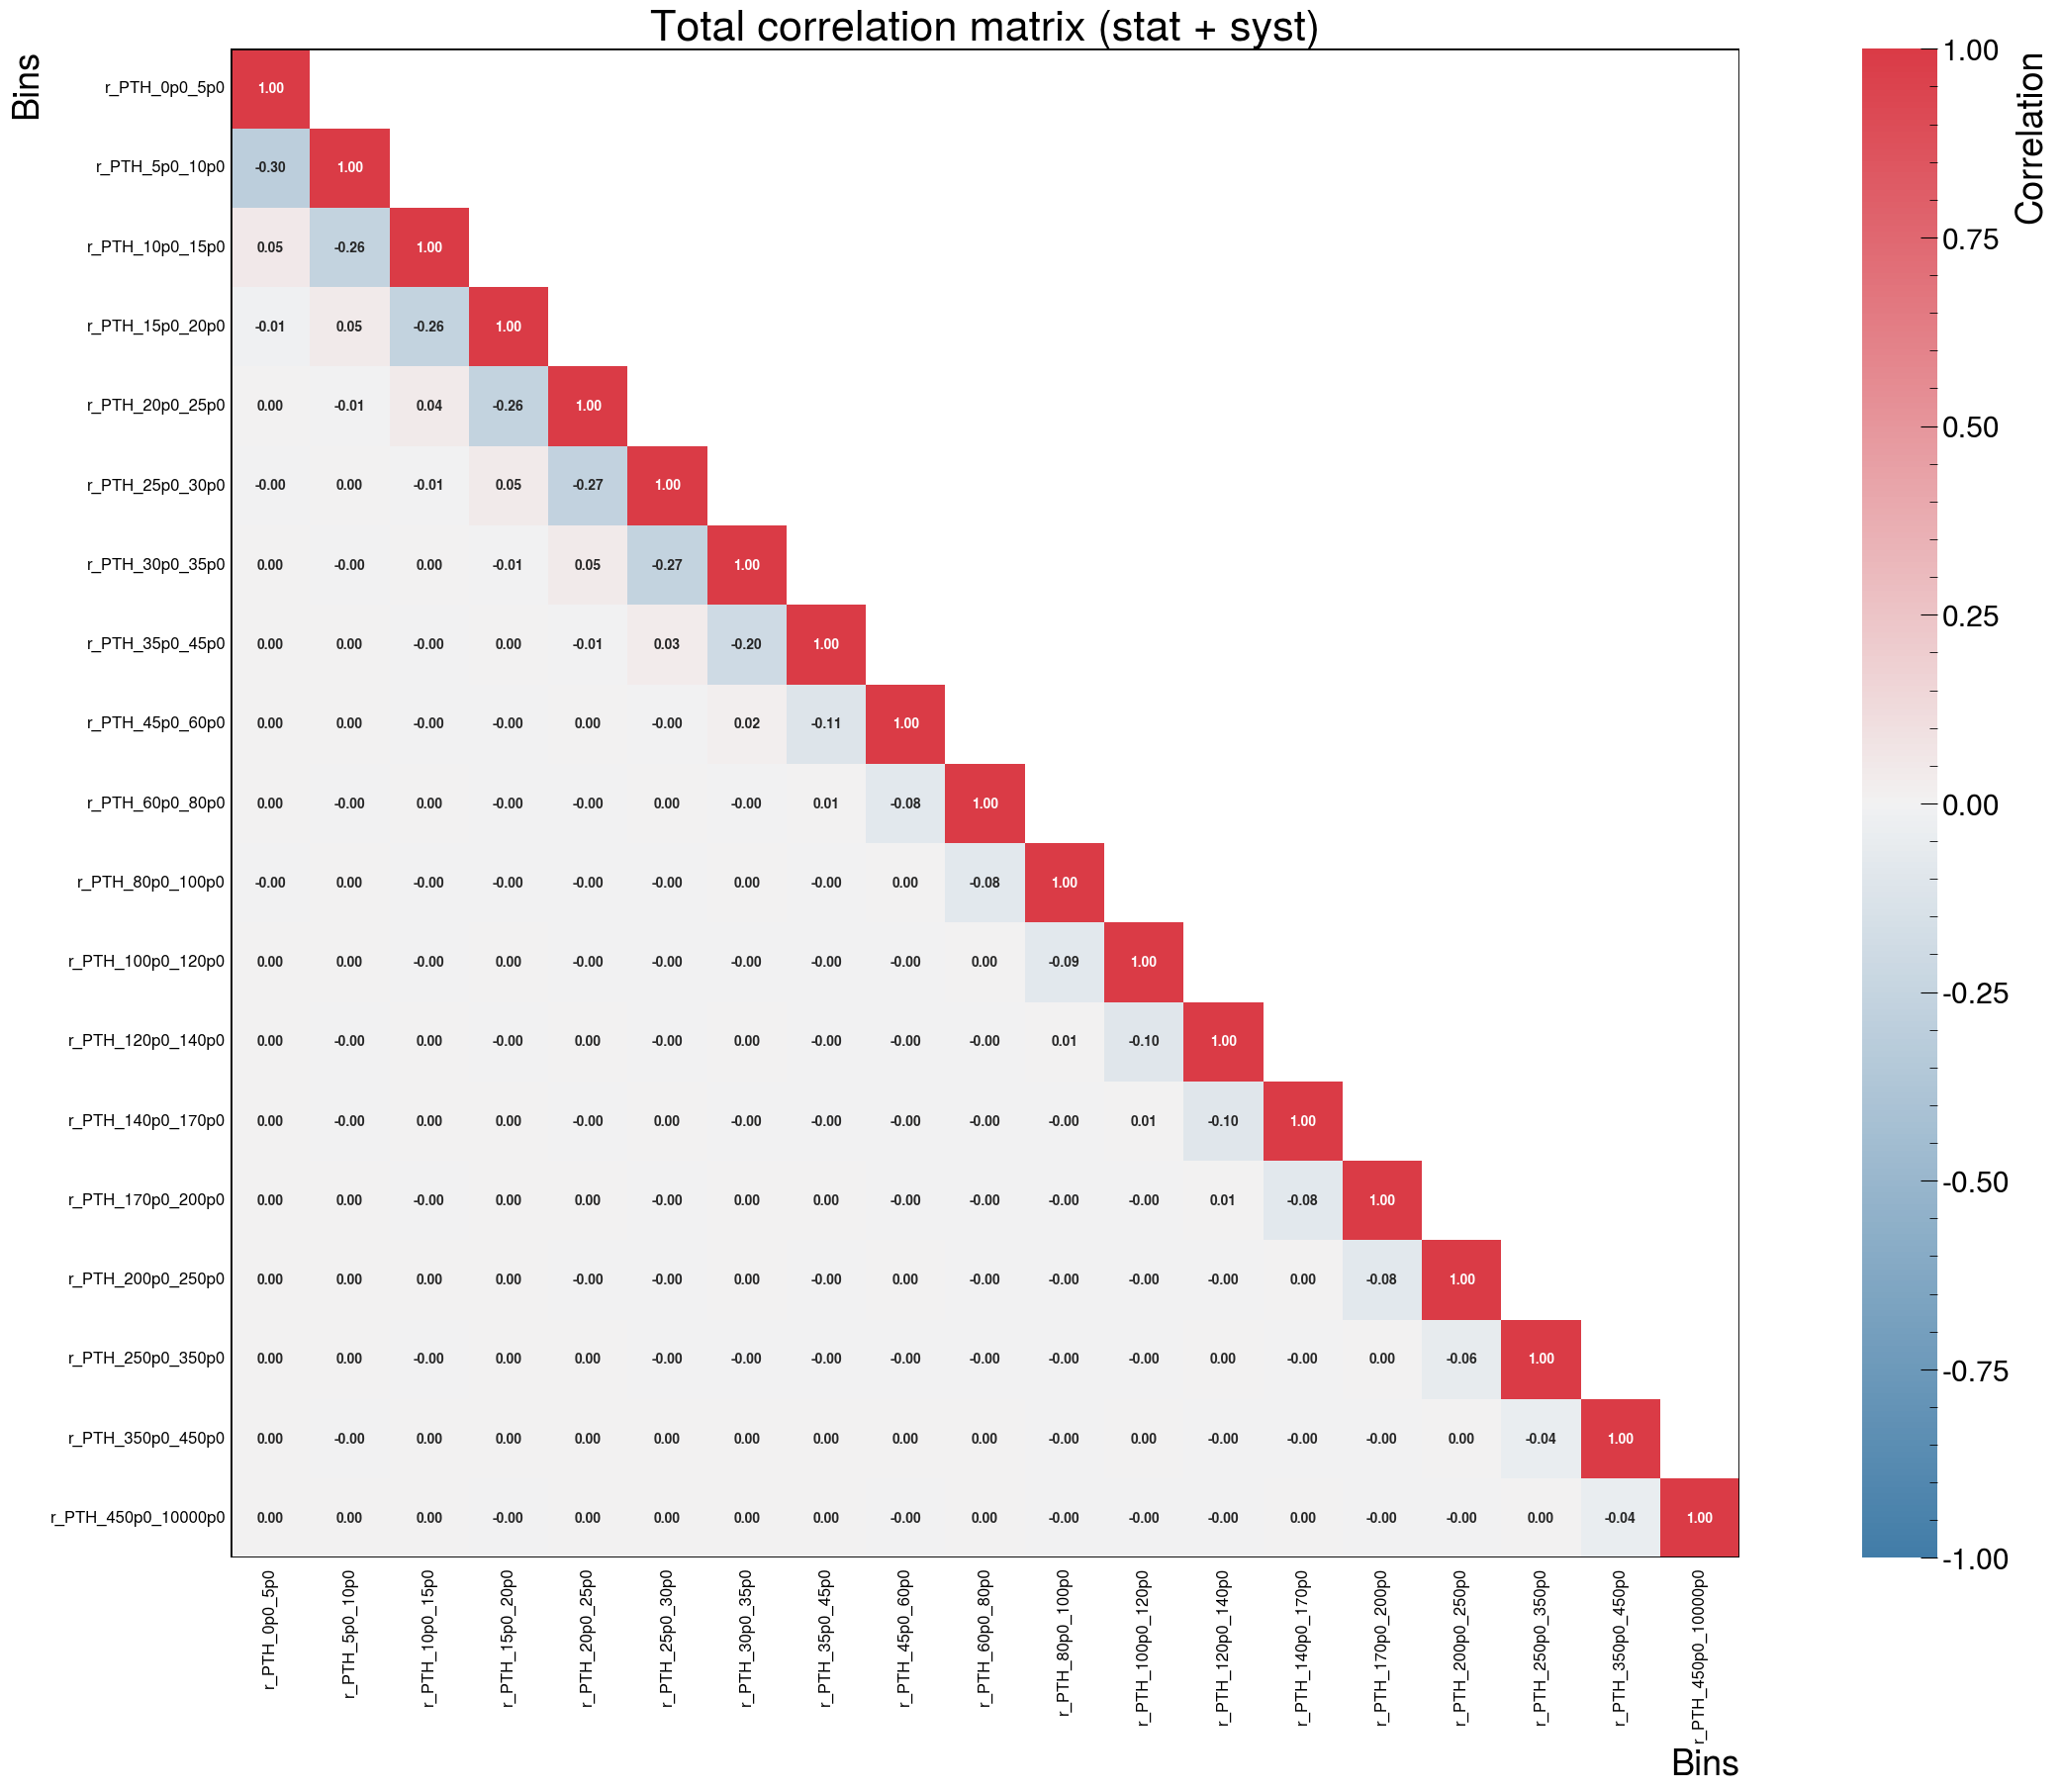

In [1298]:
cov_stat = cor_cholesky * np.outer(unc_stat, unc_stat)
cov_syst = syst_matrix * np.outer(unc_syst, unc_syst)

# # Remove underflow bin of PTJ0
# cov_stat = cov_stat.drop(index=["ptj0_bin0"], columns=["ptj0_bin0"])
# cov_syst = cov_syst.drop(index=["ptj0_bin0"], columns=["ptj0_bin0"])
# cov_stat = cov_stat.drop(index=["ptj0_bin0", "dphij0j1_bin0"], columns=["ptj0_bin0", "dphij0j1_bin0"])
# cov_syst = cov_syst.drop(index=["ptj0_bin0", "dphij0j1_bin0"], columns=["ptj0_bin0", "dphij0j1_bin0"])

# cov_stat = cor_cholesky * np.outer(unc_stat_syst, unc_stat_syst)
# cov_syst = syst_matrix * np.outer(unc_stat_syst, unc_stat_syst)
cov_tot = cov_stat + cov_syst
corr_tot = corr_from_cov(cov_tot)
plot_corr(corr_tot, title="Total correlation matrix (stat + syst)", save_path="correlation_matrix_total_reduced.pdf", label_map=label_map)

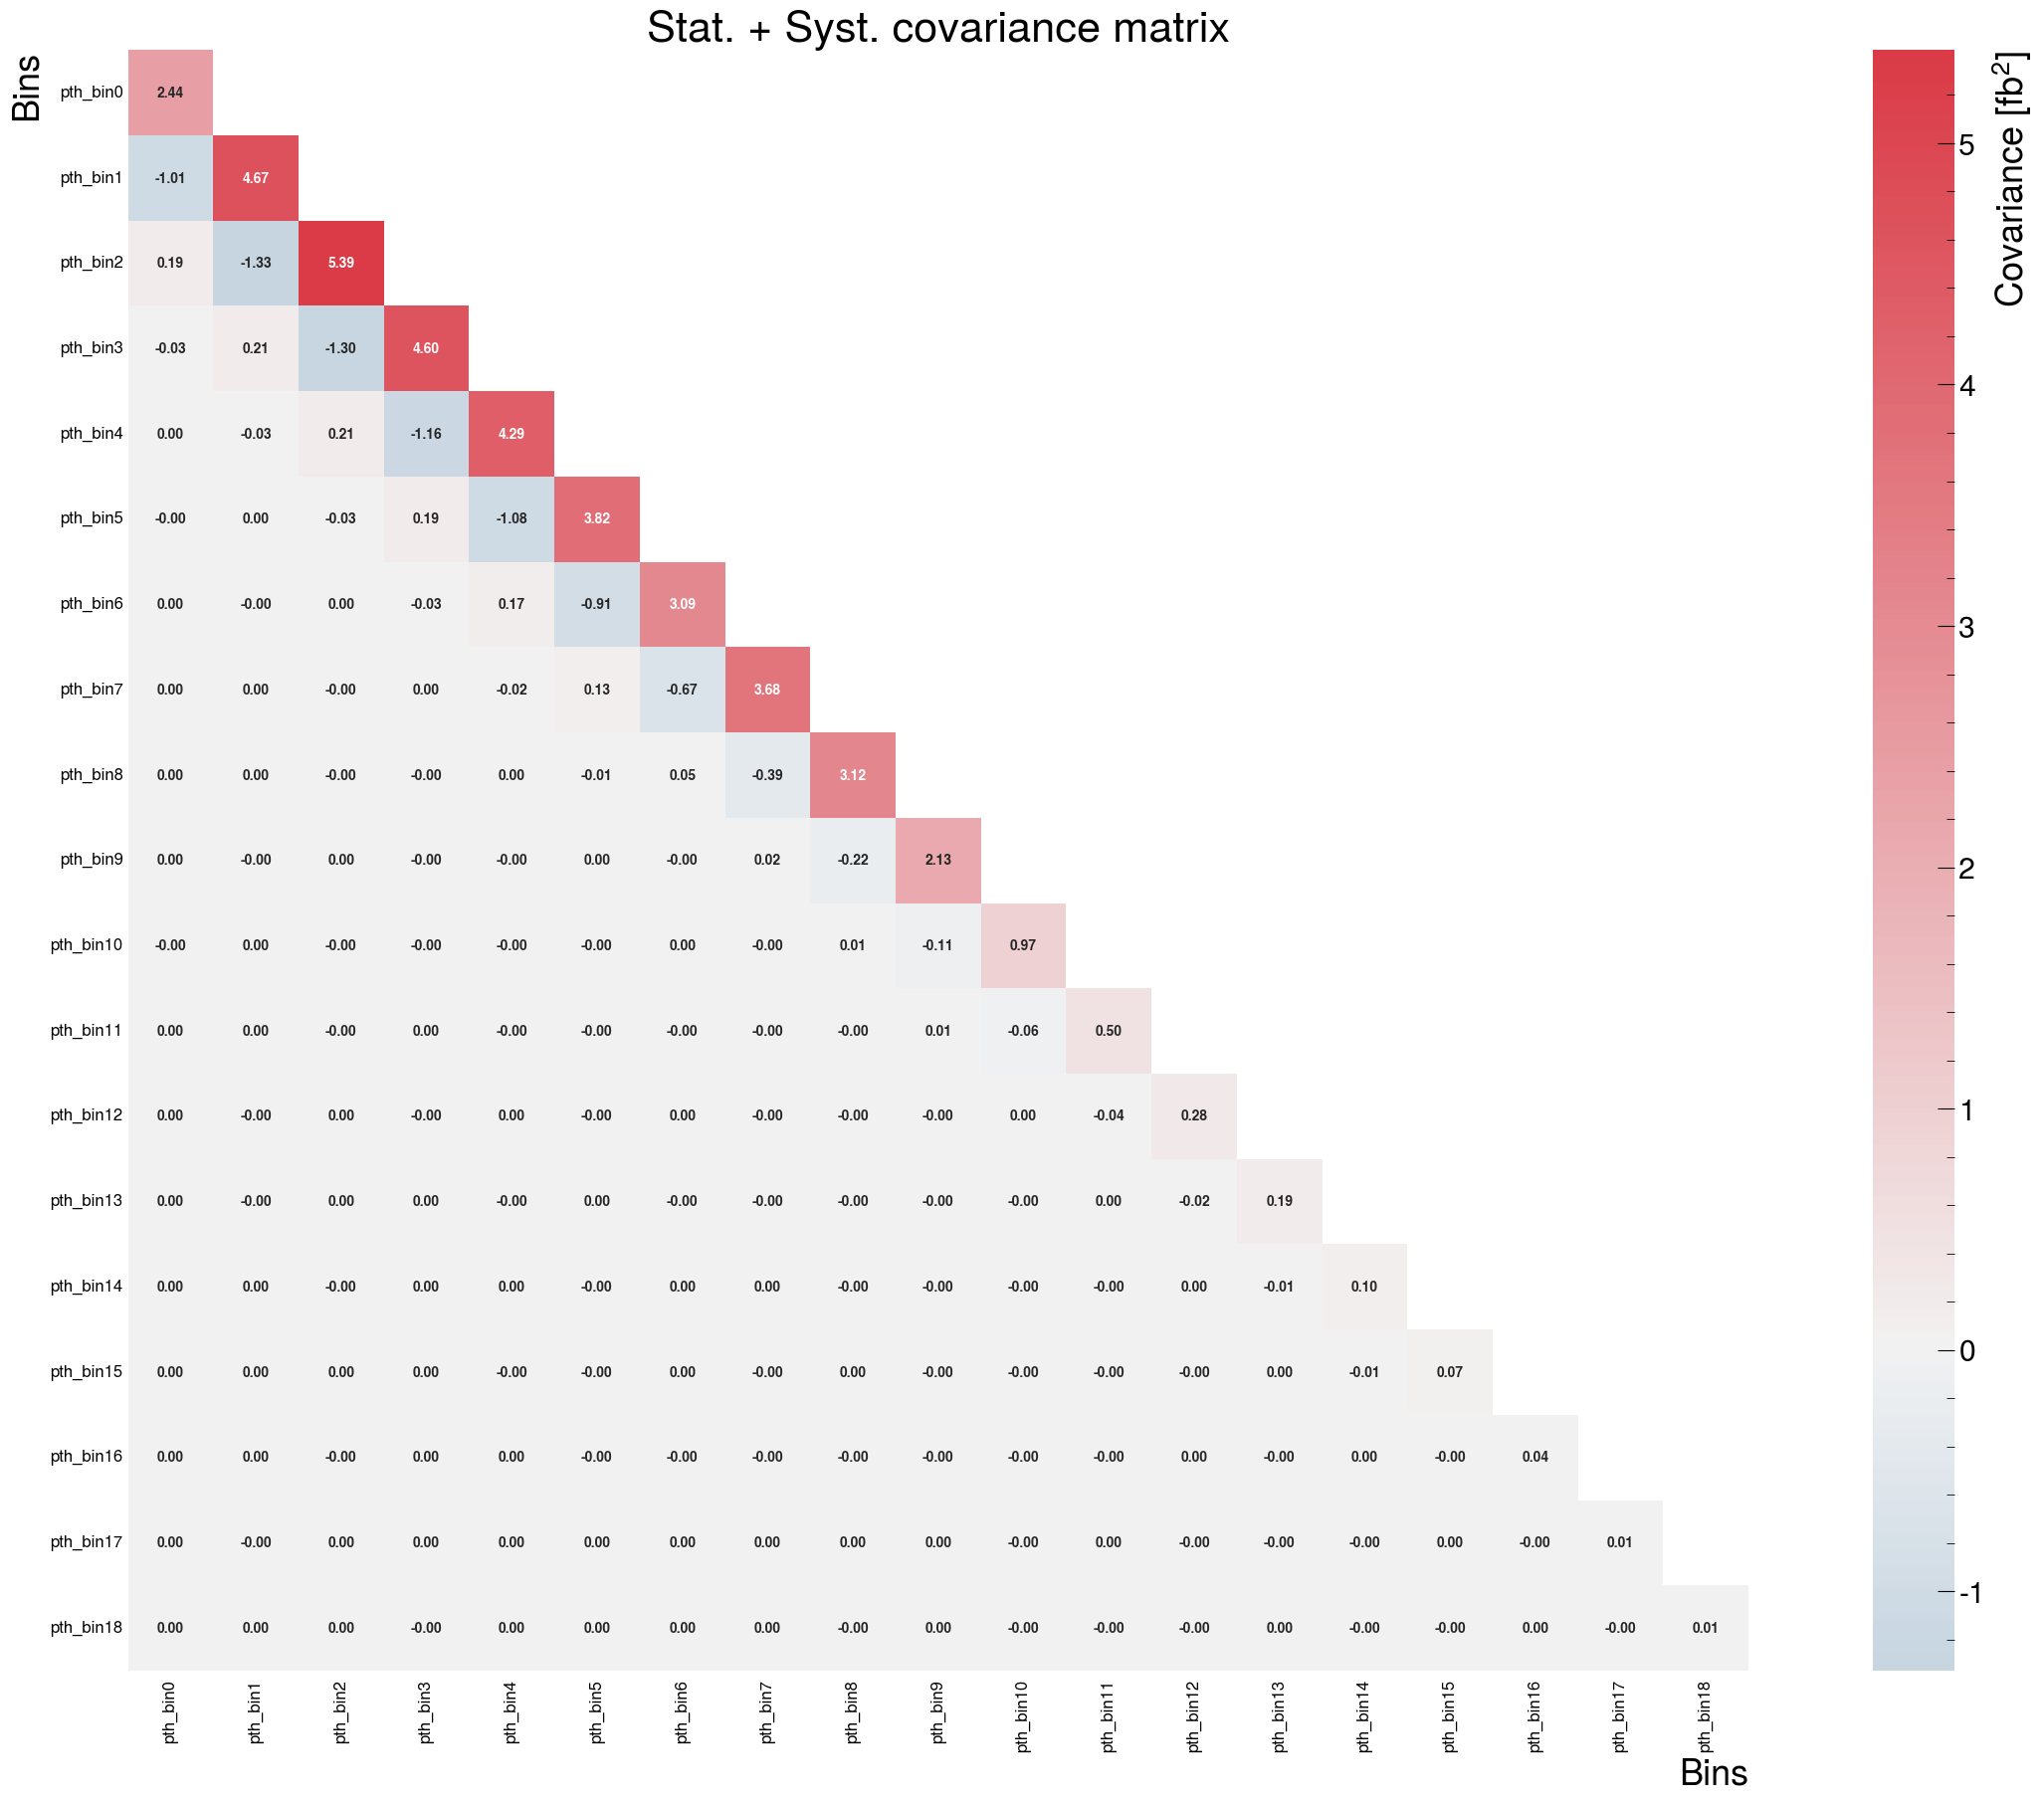

In [1299]:
plot_cov(cov_tot, title="Stat. + Syst. covariance matrix", save_path="covariance_matrix_statsyst_reduced.pdf")

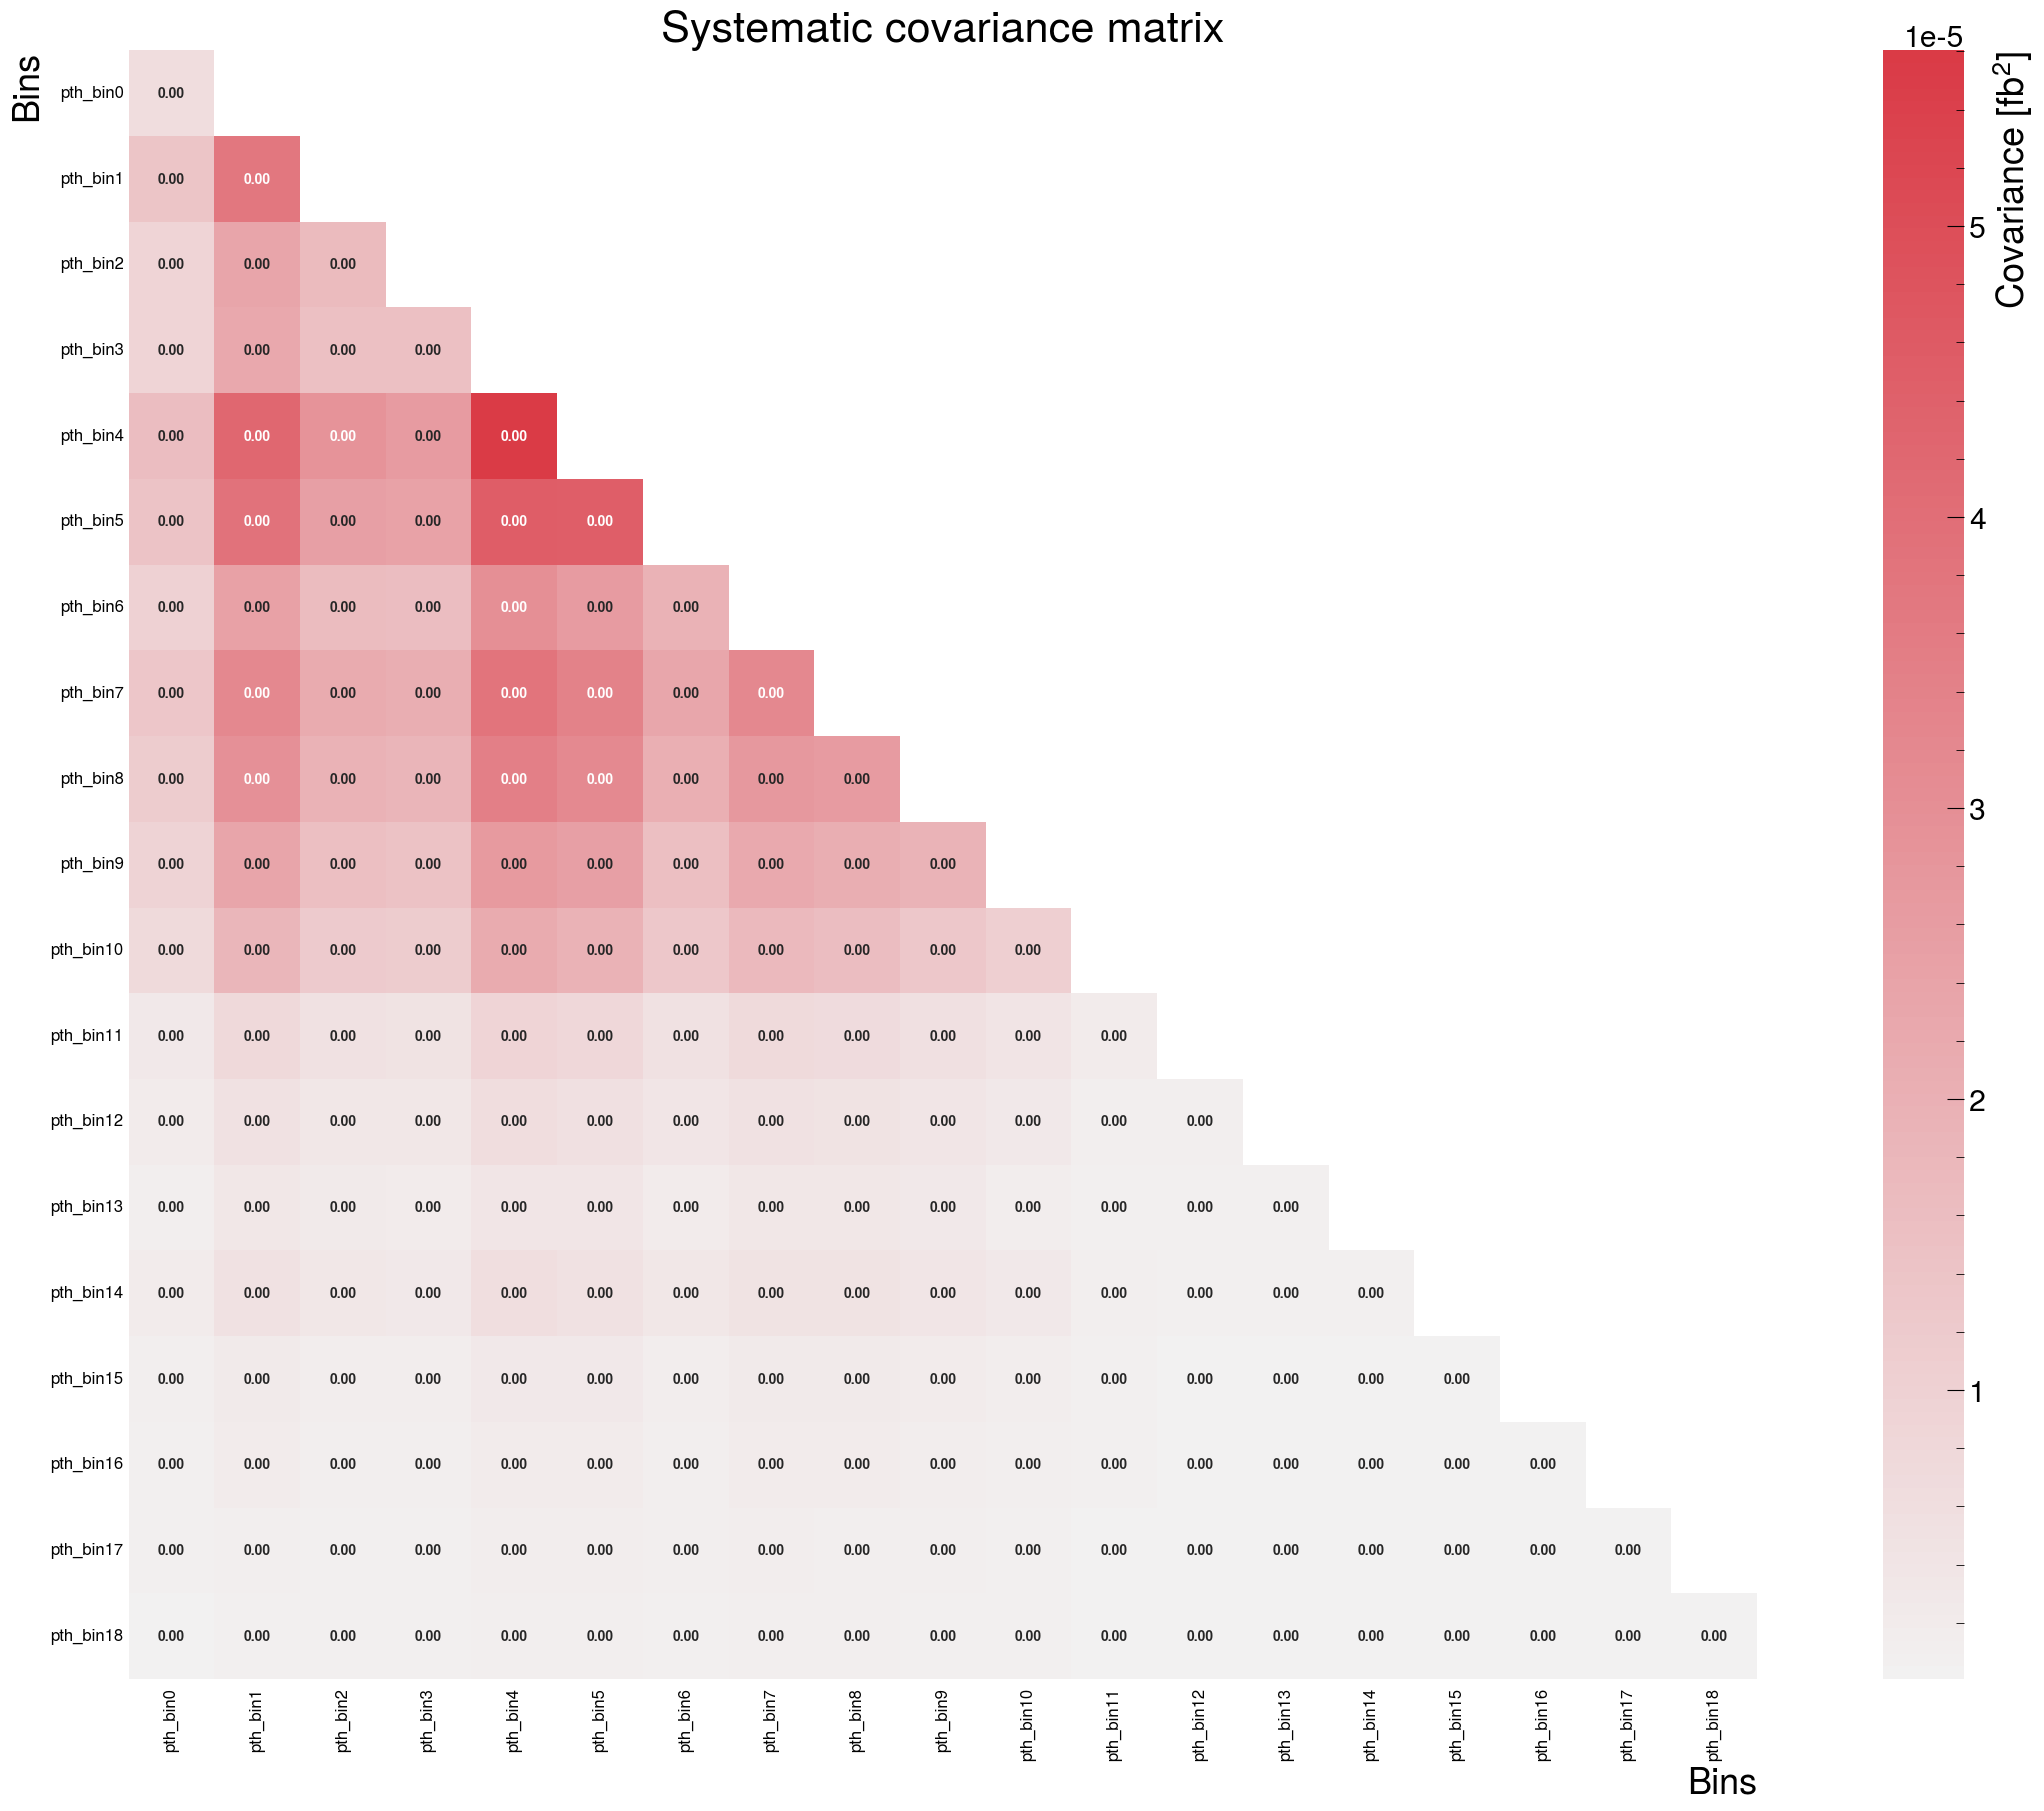

In [1300]:
plot_cov(cov_syst, title="Systematic covariance matrix", save_path="covariance_matrix_systematic_reduced.pdf")

#### Theory covariance matrix

In [1301]:
# first, load the variances for alpha s and PDF as discussed with AT

FILE_RE = re.compile(
    # r"^fidXS_(?P<obs>PTH|NJ|PTJ0|DPhiJ0J1)_all\.py$"
    r"^fidXS_(?P<obs>PTH)_all\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

var = {
    "alpha": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": []
    },
    "pdf": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": []
    }
}

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    fid_xs_nom = np.array(list(module.fidXS))  # convert once to numpy
    fid_xs_pdf_up = np.array(list(module.fidXS_pdf_up))
    fid_xs_alpha_up = np.array(list(module.fidXS_alpha_up))

    fid_xs_pdf_dn = np.array(list(module.fidXS_pdf_dn))
    fid_xs_alpha_dn = np.array(list(module.fidXS_alpha_dn))
  
    for i, nom_xs in enumerate(fid_xs_nom):
        if ((obs == "PTJ0") or (obs == "DPhiJ0J1")) and (i == 0):
            # Get rid of the underflow bins
            continue
        var["alpha"][obs].append(fid_xs_alpha_up[i] - fid_xs_nom[i])
        var["pdf"][obs].append(fid_xs_pdf_up[i] - fid_xs_nom[i])

In [1302]:
# We fully correlate the Alpha S and PDF uncertainties

# Build the correlation matrix
n_bins = len(var["alpha"]["PTH"])# + len(var["alpha"]["NJ"])# + len(var["alpha"]["PTJ0"])# + len(var["alpha"]["DPhiJ0J1"])
matrix = np.ones((n_bins, n_bins), dtype=int)

# Use the dictionary values (or keys) as labels
labels = list(label_map.values())

# Drop underflow bins
# labels.remove("r_PTJ0_m10000p0_30p0")
# labels.remove("r_DPhiJ0J1_m3p1416_3p1416_underflow")

correlation = pd.DataFrame(
    matrix,
    index=labels,
    columns=labels
)

In [1303]:
# Build the global ordered list of bins
all_bins = []
for obs in pois:
    all_bins.extend(pois[obs])

# all_bins.remove("r_PTJ0_m10000p0_30p0")
# all_bins.remove("r_DPhiJ0J1_m3p1416_3p1416_underflow")

# Replace the nested dicts with column-vector DataFrames
for source in var:

    values = []

    for obs in pois:
        values.extend(var[source][obs])

    var[source] = pd.DataFrame(
        values,
        index=all_bins,
        columns=[source]
    )

In [1304]:
# Now compute the covariance per source

v_pdf = var["pdf"].iloc[:, 0]
Cov_pdf = correlation.mul(v_pdf, axis=0).mul(v_pdf, axis=1)

v_alpha = var["alpha"].iloc[:, 0]
Cov_alpha = correlation.mul(v_alpha, axis=0).mul(v_alpha, axis=1)

In [1305]:
FILE_RE = re.compile(
    # r"^fidXS_(?P<obs>PTH|NJ|PTJ0|DPhiJ0J1)_all_scale(?P<scale>0|1|3|5|7|8)\.py$"
    r"^fidXS_(?P<obs>PTH)_all_scale(?P<scale>0|1|3|5|7|8)\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

scale_variations = {
    "0": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    },
    "1": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    },
    "3": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    },
    "5": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    },
    "7": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    },
    "8": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "DPhiJ0J1": [],
    }
}

scale_sigmas = scale_variations

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")
    scale = match.group("scale")


    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))

    if ((obs == "PTJ0") or (obs == "DPhiJ0J1")):
        sigma = sigma[1:]
        up = up[1:]
    
    scale_variations[scale][obs] = up - sigma
    scale_sigmas[scale][obs] = up
    

In [1306]:
# Now compute the scale means

scale_means = {
    "PTH": [],
    # "NJ": [],
    # "PTJ0": [],
    # "DPhiJ0J1": [],
}

for obs in scale_means.keys():
    current_obs_list = []
    for i, scale in enumerate(scale_variations.keys()):
        current_obs_list.append(scale_sigmas[scale][obs])
    arrays = [np.array(x) for x in current_obs_list]
    scale_means[obs] =  [np.mean(k) for k in zip(*arrays)]

In [1307]:
# observables = ["PTH", "NJ", "PTJ0", "DPhiJ0J1"]
observables = ["PTH"]
bin_info = {
    "PTH": 19,
    # "NJ": 5,
    # "PTJ0": 9,
    # "DPhiJ0J1": 5,
}

# Now compute the scale uncertainties from the fidXS output

FILE_RE = re.compile(
    # r"^fidXS_(?P<obs>PTH|NJ|PTJ0|DPhiJ0J1)_all\.py$"
    r"^fidXS_(?P<obs>PTH)_all\.py$"
)

# -----------------------------
# Build DataFrame (your setup)
# -----------------------------
cols = []
for obs in observables:
    for b in range(bin_info[obs]):
        if (b == 0) and ((obs == 'PTJ0') or (obs == 'DPhiJ0J1')):
            continue
        cols.append(f"{obs}_bin{b}")

data = []

for i in scale_sigmas:
    row = []
    for obs in observables:
        for b in range(bin_info[obs]):
            if (b == 0) and ((obs == 'PTJ0') or (obs == 'DPhiJ0J1')):
                continue
            b -= 1
            row.append(scale_sigmas[i][obs][b] - scale_means[obs][b])
    data.append(row)

df = pd.DataFrame(data, columns=cols)

# -----------------------------
# Cosine similarity matrix (UNCHANGED, uncentered)
# -----------------------------
bins = df.columns
n_bins = len(bins)

corr = pd.DataFrame(
    np.zeros((n_bins, n_bins)),
    index=bins,
    columns=bins
)

for a in bins:
    xa = df[a].to_numpy()

    denom_a = np.sum(xa ** 2)

    for b in bins:
        xb = df[b].to_numpy()

        denom_b = np.sum(xb ** 2)
        num = np.sum(xa * xb)

        corr.loc[a, b] = num / np.sqrt(denom_a * denom_b)


def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

scale_uncertainties = {
    "PTH": [],
    "NJ": [],
    # "PTJ0": [],
    # "DPhiJ0J1": [],
}

fidXS_folder = Path("fidXS")

for path in fidXS_folder.iterdir():
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")
    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))

    if ((obs == "PTJ0") or (obs == "DPhiJ0J1")):
        sigma = sigma[1:]
        up = up[1:]
    
    scale_uncertainties[obs] = up - sigma

unc = []

for obs in observables:
    unc.extend(scale_uncertainties[obs])  # your dict

sigma_THU = np.array(unc)


Cov_scale = corr * np.outer(sigma_THU, sigma_THU)

Cov_scale = pd.DataFrame(
    Cov_scale
)

Cov_scale = Cov_scale.rename(index=label_map_theory, columns=label_map_theory)

In [1308]:
Cov_Theor = Cov_pdf + Cov_alpha + Cov_scale

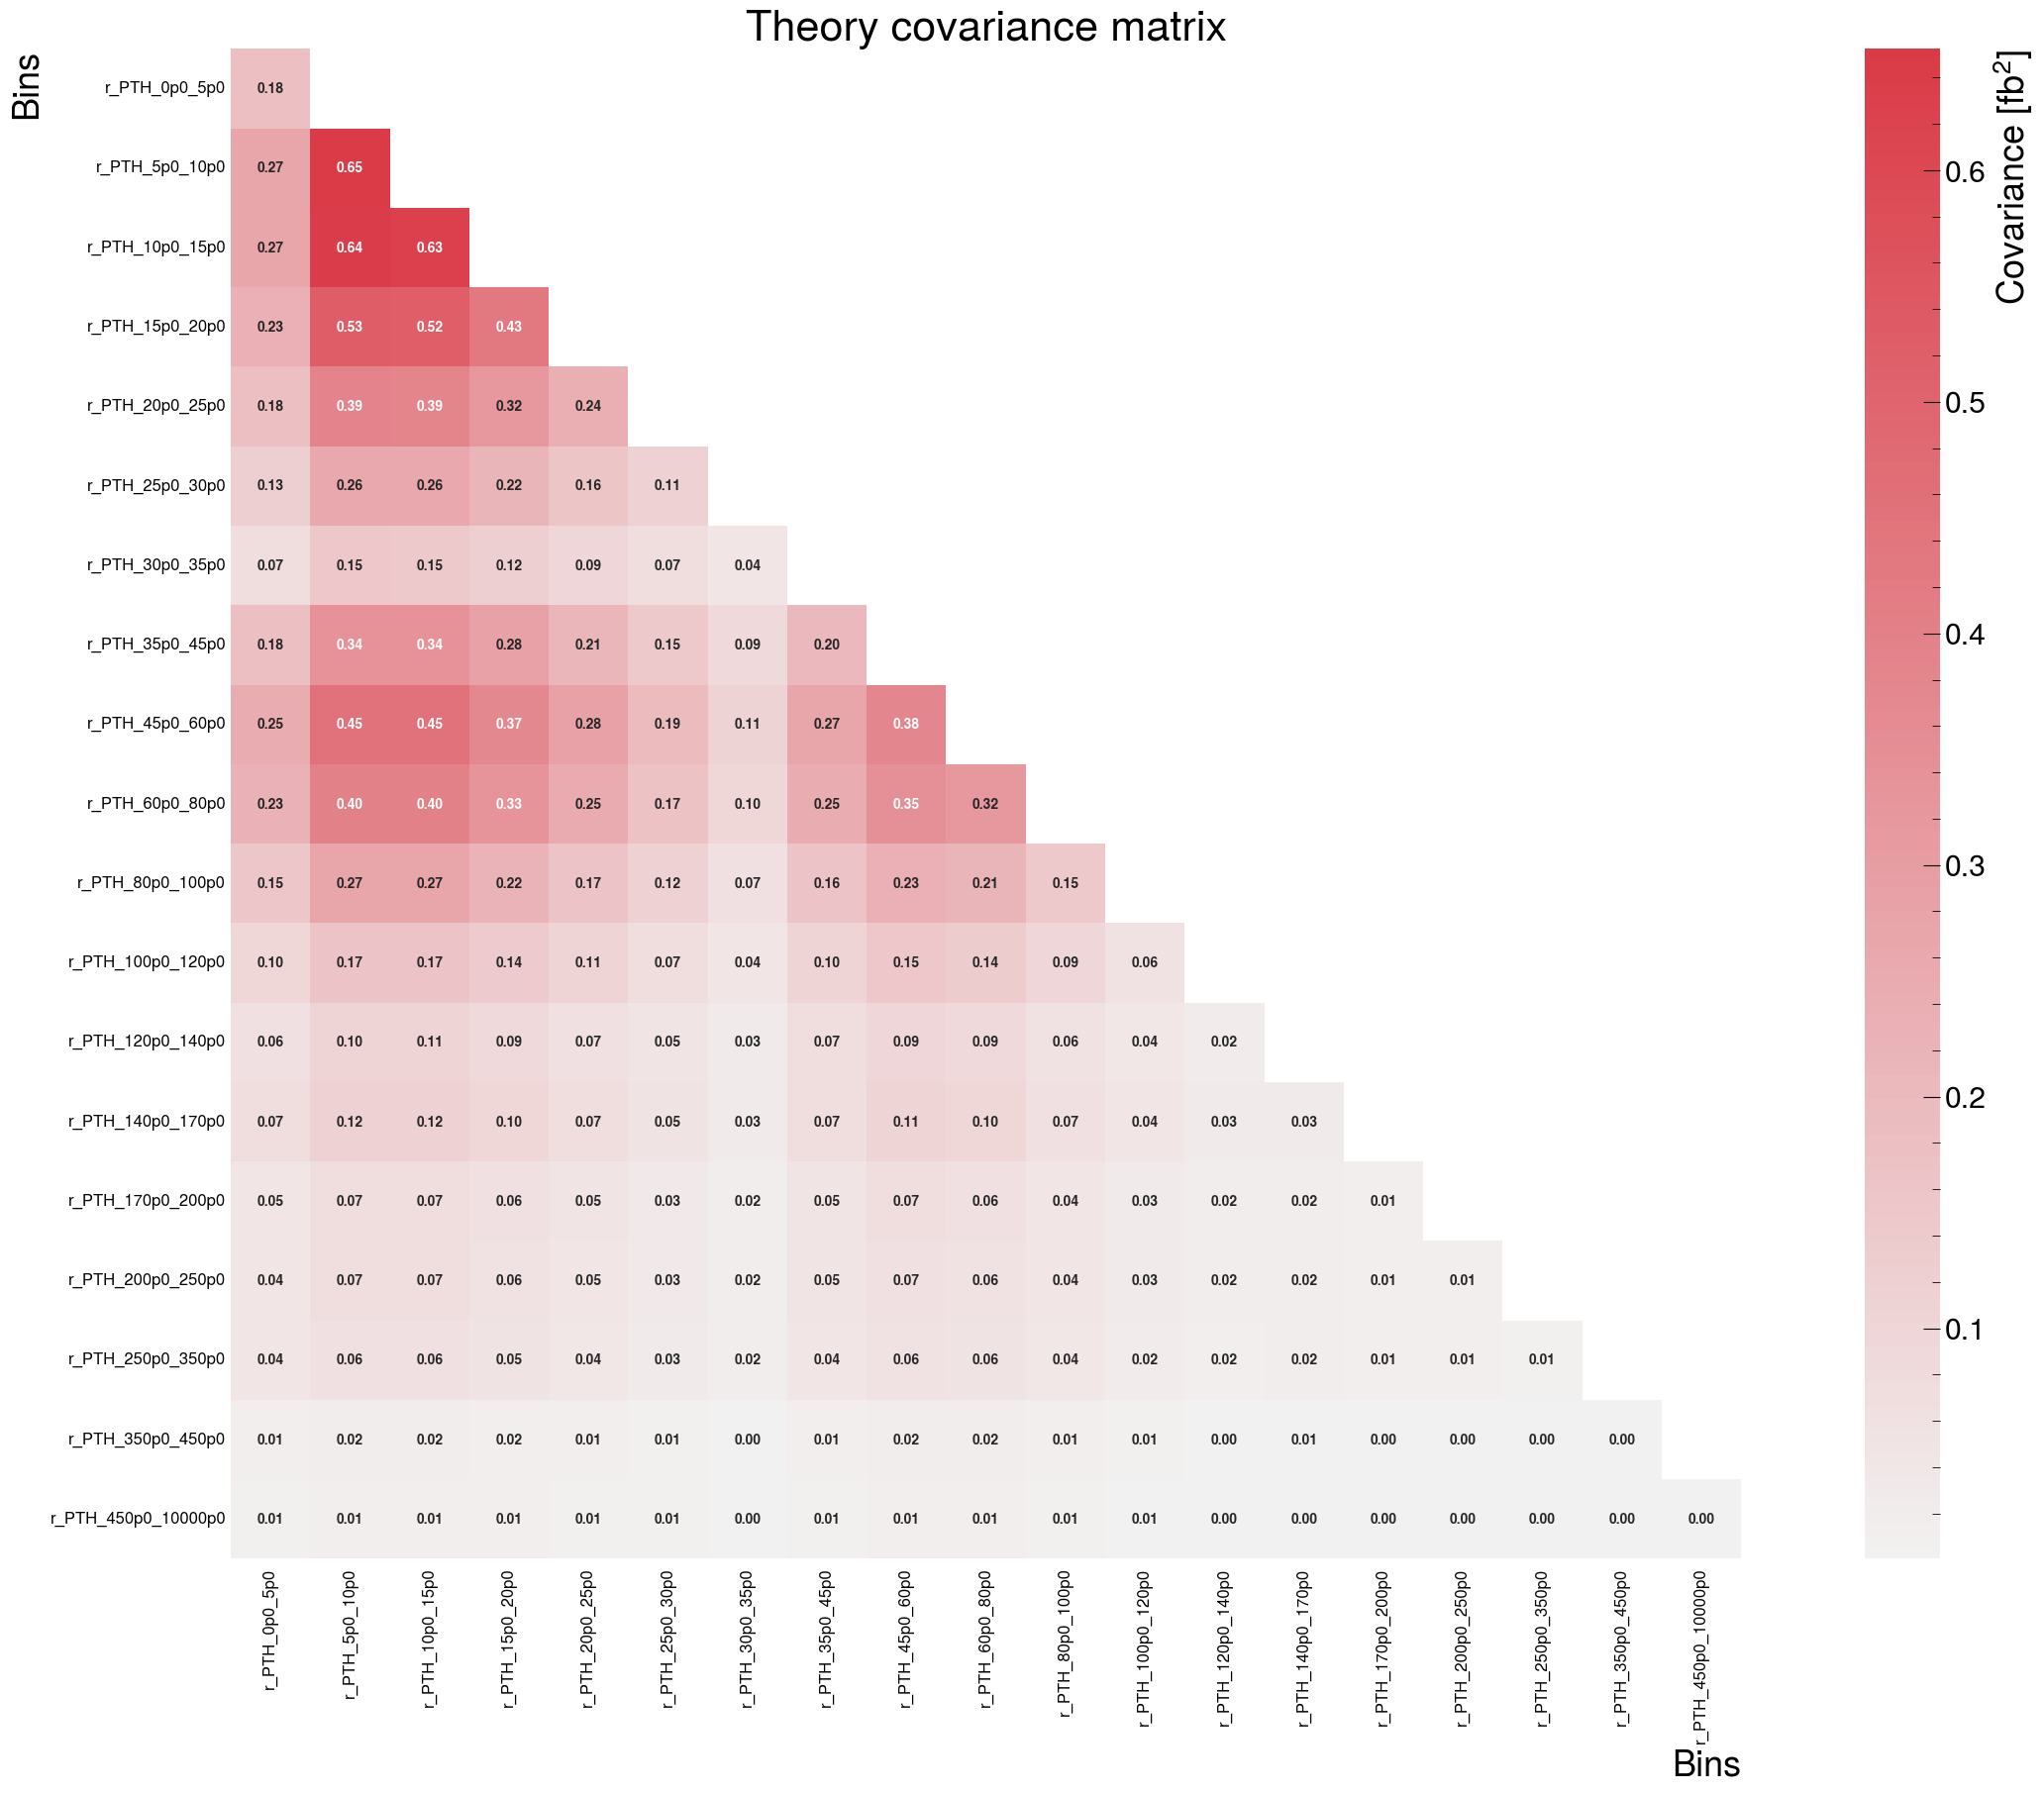

In [1309]:
plot_cov(Cov_Theor, title="Theory covariance matrix", save_path="covariance_matrix_theory_reduced.pdf")

In [1310]:
cov_syst = cov_syst.rename(index=label_map, columns=label_map)
cov_stat = cov_stat.rename(index=label_map, columns=label_map)


# Drop underflow bins
label_maps_noUnderflow = list(label_map.values())
# label_maps_noUnderflow.remove("r_PTJ0_m10000p0_30p0")
# label_maps_noUnderflow.remove("r_DPhiJ0J1_m3p1416_3p1416_underflow")


cov_syst = cov_syst.loc[label_maps_noUnderflow, label_maps_noUnderflow]
cov_stat = cov_stat.loc[label_maps_noUnderflow, label_maps_noUnderflow]

In [1311]:
cov_tot = cov_stat + cov_syst + Cov_Theor
corr_tot = corr_from_cov(cov_tot)

In [1312]:
cov_tot = cov_tot.rename(index=label_map, columns=label_map)

In [1313]:
corr_tot = corr_tot.loc[label_maps_noUnderflow, label_maps_noUnderflow]
cov_tot = cov_tot.loc[label_maps_noUnderflow, label_maps_noUnderflow]

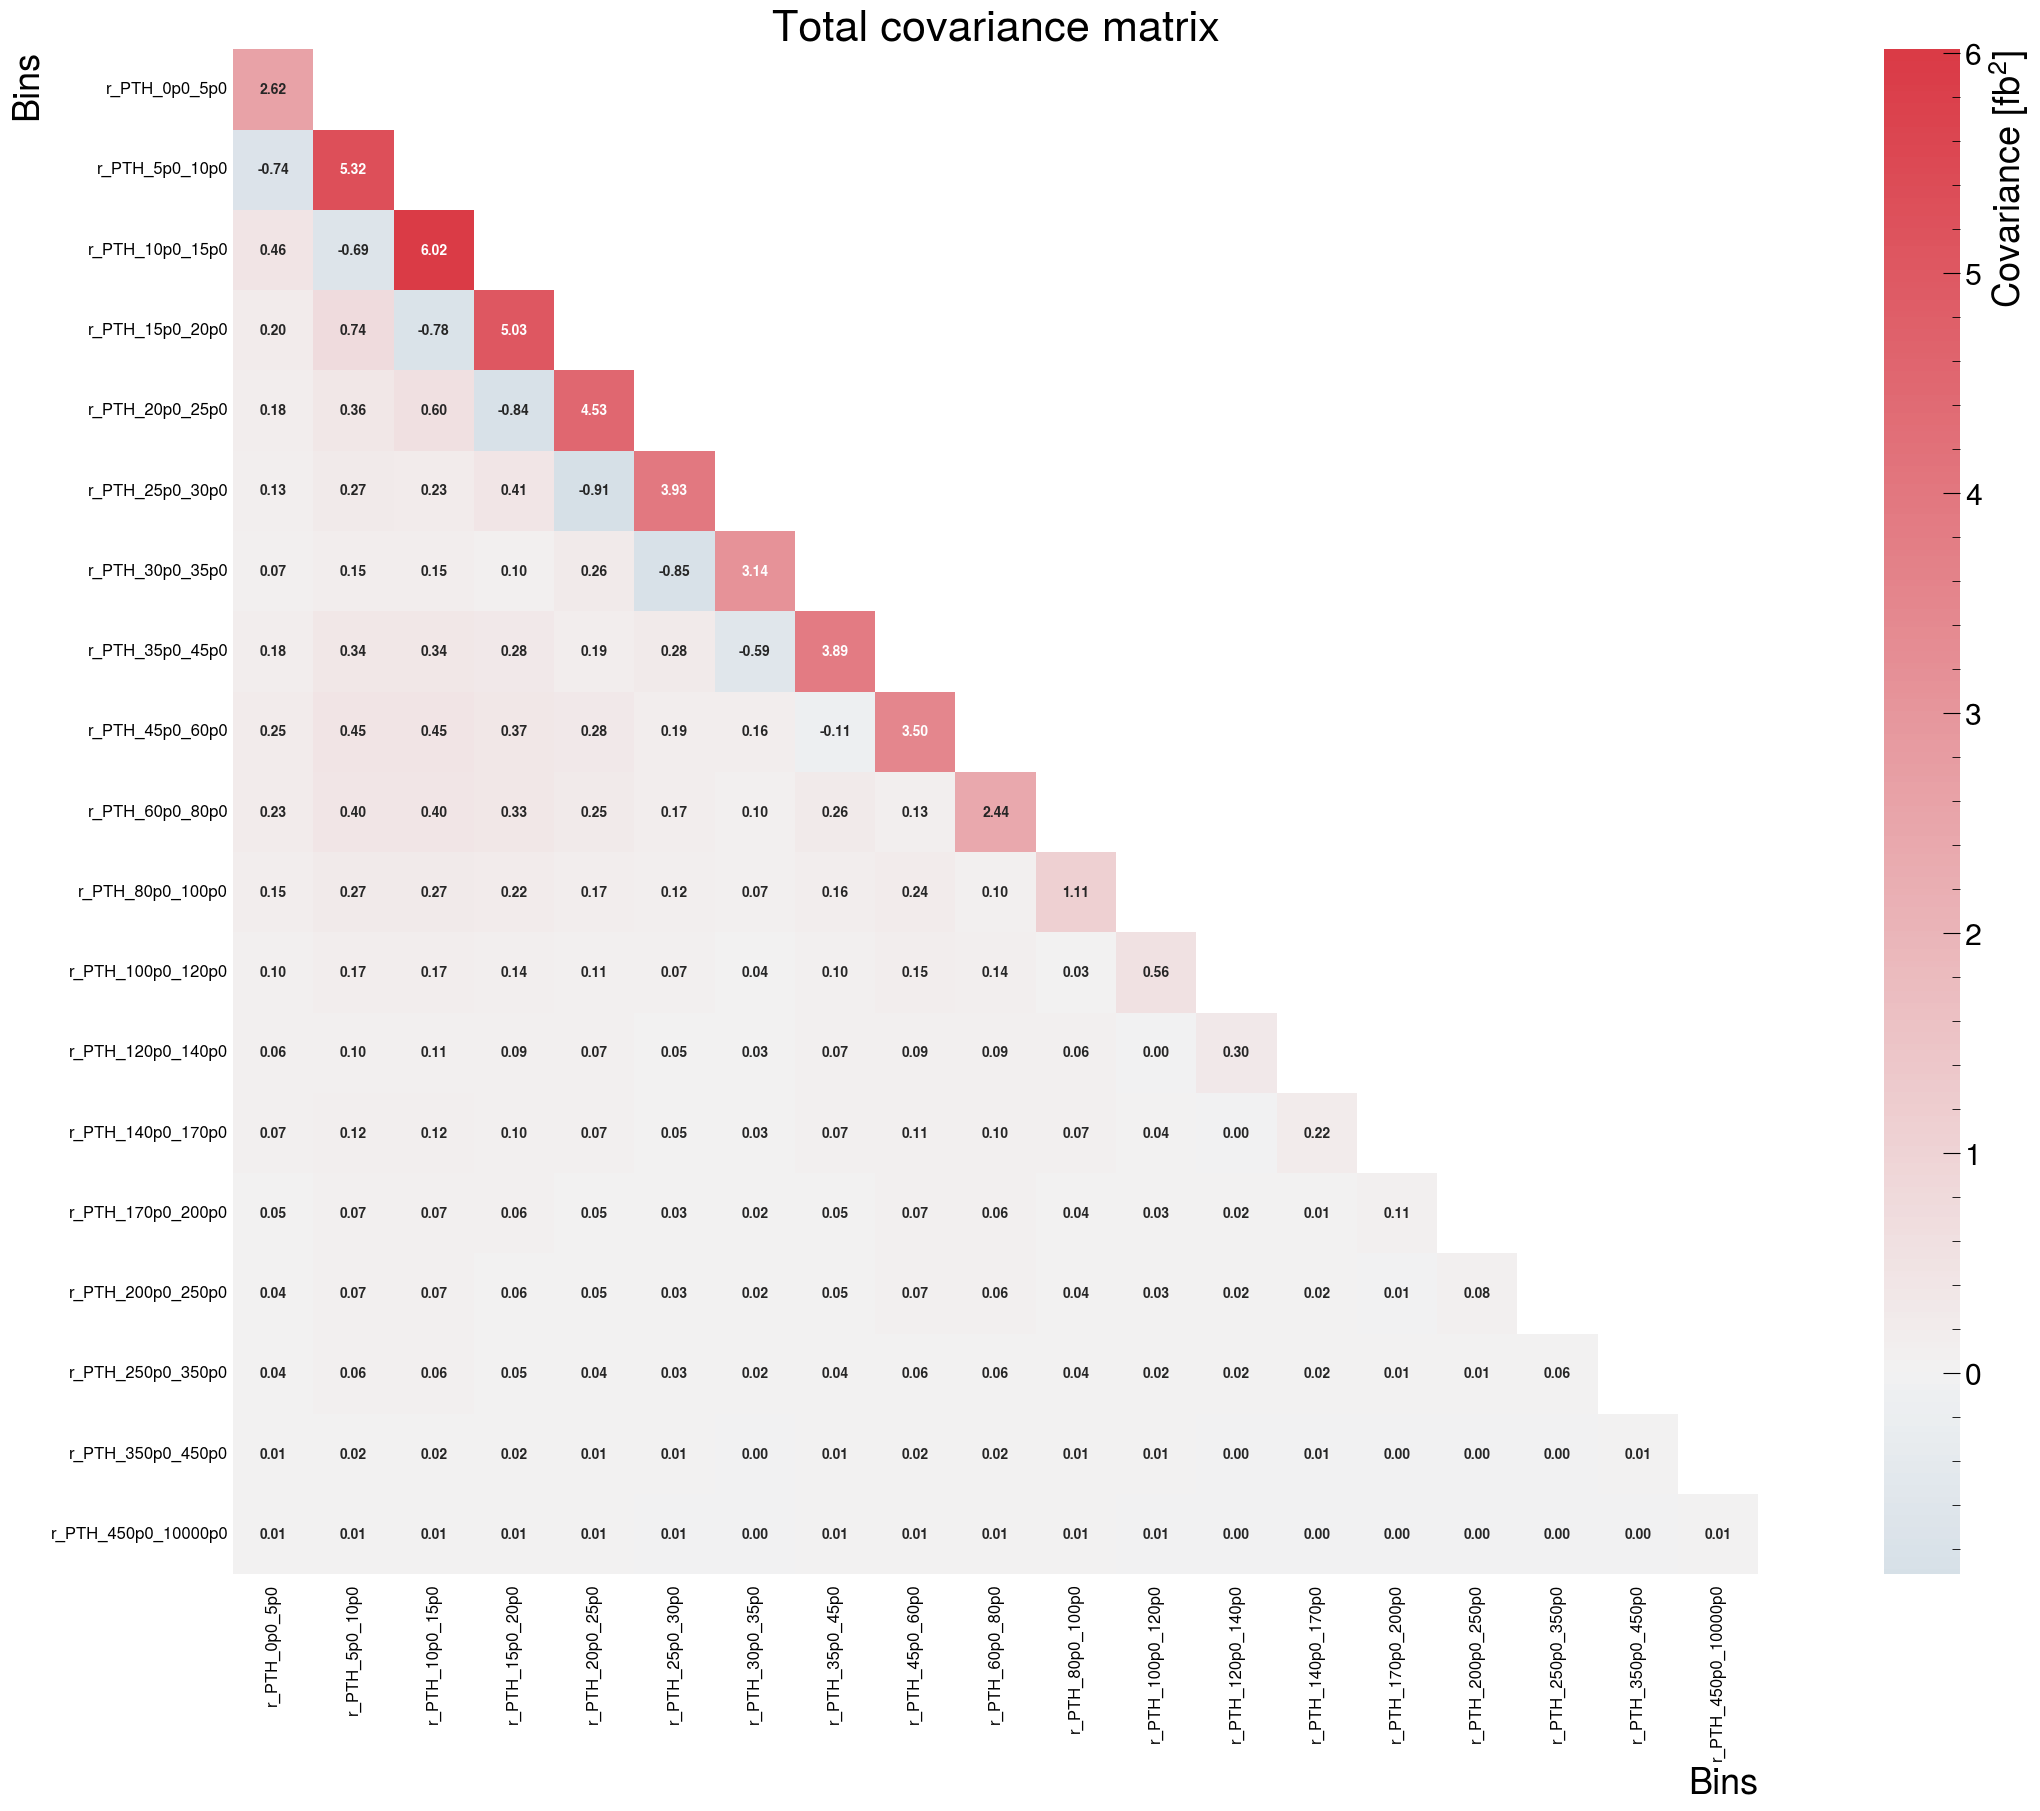

In [1314]:
plot_cov(cov_tot, title="Total covariance matrix", save_path="covariance_matrix_total_reduced.pdf")

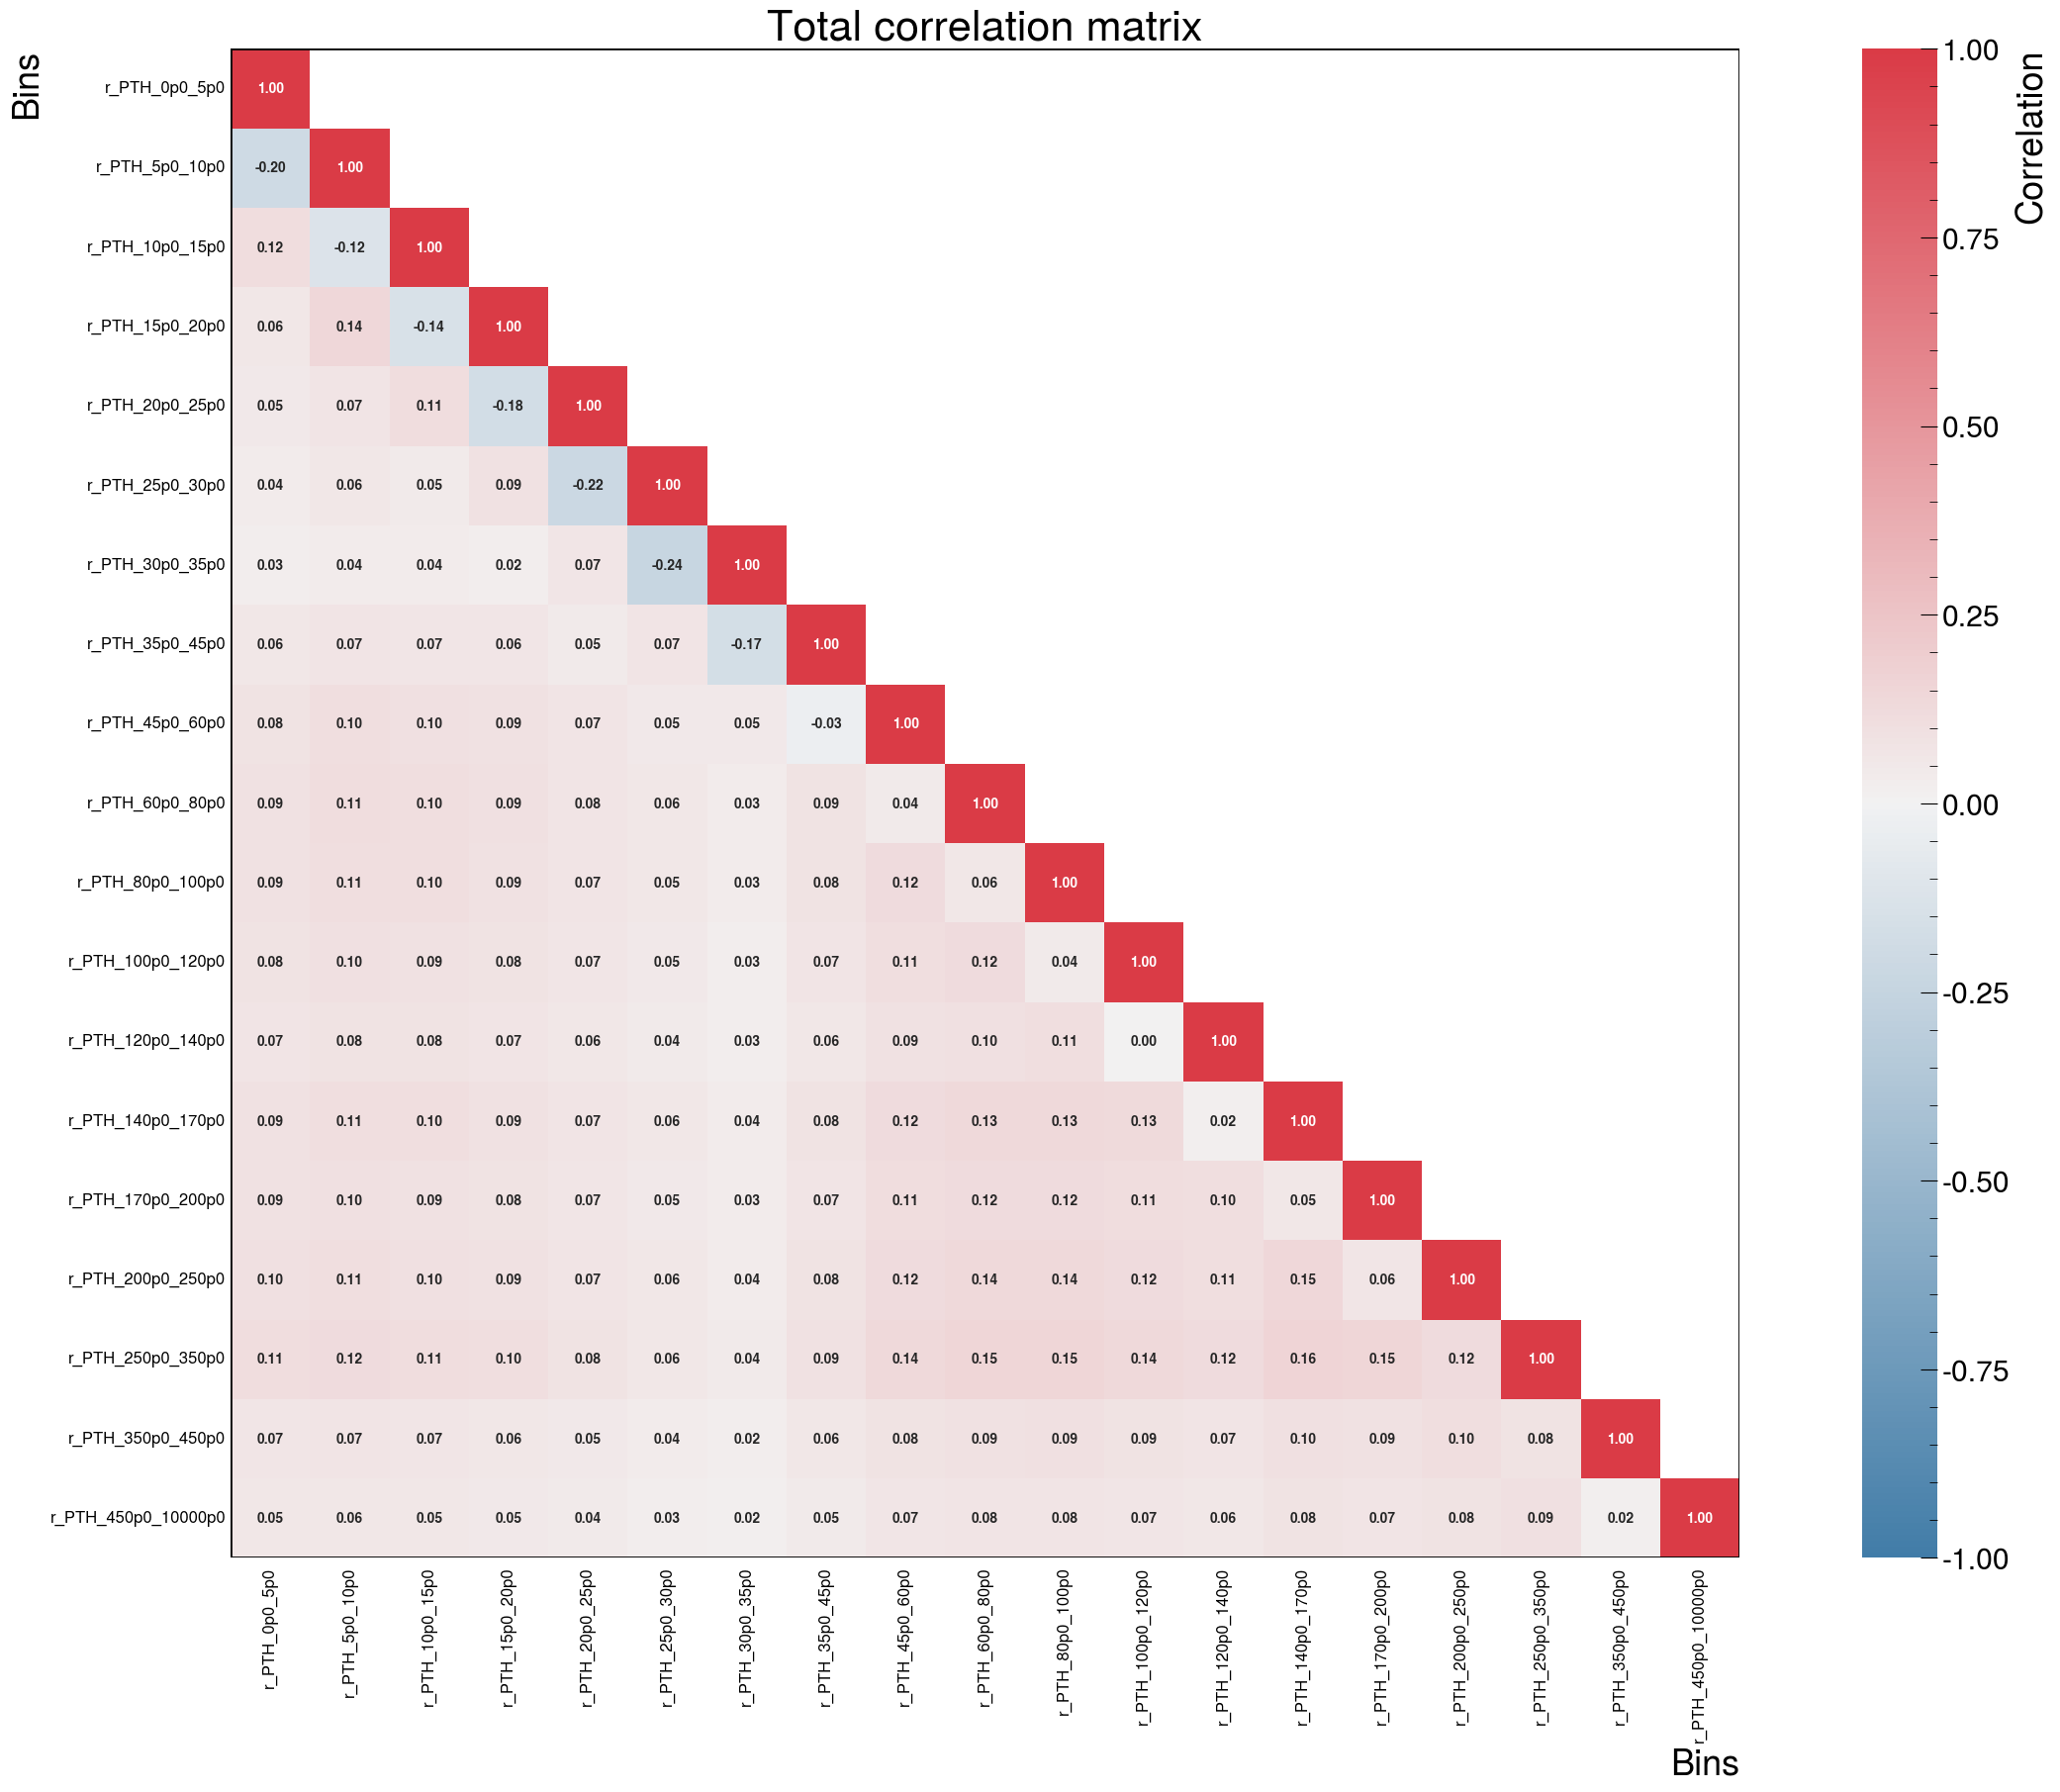

In [1315]:
plot_corr(corr_tot, title="Total correlation matrix", save_path="correlation_matrix_total_reduced.pdf")

#### Saving information in Nico-friendly format

In [1316]:
## Save matrices in a Nico-friendly format
import yaml

def dataframe_to_yaml_rows(
    df,
    output_yaml,
    label_map,
    target_order=None,
    zero_tol=0.0,
):
    """
    Convert square DataFrame -> YAML list-of-row-dicts format.

    - df: pandas DataFrame (square)
    - output_yaml: output path
    - label_map: dict old_label -> new_label
    - target_order: list of NEW labels in desired final order.
                    If None, uses DataFrame order after renaming.
    - zero_tol: values with abs(x) < zero_tol are written as 0.0
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")
    if df.shape[0] != df.shape[1]:
        raise ValueError("df must be square")

    # Rename both axes
    m = df.rename(index=label_map, columns=label_map).copy()

    # If desired order not provided, keep current renamed order
    if target_order is None:
        target_order = list(m.index)

    # Validate target labels exist
    missing_rows = [x for x in target_order if x not in m.index]
    missing_cols = [x for x in target_order if x not in m.columns]
    if missing_rows or missing_cols:
        raise KeyError(
            f"Missing labels after renaming.\n"
            f"Rows missing: {missing_rows}\n"
            f"Cols missing: {missing_cols}"
        )

    # Reorder matrix
    m = m.loc[target_order, target_order].astype(float)

    # Build YAML structure: list of dicts (one row per item)
    rows = []
    for _, row in m.iterrows():
        d = {}
        for col, val in row.items():
            x = float(val)
            if abs(x) < zero_tol:
                x = 0.0
            d[col] = x
        rows.append(d)

    with open(output_yaml, "w") as f:
        yaml.safe_dump(rows, f, sort_keys=False, default_flow_style=False)

In [1317]:
target_order = pois["PTH"]# + pois["NJ"]# + pois["PTJ0"]# + pois["DPhiJ0J1"]
# target_order.remove("r_PTJ0_m10000p0_30p0")
# target_order.remove("r_DPhiJ0J1_m3p1416_3p1416_underflow")


In [1318]:
dataframe_to_yaml_rows(
    df=corr_tot, 
    output_yaml="PTH.yaml",
    label_map=label_map, 
    target_order=target_order,
    zero_tol=1e-12, ## zero_tol is the threshold below which numbers are forced to 0.0 when exporting
)

In [1319]:
# For PCA

dataframe_to_yaml_rows(
    df=cov_tot, 
    output_yaml="cov_tot_PTH.yaml",
    label_map=label_map,
    target_order=target_order,
    zero_tol=1e-12, ## zero_tol is the threshold below which numbers are forced to 0.0 when exporting
)